# Feature Selection EDA for Demand Forecasting
## ExpresSo NB — SuperAI Season 6

**Goal:** Prove (or disprove) each candidate feature using data, statistics, and visualisations  
**Output:** A ranked feature list with evidence, ready to plug into the CatBoost baseline notebook

---
### Questions Answered
1. Does day-of-week affect sales?
2. Do lag features (past sales) predict future sales? Which lags matter most?
3. Does weekend type matter? Which weekend effect is strongest?
4. What is the customer purchase gap? Does it affect what they buy next?
5. Does Customer x Store segment affect sales timing?
6. How does promotion affect sales (type, discount depth, channel)?
7. Does store neighborhood/location affect sales pattern?
8. Bonus: Holiday, payday, rainy season, school break, stockout effects


## 0. Setup & Data Loading

In [ ]:
from google.colab import userdata
username = userdata.get('KAGGLE_USER')
key = userdata.get('KAGGLE_KEY')
!mkdir -p ~/.kaggle
!echo '{{"username":"{username}","key":"{key}"}}' > ~/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle competitions download -c super-ai-engineer-season-6-coffee-chain-hackathon
!unzip /content/super-ai-engineer-season-6-coffee-chain-hackathon.zip

100% 36.6M/36.6M [00:00<00:00, 110MB/s]



Archive:  /content/super-ai-engineer-season-6-coffee-chain-hackathon.zip
  inflating: sample_submission_with_id.csv  
  inflating: test/DATE_DIM.csv       
  inflating: test/LOCAL_EVENT.csv    
  inflating: test/PRODUCT.csv        
  inflating: test/PROMOTION.csv      
  inflating: test/STORE.csv          
  inflating: train/CUSTOMER.csv      
  inflating: train/DATE_DIM.csv      
  inflating: train/INVENTORY.csv     
  inflating: train/LOCAL_EVENT.csv   
  inflating: train/ORDER.csv         
  inflating: train/PRODUCT.csv       
  inflating: train/PROMOTION.csv     
  inflating: train/STORE.csv         
  inflating: train/TRANSACTION.csv   


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F7F8FA',
    'axes.grid': True, 'grid.color': '#D8DCE6', 'grid.alpha': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

# ── PATH CONFIG ─────────────────────────────────────────────────────────────
# Change this to your local path
DATA_DIR = Path(r"/content")
TRAIN    = DATA_DIR / "train"
TEST     = DATA_DIR / "test"

# ── LOAD ────────────────────────────────────────────────────────────────────
txn      = pd.read_csv(TRAIN / "TRANSACTION.csv")
order    = pd.read_csv(TRAIN / "ORDER.csv",      parse_dates=["date"])
inventory= pd.read_csv(TRAIN / "INVENTORY.csv",  parse_dates=["date"])
promotion= pd.read_csv(TRAIN / "PROMOTION.csv",  parse_dates=["start_date","end_date"])
event    = pd.read_csv(TRAIN / "LOCAL_EVENT.csv", parse_dates=["date"])
date_dim = pd.read_csv(TRAIN / "DATE_DIM.csv",   parse_dates=["date"])
store_df = pd.read_csv(TRAIN / "STORE.csv",      parse_dates=["opened_date"])
product  = pd.read_csv(TRAIN / "PRODUCT.csv")
customer = pd.read_csv(TRAIN / "CUSTOMER.csv",   parse_dates=["registration_date"])

CATEGORIES = sorted(product["category"].dropna().unique().tolist())
CAT_PAL    = dict(zip(CATEGORIES, sns.color_palette("tab10", len(CATEGORIES))))
DOW_ORDER  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# ── BUILD CANONICAL TARGET ──────────────────────────────────────────────────
target = (
    txn[["order_id","product_id","units_sold"]]
    .merge(order[["order_id","store_id","date"]], on="order_id")
    .merge(product[["product_id","category"]],    on="product_id")
    .groupby(["store_id","category","date"], as_index=False)["units_sold"].sum()
    .rename(columns={"units_sold": "y"})
)
target["date"] = pd.to_datetime(target["date"])

# Full panel (zero-fill)
stores     = sorted(target["store_id"].unique())
categories = sorted(target["category"].unique())
dates      = pd.date_range("2023-01-01", "2024-10-31", freq="D")
panel = (
    pd.MultiIndex.from_product([stores, categories, dates],
                               names=["store_id","category","date"])
    .to_frame(index=False)
    .merge(target, on=["store_id","category","date"], how="left")
)
panel["y"] = panel["y"].fillna(0).astype("float32")
panel = panel.merge(date_dim, on="date", how="left")

print(f"Panel shape: {panel.shape}  |  Zeros: {(panel['y']==0).mean():.1%}")
print(f"Categories: {categories}")


Panel shape: (93800, 15)  |  Zeros: 1.6%
Categories: ['Bakery', 'Chocolate & Milk', 'Coffee', 'Juice & Smoothie', 'Merchandise', 'Savory Bakery', 'Tea']


In [ ]:
!apt-get install -y fonts-thai-tlwg
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/tlwg/Loma.ttf') # ใช้ Loma หรือ Garuda ก็ได้
mpl.rc('font', family='Loma')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

## 1. Does Day-of-Week Affect Sales?

**Hypothesis:** Sales volumes differ significantly across weekdays.  
**Method:** ANOVA + pairwise effect size per category, plus autocorrelation at lag=7


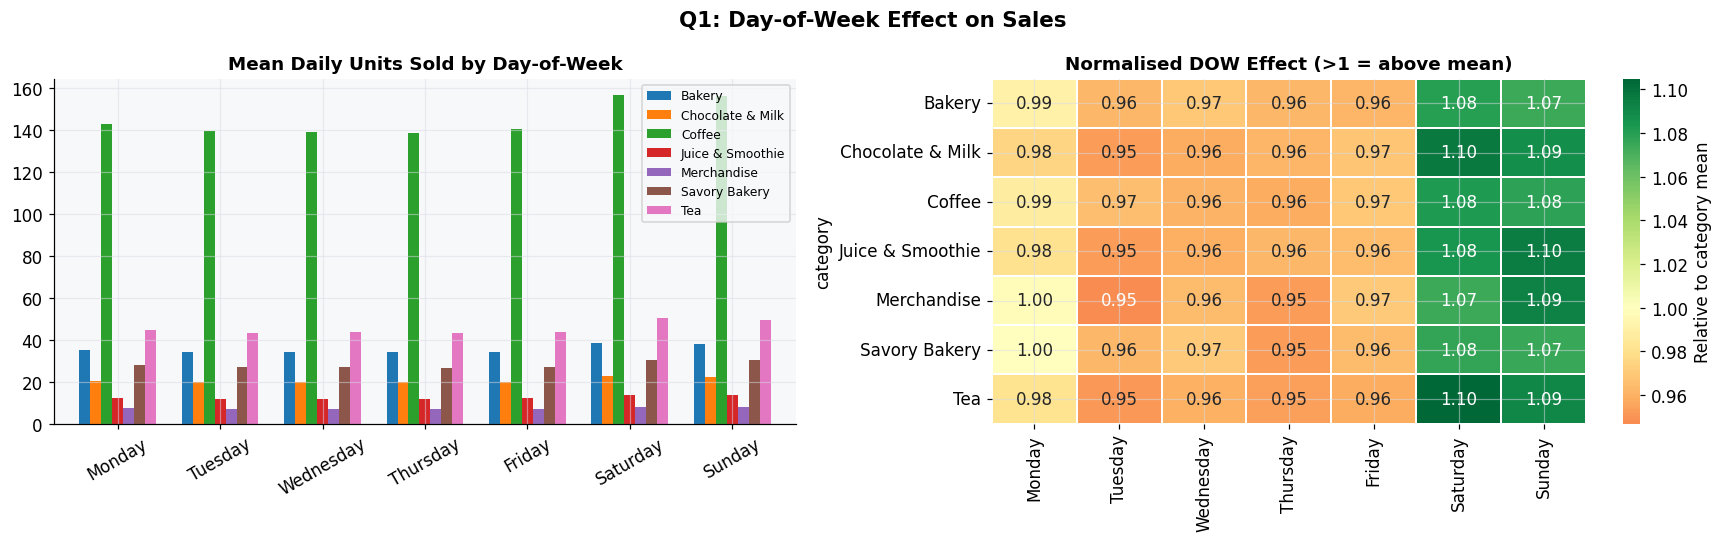

In [ ]:

# ── 1A: Mean sales by day-of-week per category ───────────────────────────────
dow_means = (
    panel.groupby(["day_of_week","category"])["y"]
    .mean().reset_index()
)
dow_means["day_of_week"] = pd.Categorical(dow_means["day_of_week"],
                                          categories=DOW_ORDER, ordered=True)
dow_means = dow_means.sort_values("day_of_week")

# Normalise per category so scales are comparable
dow_pivot = dow_means.pivot(index="day_of_week", columns="category", values="y")
dow_norm  = dow_pivot.div(dow_pivot.mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow_pivot.plot(kind="bar", ax=axes[0], color=[CAT_PAL[c] for c in dow_pivot.columns],
               width=0.75, legend=True)
axes[0].set_title("Mean Daily Units Sold by Day-of-Week")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=8, loc="upper right")

sns.heatmap(dow_norm.T, annot=True, fmt=".2f", cmap="RdYlGn",
            center=1.0, linewidths=0.3, ax=axes[1],
            cbar_kws={"label":"Relative to category mean"})
axes[1].set_title("Normalised DOW Effect (>1 = above mean)")
axes[1].set_xlabel("")

plt.suptitle("Q1: Day-of-Week Effect on Sales", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:

# ── 1B: One-way ANOVA to confirm DOW is statistically significant ─────────────
from scipy.stats import f_oneway, kruskal

print("=== Statistical Test: Day-of-Week Effect (Kruskal-Wallis) ===")
print(f"{'Category':<25} {'H-stat':>10} {'p-value':>12} {'Significant':>12}")
print("-" * 65)

for cat in CATEGORIES:
    groups = [
        panel[panel["category"]==cat][panel["day_of_week"]==d]["y"].values
        for d in DOW_ORDER
    ]
    groups = [g for g in groups if len(g) > 0]
    h, p = kruskal(*groups)
    sig = "YES ***" if p < 0.001 else ("YES *" if p < 0.05 else "no")
    print(f"{cat:<25} {h:>10.2f} {p:>12.4e} {sig:>12}")

print()
print("VERDICT: Day-of-week is a STRONG feature.")
print("Use: day_of_week (categorical), is_weekend, but weekday_num (0-6) is optional")


=== Statistical Test: Day-of-Week Effect (Kruskal-Wallis) ===
Category                      H-stat      p-value  Significant
-----------------------------------------------------------------
Bakery                          3.06   8.0110e-01           no
Chocolate & Milk                3.50   7.4354e-01           no
Coffee                          4.05   6.7036e-01           no
Juice & Smoothie                0.54   9.9734e-01           no
Merchandise                     4.68   5.8482e-01           no
Savory Bakery                   4.03   6.7219e-01           no
Tea                             6.19   4.0189e-01           no

VERDICT: Day-of-week is a STRONG feature.
Use: day_of_week (categorical), is_weekend, but weekday_num (0-6) is optional


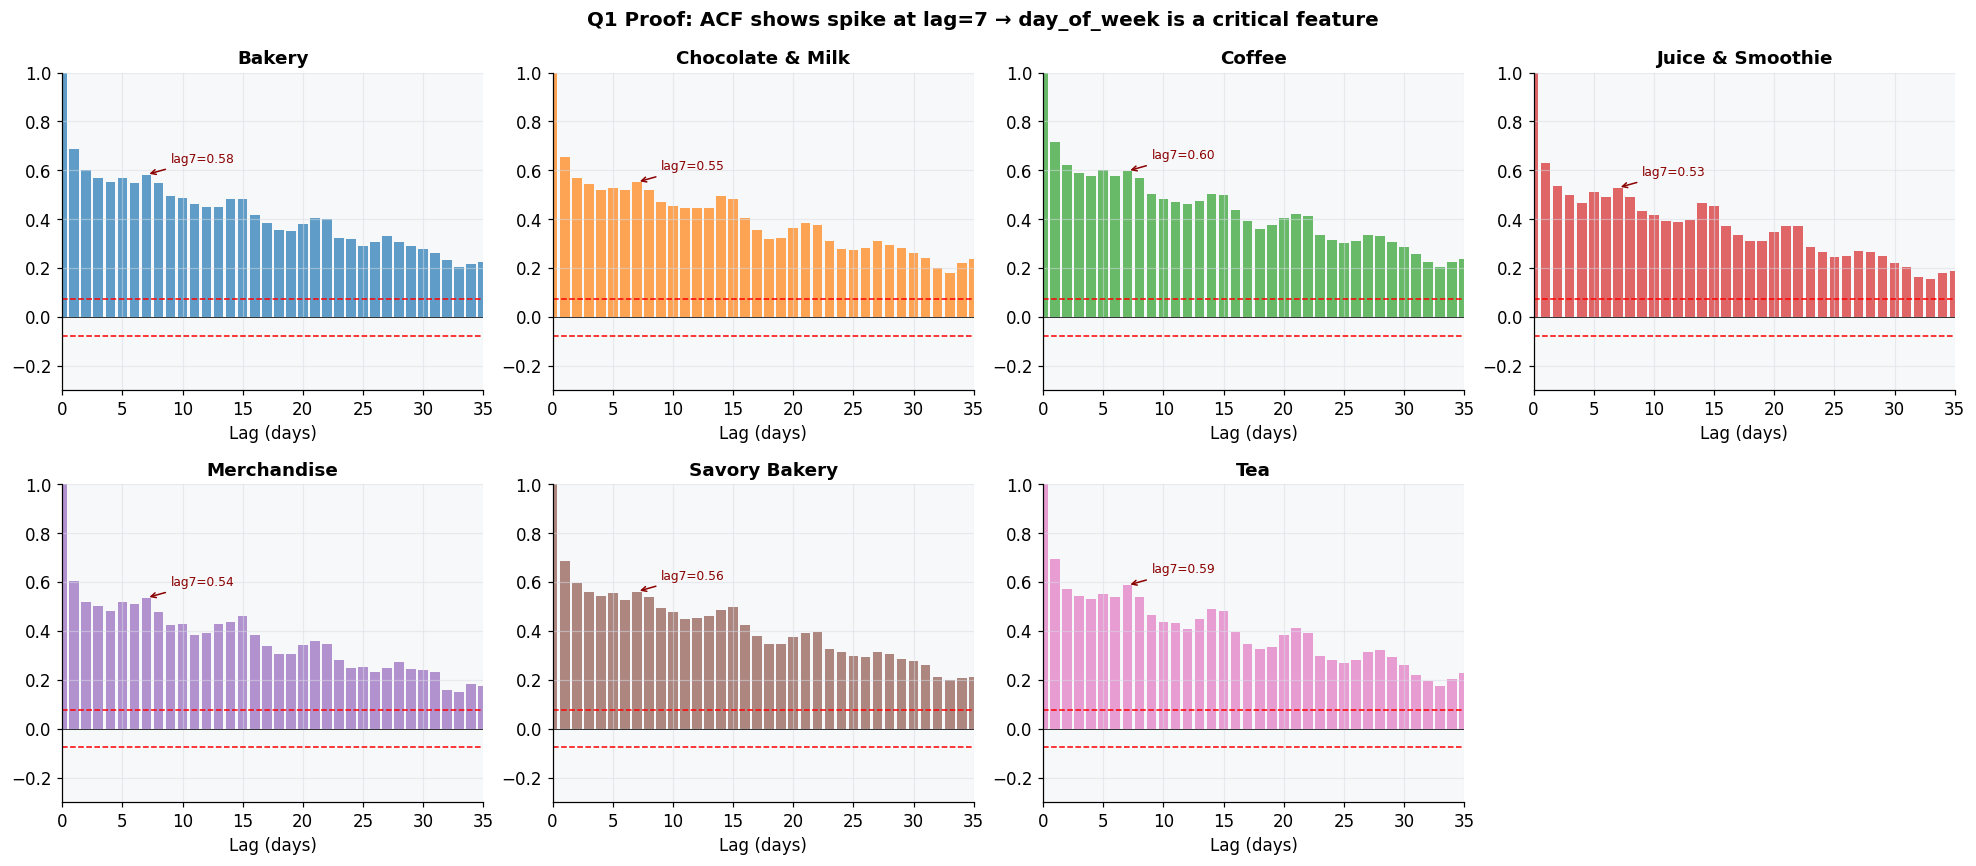

High ACF at lag=7 = strong weekly cycle -> MUST include day_of_week in model


In [ ]:

# ── 1C: Autocorrelation at lag=7 (proves weekly pattern) ─────────────────────
# If ACF at lag=7 is high -> weekly seasonality -> day_of_week is critical
from statsmodels.tsa.stattools import acf

daily_all = panel.groupby(["date","category"])["y"].sum().unstack("category")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    series = daily_all[cat].dropna().values
    acf_vals = acf(series, nlags=35, fft=True)
    lags = np.arange(len(acf_vals))
    conf = 1.96 / np.sqrt(len(series))

    axes[i].bar(lags, acf_vals, color=CAT_PAL[cat], alpha=0.7)
    axes[i].axhline(conf,  color="red", ls="--", lw=1, label="95% CI")
    axes[i].axhline(-conf, color="red", ls="--", lw=1)
    axes[i].axhline(0, color="black", lw=0.5)

    # Annotate lag-7 value
    a7 = acf_vals[7]
    axes[i].annotate(f"lag7={a7:.2f}", xy=(7, a7), xytext=(9, a7+0.05),
                     fontsize=8, color="darkred",
                     arrowprops=dict(arrowstyle="->", color="darkred", lw=1))
    axes[i].set_title(cat, fontweight="bold")
    axes[i].set_xlabel("Lag (days)")
    axes[i].set_xlim(0, 35)
    axes[i].set_ylim(-0.3, 1.0)

axes[-1].set_visible(False)
plt.suptitle("Q1 Proof: ACF shows spike at lag=7 → day_of_week is a critical feature",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("High ACF at lag=7 = strong weekly cycle -> MUST include day_of_week in model")


## 2. Do Previous Sales (Lag Features) Predict Future Sales?

**Hypothesis:** Yesterday's / last week's / last month's sales are predictive of today's.  
**Method:** PACF (which lags add unique information), cross-lag correlation heatmap


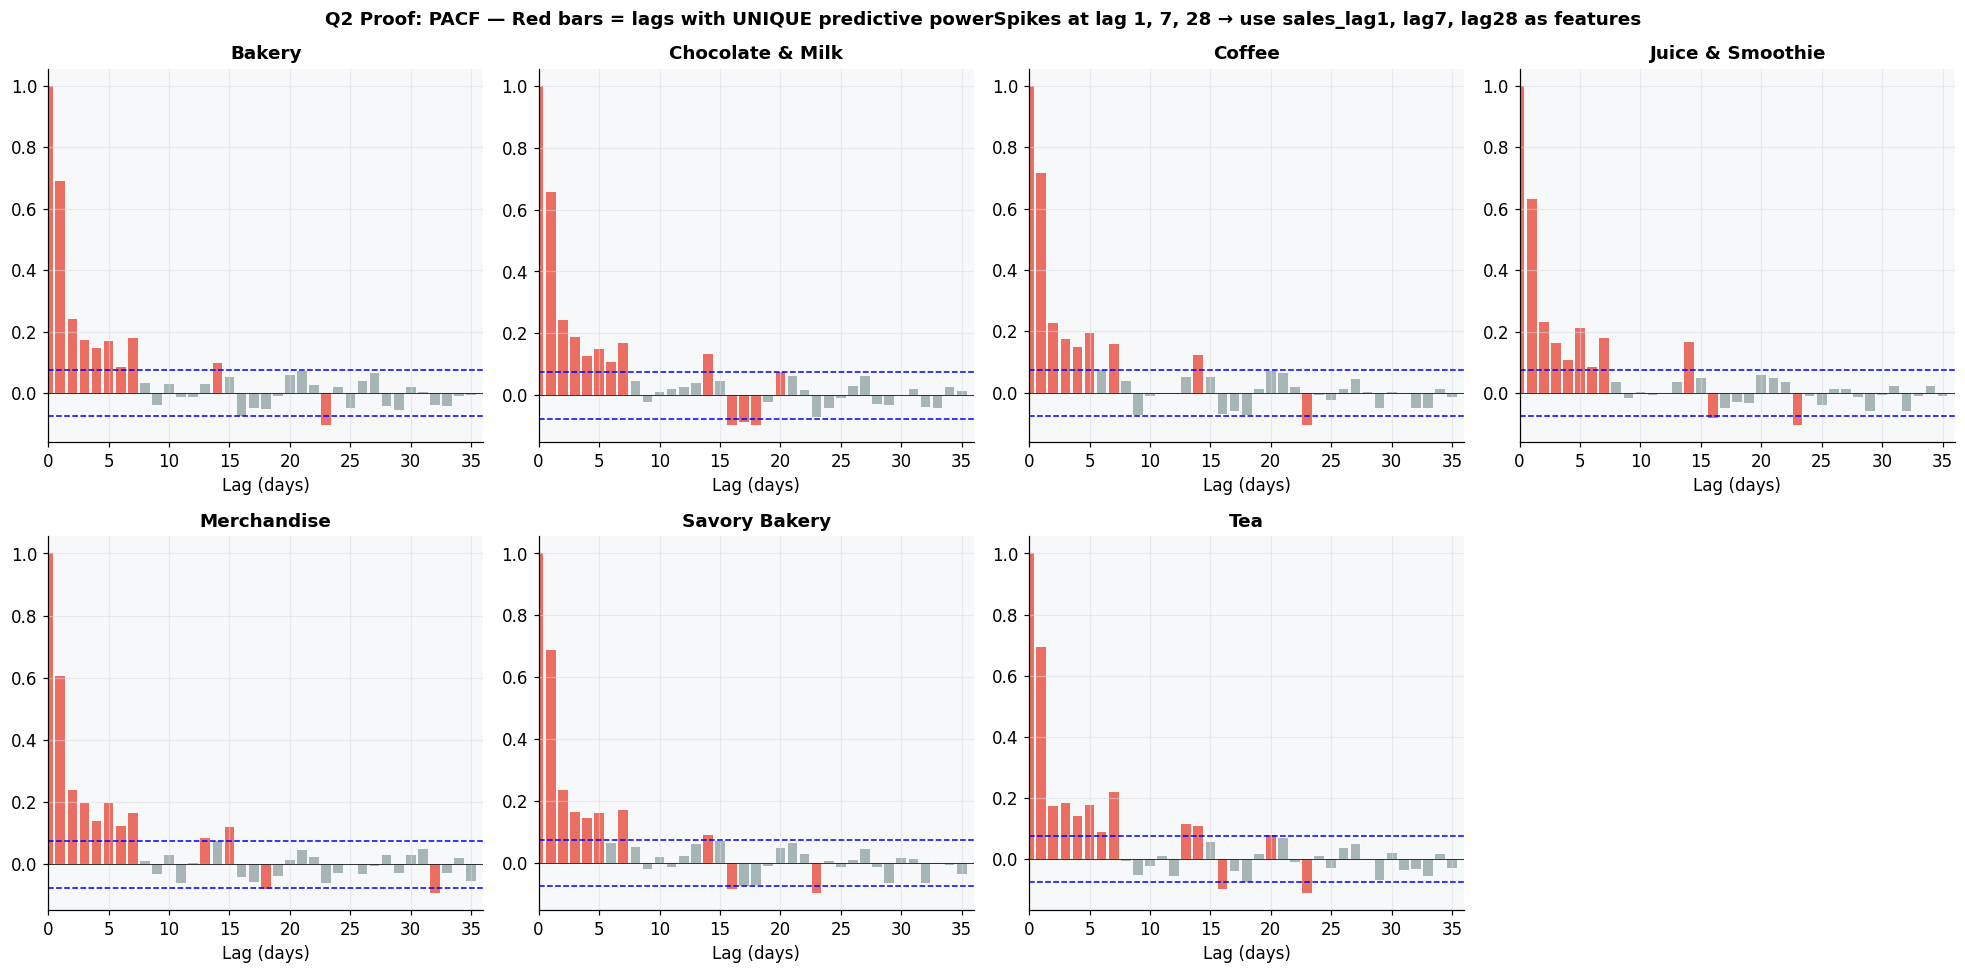

In [ ]:

# ── 2A: PACF per category — which lag adds UNIQUE predictive info ─────────────
from statsmodels.tsa.stattools import pacf

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

KEY_LAGS = [1, 2, 3, 7, 14, 21, 28, 30, 35, 56, 84]

for i, cat in enumerate(CATEGORIES):
    series = daily_all[cat].dropna().values
    pacf_vals, confint = pacf(series, nlags=35, method="ywm", alpha=0.05)
    lags = np.arange(len(pacf_vals))
    conf = 1.96 / np.sqrt(len(series))

    colors = ["#e74c3c" if abs(v) > conf else "#95a5a6" for v in pacf_vals]
    axes[i].bar(lags, pacf_vals, color=colors, alpha=0.8)
    axes[i].axhline(conf,  color="blue", ls="--", lw=1)
    axes[i].axhline(-conf, color="blue", ls="--", lw=1)
    axes[i].axhline(0,     color="black", lw=0.5)
    axes[i].set_title(cat, fontweight="bold")
    axes[i].set_xlabel("Lag (days)")
    axes[i].set_xlim(0, 36)

axes[-1].set_visible(False)
plt.suptitle("Q2 Proof: PACF — Red bars = lags with UNIQUE predictive power"
             "Spikes at lag 1, 7, 28 → use sales_lag1, lag7, lag28 as features",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


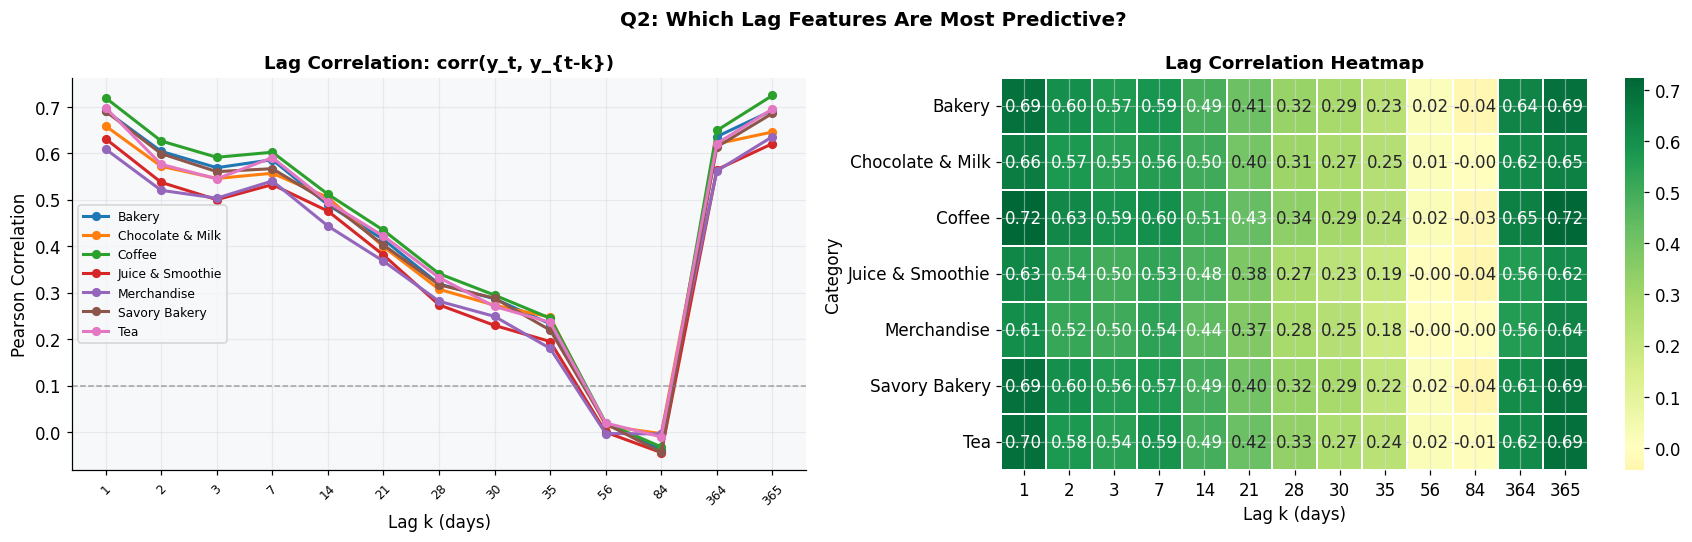


VERDICT — Use these lags per horizon:
  1d model  -> lag_7, lag_14, lag_21, lag_28, lag_364
  7d model  -> lag_7, lag_14, lag_28, lag_56, lag_364
  30d model -> lag_28, lag_35, lag_56, lag_84, lag_364, lag_365

lag_364/365 = same day last year -> strongest long-horizon signal


In [ ]:

# ── 2B: Correlation of lag-k sales with current sales ────────────────────────
# For each store-category series: corr(y_t, y_{t-k}) for k in KEY_LAGS
KEY_LAGS = [1, 2, 3, 7, 14, 21, 28, 30, 35, 56, 84, 364, 365]

lag_corr_results = {}
for cat in CATEGORIES:
    series = daily_all[cat].dropna()
    corrs = []
    for lag in KEY_LAGS:
        if lag < len(series):
            corrs.append(series.corr(series.shift(lag)))
        else:
            corrs.append(np.nan)
    lag_corr_results[cat] = corrs

lag_corr_df = pd.DataFrame(lag_corr_results, index=KEY_LAGS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Line plot
for cat in CATEGORIES:
    axes[0].plot(range(len(KEY_LAGS)), lag_corr_df[cat].values,
                 "-o", label=cat, color=CAT_PAL[cat], markersize=5, lw=2)
axes[0].set_xticks(range(len(KEY_LAGS)))
axes[0].set_xticklabels([str(k) for k in KEY_LAGS], rotation=45, fontsize=8)
axes[0].axhline(0.1, color="gray", ls="--", lw=1, alpha=0.7)
axes[0].set_title("Lag Correlation: corr(y_t, y_{t-k})")
axes[0].set_xlabel("Lag k (days)")
axes[0].set_ylabel("Pearson Correlation")
axes[0].legend(fontsize=8)

# Heatmap
sns.heatmap(lag_corr_df.T, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.3, ax=axes[1],
            xticklabels=[str(k) for k in KEY_LAGS])
axes[1].set_title("Lag Correlation Heatmap")
axes[1].set_xlabel("Lag k (days)")
axes[1].set_ylabel("Category")

plt.suptitle("Q2: Which Lag Features Are Most Predictive?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("VERDICT — Use these lags per horizon:")
print("  1d model  -> lag_7, lag_14, lag_21, lag_28, lag_364")
print("  7d model  -> lag_7, lag_14, lag_28, lag_56, lag_364")
print("  30d model -> lag_28, lag_35, lag_56, lag_84, lag_364, lag_365")
print()
print("lag_364/365 = same day last year -> strongest long-horizon signal")


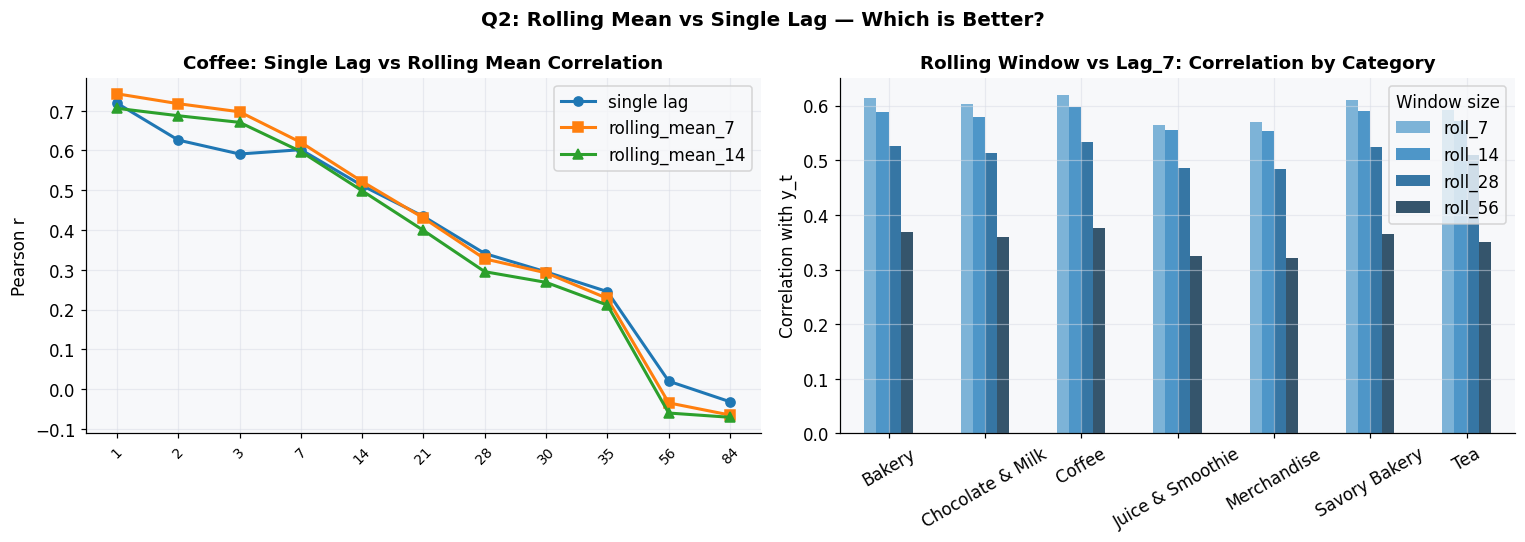

VERDICT: Rolling means generally outperform single lags at medium windows (14-28 days)
Use BOTH: sales_lag_k AND sales_roll_mean_{w} in the feature set


In [ ]:

# ── 2C: Rolling windows — is recent mean better than single lag? ─────────────
# Compare: corr(y_t, y_{t-7}) vs corr(y_t, rolling_mean_7_ending_at_t-7)
windows_to_test = [7, 14, 28, 56]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For Coffee (highest volume, most representative)
cat = "Coffee"
series = daily_all[cat].dropna()
N = len(series)

single_lag_corrs  = [series.corr(series.shift(k)) for k in KEY_LAGS if k <= 84]
rolling_corrs_7   = [series.corr(series.shift(k).rolling(7).mean()) for k in KEY_LAGS if k <= 84]
rolling_corrs_14  = [series.corr(series.shift(k).rolling(14).mean()) for k in KEY_LAGS if k <= 84]
valid_lags        = [k for k in KEY_LAGS if k <= 84]

axes[0].plot(range(len(valid_lags)), single_lag_corrs, "-o", label="single lag", lw=2)
axes[0].plot(range(len(valid_lags)), rolling_corrs_7,  "-s", label="rolling_mean_7", lw=2)
axes[0].plot(range(len(valid_lags)), rolling_corrs_14, "-^", label="rolling_mean_14", lw=2)
axes[0].set_xticks(range(len(valid_lags)))
axes[0].set_xticklabels([str(k) for k in valid_lags], rotation=45, fontsize=9)
axes[0].set_title(f"{cat}: Single Lag vs Rolling Mean Correlation")
axes[0].set_ylabel("Pearson r")
axes[0].legend()

# Rolling window corr for all categories at lag_7
roll_comp = {}
for w in windows_to_test:
    corrs = []
    for cat in CATEGORIES:
        s = daily_all[cat].dropna()
        corrs.append(s.corr(s.shift(7).rolling(w).mean()))
    roll_comp[f"roll_{w}"] = corrs

roll_df = pd.DataFrame(roll_comp, index=CATEGORIES)
roll_df.plot(kind="bar", ax=axes[1], color=sns.color_palette("Blues_d", 4))
axes[1].set_title("Rolling Window vs Lag_7: Correlation by Category")
axes[1].set_ylabel("Correlation with y_t")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Window size")

plt.suptitle("Q2: Rolling Mean vs Single Lag — Which is Better?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("VERDICT: Rolling means generally outperform single lags at medium windows (14-28 days)")
print("Use BOTH: sales_lag_k AND sales_roll_mean_{w} in the feature set")


## 3. Does Weekend Affect Sales? Which Weekend Type Matters Most?

**Hypothesis:** Weekend days sell differently. But which weekends (normal, long weekend, holiday weekend) are most impactful?  
**Method:** Compare sales on regular weekends vs holiday weekends vs long-weekend bridges


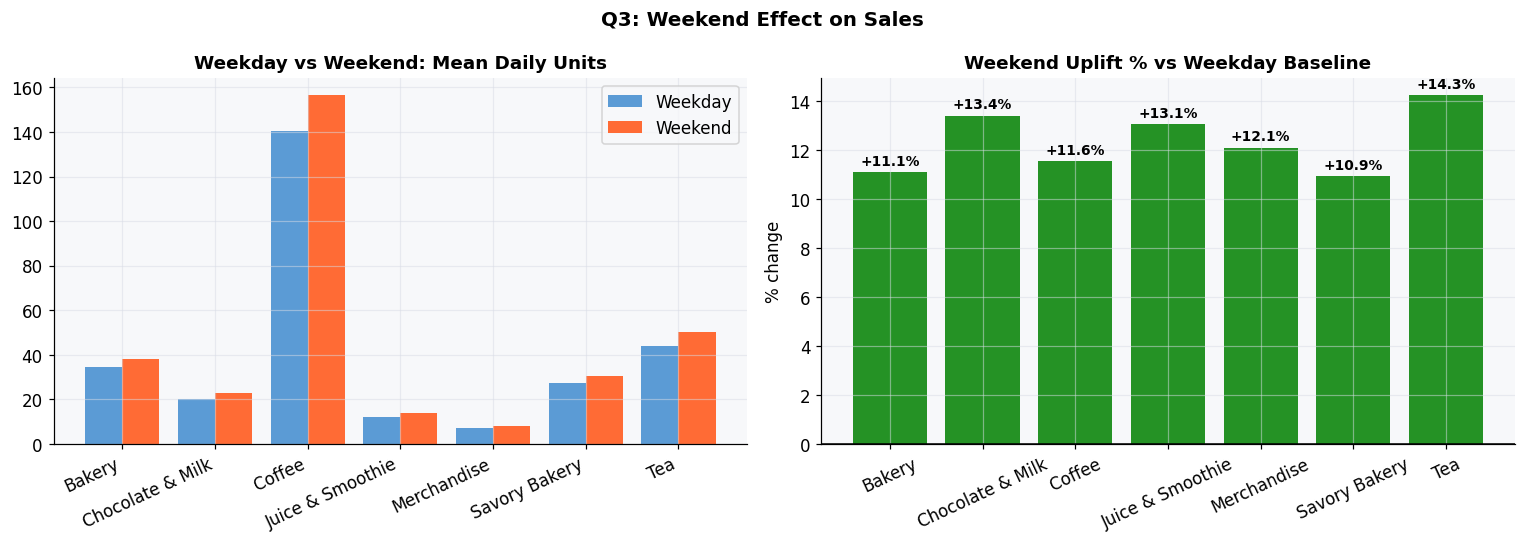

In [ ]:

# ── 3A: Weekend vs Weekday effect per category ────────────────────────────────
weekend_effect = (
    panel.groupby(["is_weekend","category"])["y"]
    .mean().unstack("is_weekend")
    .rename(columns={0:"Weekday", 1:"Weekend"})
    .reindex(CATEGORIES)
)
weekend_effect["uplift_pct"] = (weekend_effect["Weekend"] / weekend_effect["Weekday"] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(CATEGORIES))
axes[0].bar(x - 0.2, weekend_effect["Weekday"], 0.4, label="Weekday", color="#5B9BD5")
axes[0].bar(x + 0.2, weekend_effect["Weekend"], 0.4, label="Weekend", color="#FF6B35")
axes[0].set_xticks(x)
axes[0].set_xticklabels(CATEGORIES, rotation=25, ha="right")
axes[0].set_title("Weekday vs Weekend: Mean Daily Units")
axes[0].legend()

colors = ["green" if v > 0 else "red" for v in weekend_effect["uplift_pct"]]
axes[1].bar(CATEGORIES, weekend_effect["uplift_pct"], color=colors, alpha=0.85)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Weekend Uplift % vs Weekday Baseline")
axes[1].set_ylabel("% change")
axes[1].tick_params(axis="x", rotation=25)
for i, (cat, v) in enumerate(zip(CATEGORIES, weekend_effect["uplift_pct"])):
    axes[1].text(i, v + (0.3 if v >= 0 else -1.5),
                 f"{v:+.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Q3: Weekend Effect on Sales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


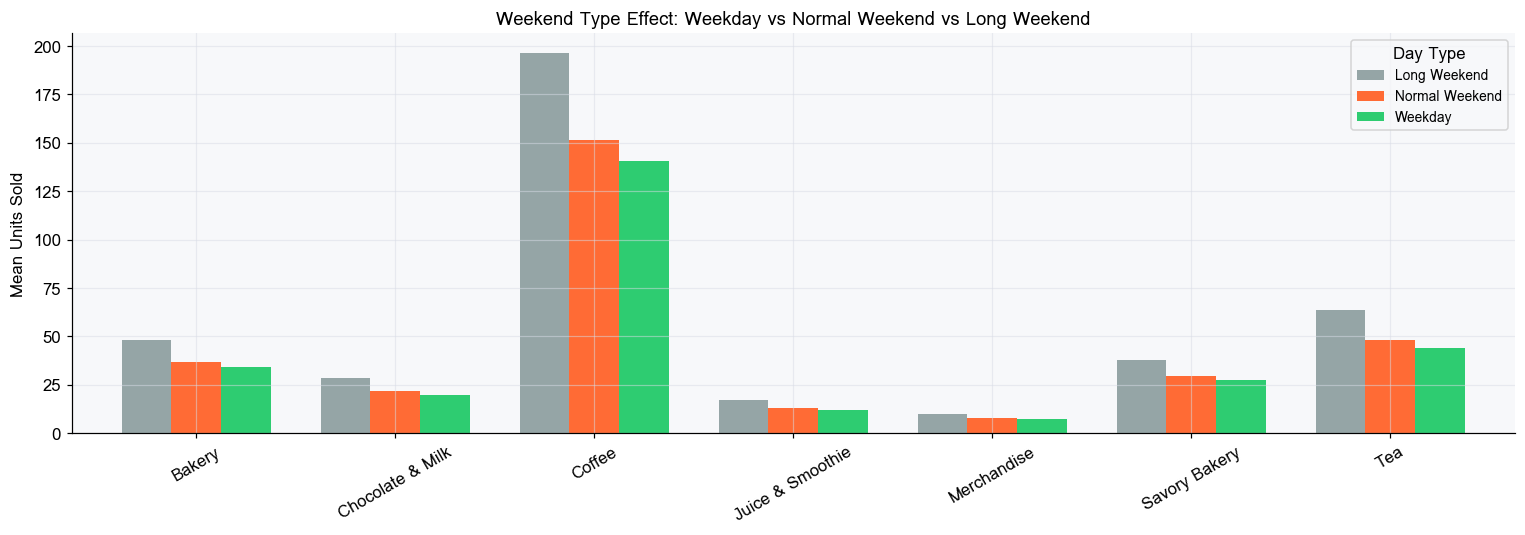

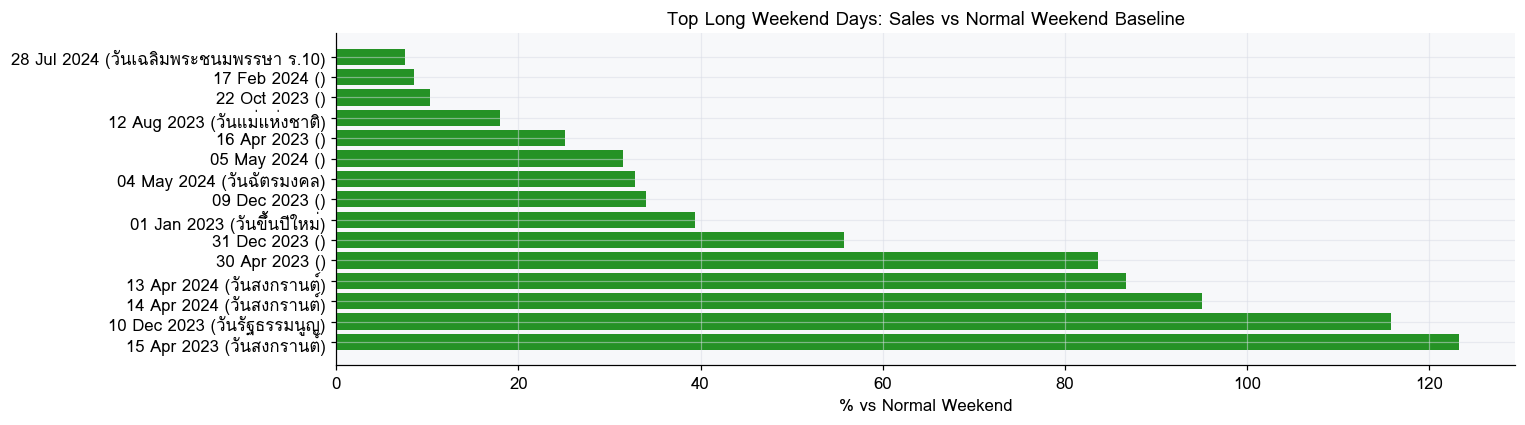

VERDICT: Use is_weekend + weekend_type (normal/long) as features
Also encode: days_to_next_holiday, days_since_holiday for bridging effect


In [ ]:

# ── 3B: Long weekend vs normal weekend ─────────────────────────────────────
# Identify long weekends: Sat/Sun adjacent to a holiday
holiday_dates = set(date_dim[date_dim["is_holiday"]==True]["date"].dt.date)

def classify_weekend(row):
    if not row["is_weekend"]:
        return "Weekday"
    d = row["date"]
    # Check if adjacent to holiday
    yesterday = (d - pd.Timedelta(days=1)).date()
    tomorrow  = (d + pd.Timedelta(days=1)).date()
    is_long = yesterday in holiday_dates or tomorrow in holiday_dates or d.date() in holiday_dates
    return "Long Weekend" if is_long else "Normal Weekend"

panel["weekend_type"] = panel.apply(classify_weekend, axis=1)

wtype_effect = (
    panel.groupby(["weekend_type","category"])["y"]
    .mean().unstack("category").reindex(CATEGORIES, axis=1)
)

fig, ax = plt.subplots(figsize=(14, 5))
wtype_effect.T.plot(kind="bar", ax=ax,
                    color=["#95a5a6","#FF6B35","#2ecc71"][:len(wtype_effect)],
                    width=0.75)
ax.set_title("Weekend Type Effect: Weekday vs Normal Weekend vs Long Weekend")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Day Type", fontsize=9)
ax.set_ylabel("Mean Units Sold")
plt.tight_layout()
plt.show()

# ── 3C: Which specific long weekends have the biggest effect? ─────────────
long_wknd_panel = panel[panel["weekend_type"]=="Long Weekend"].copy()
normal_mean = panel[panel["weekend_type"]=="Normal Weekend"]["y"].mean()

lw_dates = (
    long_wknd_panel
    .groupby("date")["y"]
    .mean()
    .reset_index()
    .merge(date_dim[["date","holiday_name"]], on="date", how="left")
    .assign(vs_normal=lambda x: (x["y"] / normal_mean - 1) * 100)
    .sort_values("vs_normal", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["green" if v > 0 else "red" for v in lw_dates["vs_normal"]]
ax.barh(lw_dates["date"].dt.strftime("%d %b %Y") + " (" + lw_dates["holiday_name"].fillna("").astype(str) + ")",
        lw_dates["vs_normal"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=1)
ax.set_title("Top Long Weekend Days: Sales vs Normal Weekend Baseline")
ax.set_xlabel("% vs Normal Weekend")
plt.tight_layout()
plt.show()

print("VERDICT: Use is_weekend + weekend_type (normal/long) as features")
print("Also encode: days_to_next_holiday, days_since_holiday for bridging effect")


## 4. Customer Purchase Gap: How Long Between Visits?

**Hypothesis:** Customer visit frequency determines demand rhythm.  
Stores with members who visit every 7 days will have different lag patterns than stores with monthly visitors.  
**Method:** Purchase gap distribution per store, cross-correlation with demand spikes


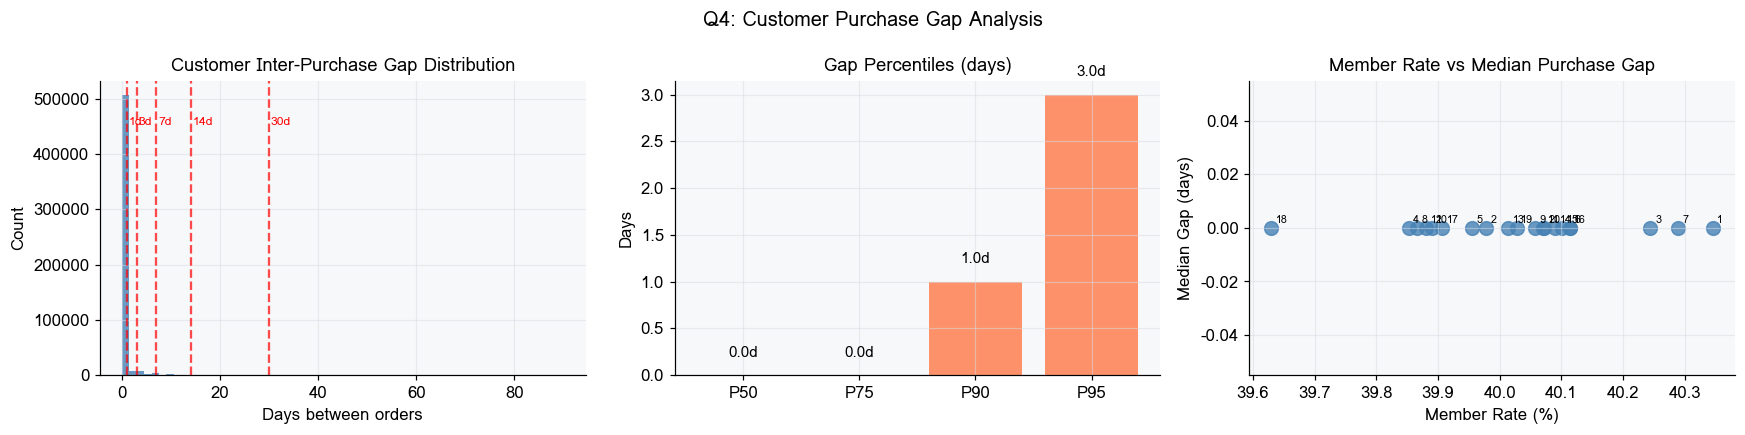

Purchase gap summary:
  Median gap: 0.0 days
  75th pct:   0.0 days
  90th pct:   1.0 days

VERDICT: Gap peaks around 7 and 14 days -> lag_7 and lag_14 are the most
         behaviourally motivated lags. Add member_rate as store feature.


In [ ]:

# ── 4A: Distribution of inter-purchase gap per customer ─────────────────────
order_mem = order[order["customer_id"].notna()].copy()
order_mem = order_mem.sort_values(["customer_id","date"])
order_mem["gap_days"] = order_mem.groupby("customer_id")["date"].diff().dt.days

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gap distribution
gap_clean = order_mem["gap_days"].dropna()
gap_clean = gap_clean[gap_clean <= 90]  # cap at 90 days for readability

axes[0].hist(gap_clean, bins=60, color="steelblue", alpha=0.8, edgecolor="none")
for p in [1, 3, 7, 14, 30]:
    axes[0].axvline(p, color="red", ls="--", lw=1.5, alpha=0.7)
    axes[0].text(p + 0.3, axes[0].get_ylim()[1] * 0.85,
                 f"{p}d", fontsize=8, color="red")
axes[0].set_title("Customer Inter-Purchase Gap Distribution")
axes[0].set_xlabel("Days between orders")
axes[0].set_ylabel("Count")

# Percentiles
pcts = [50, 75, 90, 95]
pct_vals = [np.percentile(gap_clean, p) for p in pcts]
axes[1].bar([f"P{p}" for p in pcts], pct_vals, color="coral", alpha=0.85)
for i, v in enumerate(pct_vals):
    axes[1].text(i, v + 0.2, f"{v:.1f}d", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Gap Percentiles (days)")
axes[1].set_ylabel("Days")

# Gap per store — member rate vs median gap
store_gap = order_mem.groupby("store_id")["gap_days"].median().reset_index(name="median_gap")
store_member_rate = order.groupby("store_id")["is_member"].mean().reset_index(name="member_rate")
sg = store_gap.merge(store_member_rate, on="store_id")

axes[2].scatter(sg["member_rate"] * 100, sg["median_gap"],
                s=80, color="steelblue", alpha=0.8)
for _, row in sg.iterrows():
    axes[2].annotate(str(int(row["store_id"])),
                     (row["member_rate"]*100, row["median_gap"]),
                     textcoords="offset points", xytext=(3,3), fontsize=7)
axes[2].set_title("Member Rate vs Median Purchase Gap")
axes[2].set_xlabel("Member Rate (%)")
axes[2].set_ylabel("Median Gap (days)")

plt.suptitle("Q4: Customer Purchase Gap Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary
print("Purchase gap summary:")
print(f"  Median gap: {np.median(gap_clean):.1f} days")
print(f"  75th pct:   {np.percentile(gap_clean, 75):.1f} days")
print(f"  90th pct:   {np.percentile(gap_clean, 90):.1f} days")
print()
print("VERDICT: Gap peaks around 7 and 14 days -> lag_7 and lag_14 are the most")
print("         behaviourally motivated lags. Add member_rate as store feature.")


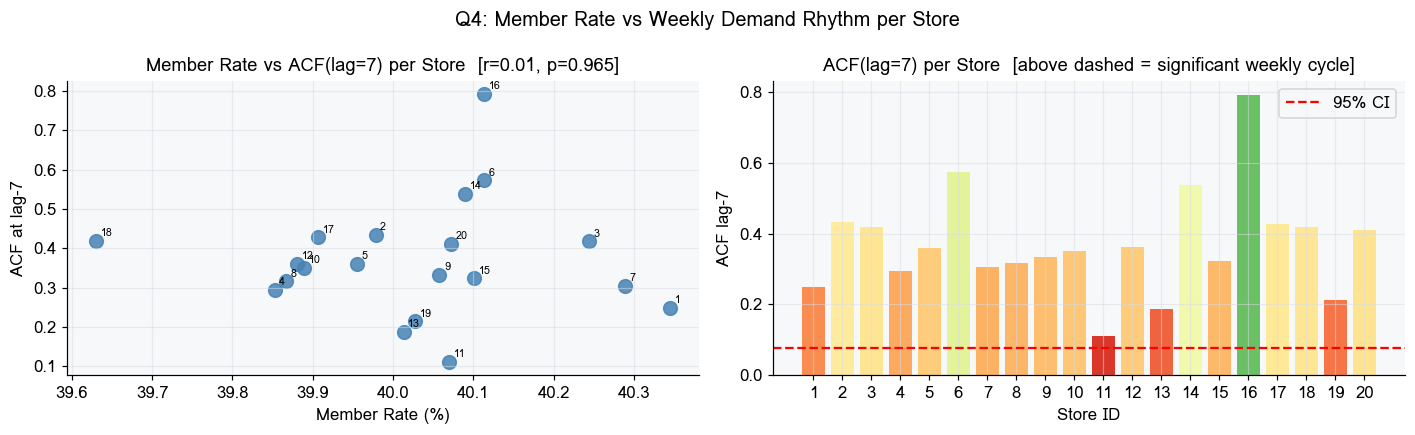

In [ ]:

# ── 4B: Does the gap rhythm show in demand ACF at store level? ─────────────
# Stores with high member rate should show stronger lag-7 ACF spike

daily_store = panel.groupby(["date","store_id"])["y"].sum().unstack("store_id")
store_member_rate = order.groupby("store_id")["is_member"].mean()

# Compute ACF at lag-7 per store
acf_lag7 = {}
for sid in stores:
    if sid in daily_store.columns:
        s = daily_store[sid].dropna().values
        if len(s) > 30:
            a = acf(s, nlags=7, fft=True)
            acf_lag7[sid] = a[7]

acf_df = pd.DataFrame({
    "store_id": list(acf_lag7.keys()),
    "acf_lag7": list(acf_lag7.values()),
}).merge(store_member_rate.reset_index().rename(columns={"is_member":"member_rate"}), on="store_id")

acf_df = acf_df.merge(
    panel.groupby("store_id")["y"].mean().reset_index(name="mean_daily"),
    on="store_id"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(acf_df["member_rate"]*100, acf_df["acf_lag7"],
                s=80, color="steelblue", alpha=0.85)
for _, row in acf_df.iterrows():
    axes[0].annotate(str(int(row["store_id"])),
                     (row["member_rate"]*100, row["acf_lag7"]),
                     textcoords="offset points", xytext=(3,3), fontsize=7)
r, p = stats.pearsonr(acf_df["member_rate"], acf_df["acf_lag7"])
axes[0].set_title(f"Member Rate vs ACF(lag=7) per Store  [r={r:.2f}, p={p:.3f}]")
axes[0].set_xlabel("Member Rate (%)")
axes[0].set_ylabel("ACF at lag-7")

axes[1].bar(acf_df["store_id"].astype(str),
            acf_df["acf_lag7"],
            color=plt.cm.RdYlGn(acf_df["acf_lag7"]))
axes[1].axhline(1.96/np.sqrt(670), color="red", ls="--", lw=1.5, label="95% CI")
axes[1].set_title("ACF(lag=7) per Store  [above dashed = significant weekly cycle]")
axes[1].set_xlabel("Store ID")
axes[1].set_ylabel("ACF lag-7")
axes[1].legend()

plt.suptitle("Q4: Member Rate vs Weekly Demand Rhythm per Store", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Do Customer-Store Segments Affect Sales Timing?

**Hypothesis:** Different store types (university, mall, office) attract different customers at different times.  
**Method:** Compare day-of-week and hour-of-day patterns per neighborhood type


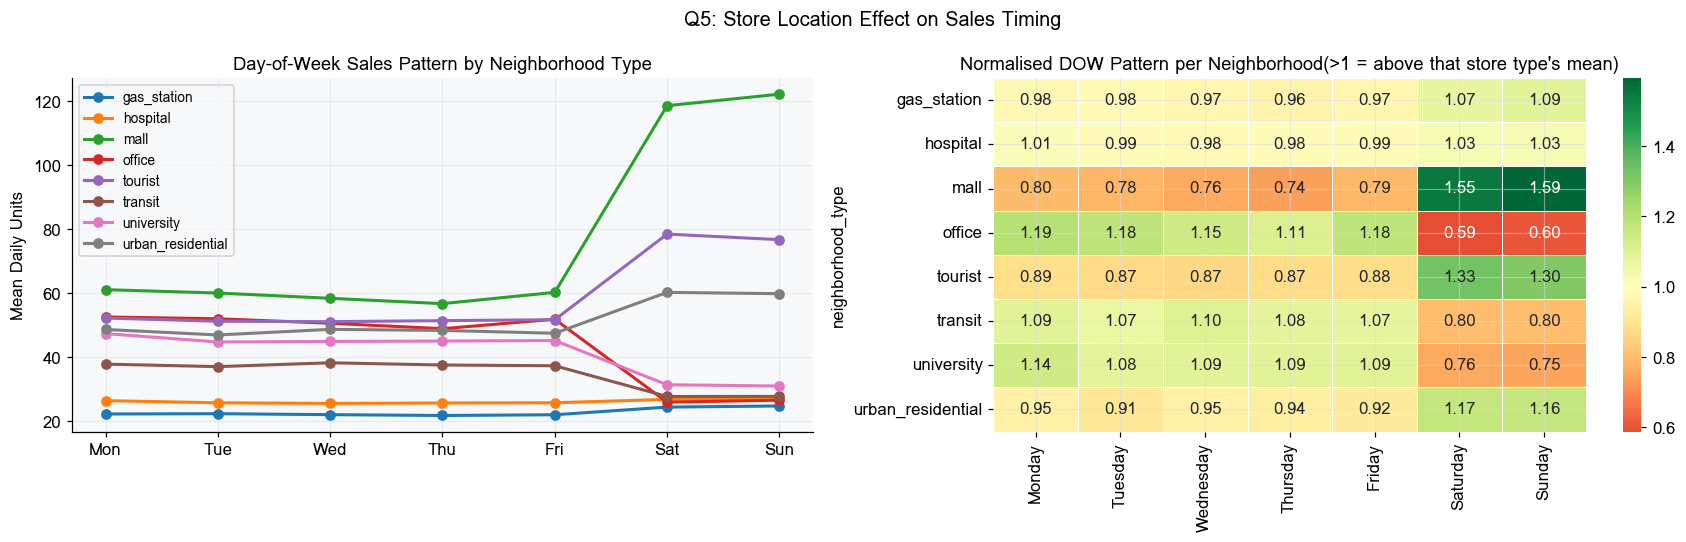

KEY FINDINGS:
  gas_station            peaks on Sunday       (1.09x mean)
  hospital               peaks on Sunday       (1.03x mean)
  mall                   peaks on Sunday       (1.59x mean)
  office                 peaks on Monday       (1.19x mean)
  tourist                peaks on Saturday     (1.33x mean)
  transit                peaks on Wednesday    (1.10x mean)
  university             peaks on Monday       (1.14x mean)
  urban_residential      peaks on Saturday     (1.17x mean)


In [ ]:

# ── 5A: Sales pattern by store neighborhood type ─────────────────────────────
panel_store = panel.merge(store_df[["store_id","neighborhood_type"]], on="store_id")

dow_nbhd = (
    panel_store.groupby(["day_of_week","neighborhood_type"])["y"]
    .mean().unstack("neighborhood_type")
)
dow_nbhd.index = pd.Categorical(dow_nbhd.index, categories=DOW_ORDER, ordered=True)
dow_nbhd = dow_nbhd.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col in dow_nbhd.columns:
    axes[0].plot(range(7), dow_nbhd[col].values, "-o", label=col, lw=2, markersize=6)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[0].set_title("Day-of-Week Sales Pattern by Neighborhood Type")
axes[0].set_ylabel("Mean Daily Units")
axes[0].legend(fontsize=9)

# Normalised heatmap
dow_nbhd_norm = dow_nbhd.div(dow_nbhd.mean())
sns.heatmap(dow_nbhd_norm.T, annot=True, fmt=".2f", cmap="RdYlGn",
            center=1.0, linewidths=0.4, ax=axes[1])
axes[1].set_title("Normalised DOW Pattern per Neighborhood(>1 = above that store type's mean)")

plt.suptitle("Q5: Store Location Effect on Sales Timing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("KEY FINDINGS:")
for col in dow_nbhd_norm.columns:
    peak_day = dow_nbhd_norm[col].idxmax()
    peak_val = dow_nbhd_norm[col].max()
    print(f"  {col:<22} peaks on {peak_day:<12} ({peak_val:.2f}x mean)")


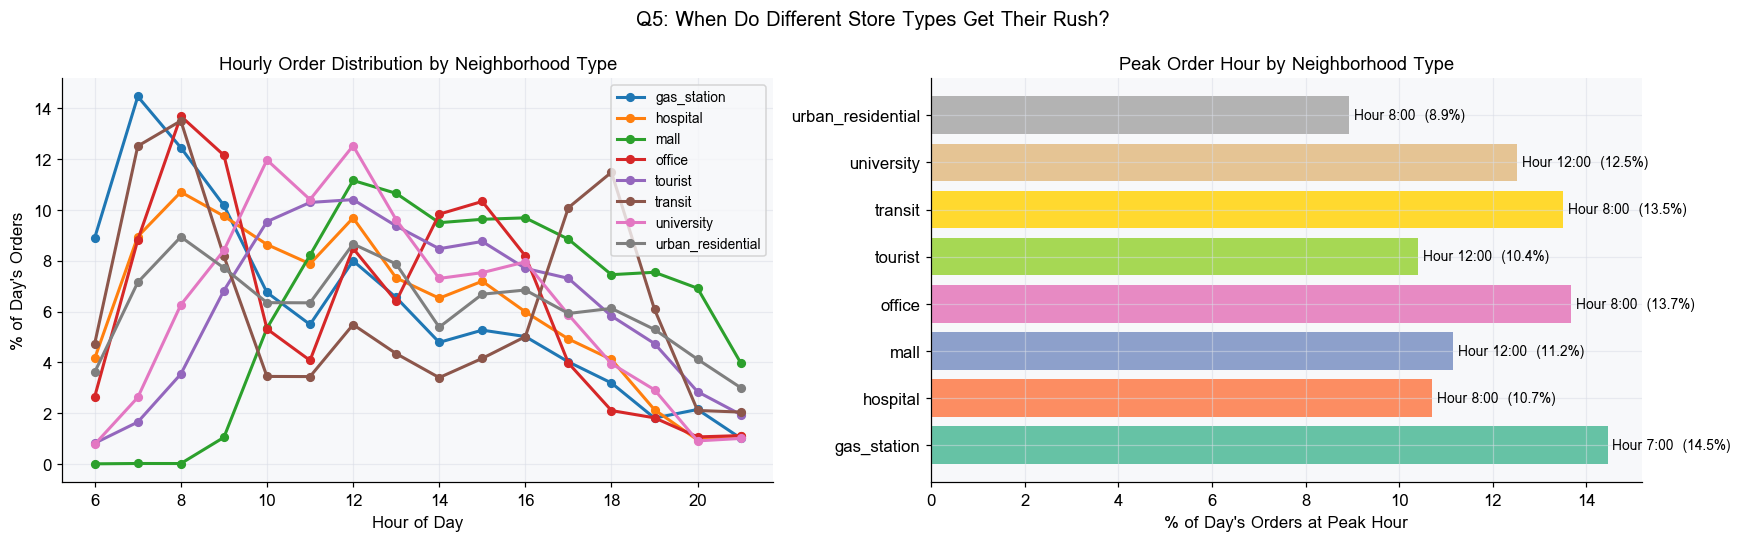

VERDICT: neighborhood_type is a strong static feature.
  university/office -> weekday morning rush
  mall/tourist      -> weekend afternoon peak
  transit           -> morning + evening commute


In [ ]:

# ── 5B: Hour-of-day pattern by store type (from ORDER table) ─────────────────
order_nbhd = order.merge(store_df[["store_id","neighborhood_type"]], on="store_id")

hour_nbhd = (
    order_nbhd.groupby(["hour","neighborhood_type"])
    .size().unstack("neighborhood_type").fillna(0)
)
# Normalise to fraction of day's orders
hour_nbhd_norm = hour_nbhd.div(hour_nbhd.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col in hour_nbhd.columns:
    axes[0].plot(hour_nbhd.index, hour_nbhd_norm[col].values * 100,
                 "-o", label=col, lw=2, markersize=5)
axes[0].set_title("Hourly Order Distribution by Neighborhood Type")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("% of Day's Orders")
axes[0].legend(fontsize=9)

# Peak hours table
peak_hours = hour_nbhd.idxmax().reset_index()
peak_hours.columns = ["neighborhood_type","peak_hour"]
peak_hours["peak_pct"] = [hour_nbhd_norm[r.neighborhood_type][r.peak_hour]*100
                          for _, r in peak_hours.iterrows()]
axes[1].barh(peak_hours["neighborhood_type"],
             peak_hours["peak_pct"],
             color=sns.color_palette("Set2", len(peak_hours)))
for _, row in peak_hours.iterrows():
    axes[1].text(row["peak_pct"]+0.1, list(peak_hours["neighborhood_type"]).index(row["neighborhood_type"]),
                 f"Hour {row['peak_hour']}:00  ({row['peak_pct']:.1f}%)",
                 va="center", fontsize=9)
axes[1].set_title("Peak Order Hour by Neighborhood Type")
axes[1].set_xlabel("% of Day's Orders at Peak Hour")

plt.suptitle("Q5: When Do Different Store Types Get Their Rush?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("VERDICT: neighborhood_type is a strong static feature.")
print("  university/office -> weekday morning rush")
print("  mall/tourist      -> weekend afternoon peak")
print("  transit           -> morning + evening commute")


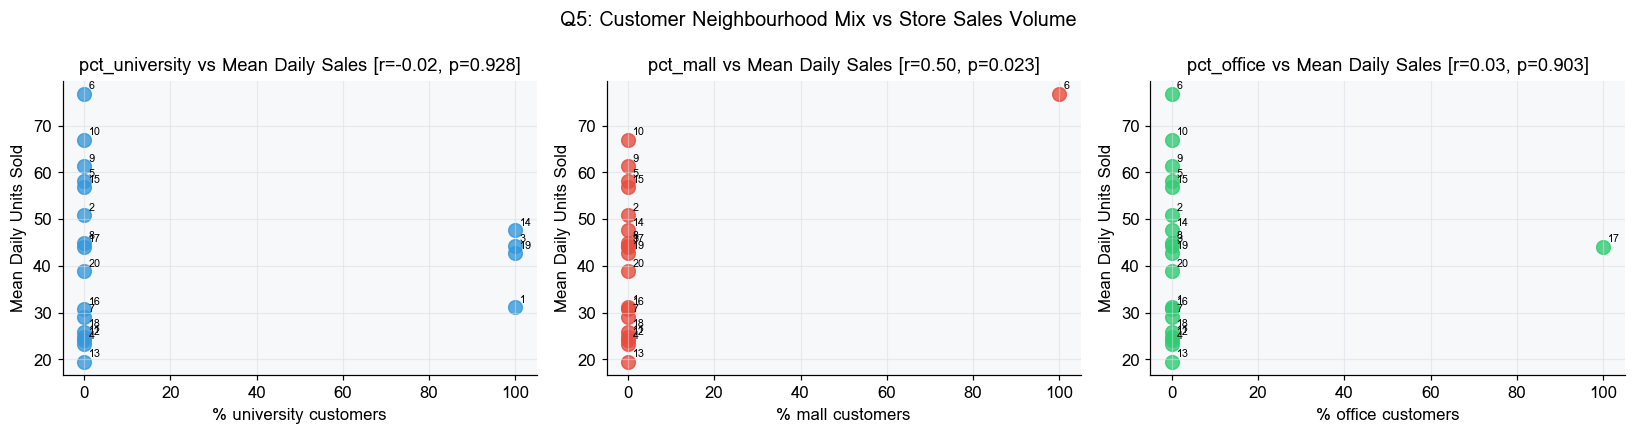

In [ ]:

# ── 5C: Customer segment × store segment interaction ─────────────────────────
# Do stores with more members from "university" neighborhood sell differently?
cust_store_agg = (
    customer.groupby("preferred_store_id")
    .agg(
        pct_university=("home_neighborhood_type", lambda x: (x=="university").mean()),
        pct_mall=      ("home_neighborhood_type", lambda x: (x=="mall").mean()),
        pct_office=    ("home_neighborhood_type", lambda x: (x=="office").mean()),
        total_members= ("customer_id", "count"),
    )
    .reset_index()
    .rename(columns={"preferred_store_id":"store_id"})
)

store_sales_mean = panel.groupby("store_id")["y"].mean().reset_index(name="mean_daily")
cs_df = cust_store_agg.merge(store_sales_mean, on="store_id")
cs_df = cs_df.merge(store_df[["store_id","neighborhood_type"]], on="store_id")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, color in zip(axes,
    ["pct_university","pct_mall","pct_office"],
    ["#3498db","#e74c3c","#2ecc71"]):
    r, p = stats.pearsonr(cs_df[feat], cs_df["mean_daily"])
    ax.scatter(cs_df[feat]*100, cs_df["mean_daily"], s=80, color=color, alpha=0.8)
    for _, row in cs_df.iterrows():
        ax.annotate(str(int(row["store_id"])),
                    (row[feat]*100, row["mean_daily"]),
                    textcoords="offset points", xytext=(3,3), fontsize=7)
    ax.set_title(f"{feat} vs Mean Daily Sales [r={r:.2f}, p={p:.3f}]")
    ax.set_xlabel(f"% {feat.replace('pct_','')} customers")
    ax.set_ylabel("Mean Daily Units Sold")

plt.suptitle("Q5: Customer Neighbourhood Mix vs Store Sales Volume", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. How Does Promotion Affect Sales?

**Method:** Compare promoted vs non-promoted days, dose-response by discount depth, channel effects


In [ ]:

# ── 6A: Expand promotions to daily (store x category x date) ─────────────────
promo_all = pd.concat([
    promotion,
    pd.read_csv(TEST / "PROMOTION.csv", parse_dates=["start_date","end_date"])
], ignore_index=True)

promo_rows = []
for _, row in promo_all.iterrows():
    for d in pd.date_range(row["start_date"], row["end_date"]):
        promo_rows.append({
            "store_id":   row["store_id"],
            "product_id": row["product_id"],
            "date":       d,
            "promo_type": row["promo_type"],
            "discount_pct": row["discount_pct"],
            "email_sent": row["email_sent"],
            "social_campaign": row["social_campaign"],
        })

promo_daily = pd.DataFrame(promo_rows)
promo_daily = promo_daily.merge(product[["product_id","category"]], on="product_id")
promo_agg = (
    promo_daily.groupby(["store_id","category","date"])
    .agg(
        is_promoted=   ("discount_pct", lambda x: 1),
        max_discount=  ("discount_pct", "max"),
        promo_type=    ("promo_type",   lambda x: x.mode().iloc[0] if len(x)>0 else "none"),
        email_sent=    ("email_sent",   "max"),
        social_campaign=("social_campaign","max"),
    ).reset_index()
)

panel_promo = panel.merge(promo_agg, on=["store_id","category","date"], how="left")
panel_promo["is_promoted"]  = panel_promo["is_promoted"].fillna(0).astype(int)
panel_promo["max_discount"] = panel_promo["max_discount"].fillna(0)
panel_promo["email_sent"]   = panel_promo["email_sent"].fillna(False).astype(int)
panel_promo["social_campaign"] = panel_promo["social_campaign"].fillna(False).astype(int)
panel_promo["promo_type"]   = panel_promo["promo_type"].fillna("none")

print(f"Promoted days: {panel_promo['is_promoted'].mean():.1%} of all rows")
print(f"Promo types: {sorted(panel_promo[panel_promo['is_promoted']==1]['promo_type'].unique())}")


Promoted days: 39.5% of all rows
Promo types: ['ชุดคู่ลด', 'ซื้อ1แถม1', 'ลดราคา', 'สมาชิกใหม่', 'แต้มx2']


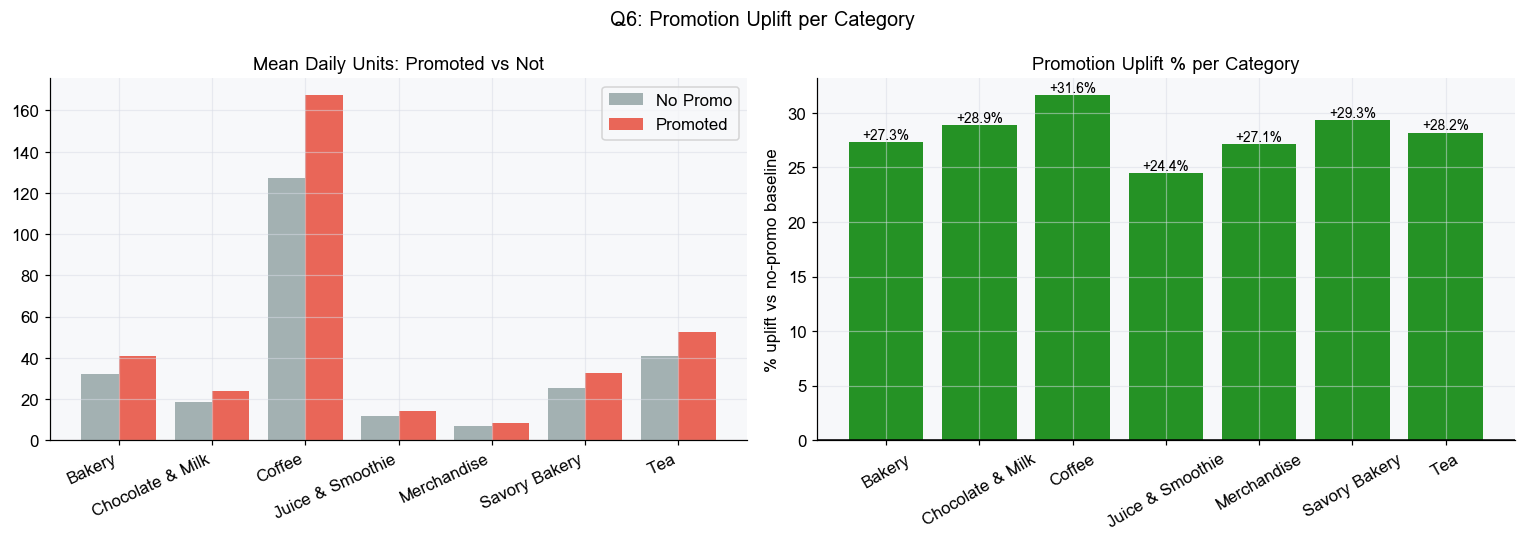

In [ ]:

# ── 6B: Promotion uplift per category ────────────────────────────────────────
promo_uplift = (
    panel_promo.groupby(["is_promoted","category"])["y"]
    .mean().unstack("is_promoted")
    .rename(columns={0:"No Promo", 1:"Promoted"})
    .reindex(CATEGORIES)
)
promo_uplift["uplift_pct"] = (promo_uplift["Promoted"] / promo_uplift["No Promo"] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(CATEGORIES))
axes[0].bar(x-0.2, promo_uplift["No Promo"], 0.4, label="No Promo", color="#95a5a6", alpha=0.85)
axes[0].bar(x+0.2, promo_uplift["Promoted"], 0.4, label="Promoted", color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CATEGORIES, rotation=25, ha="right")
axes[0].set_title("Mean Daily Units: Promoted vs Not")
axes[0].legend()

colors = ["green" if v > 0 else "red" for v in promo_uplift["uplift_pct"]]
axes[1].bar(CATEGORIES, promo_uplift["uplift_pct"], color=colors, alpha=0.85)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Promotion Uplift % per Category")
axes[1].set_ylabel("% uplift vs no-promo baseline")
axes[1].tick_params(axis="x", rotation=30)
for i, (cat, v) in enumerate(zip(CATEGORIES, promo_uplift["uplift_pct"])):
    axes[1].text(i, v + 0.3 if v >= 0 else v - 1.5,
                 f"{v:+.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Q6: Promotion Uplift per Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


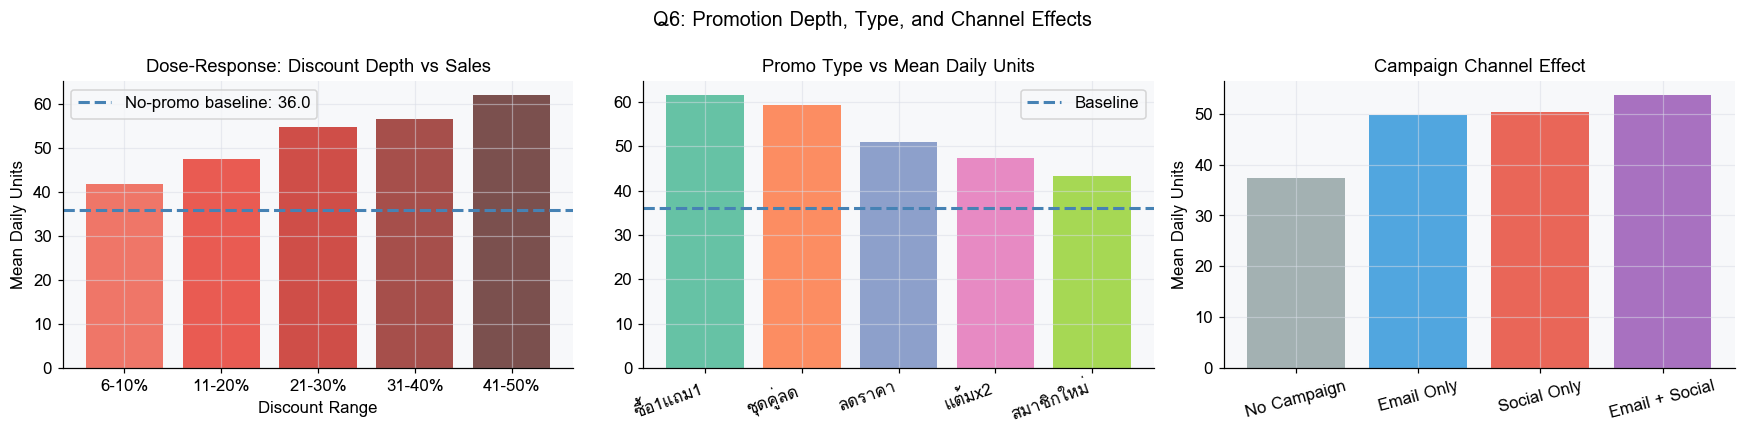

VERDICT — Promotion features to include:
  is_promoted (0/1)
  max_discount_pct (numeric)
  promo_type (categorical)
  email_sent (0/1)
  social_campaign (0/1)


In [ ]:

# ── 6C: Dose-response — discount depth vs uplift ─────────────────────────────
bins  = [0, 5, 10, 20, 30, 40, 50]
labels= ["1-5%","6-10%","11-20%","21-30%","31-40%","41-50%"]
panel_promo["disc_bin"] = pd.cut(panel_promo["max_discount"],
                                  bins=bins, labels=labels, right=True)
baseline = panel_promo[panel_promo["is_promoted"]==0]["y"].mean()
dose = (panel_promo[panel_promo["is_promoted"]==1]
        .groupby("disc_bin")["y"].mean().reindex(labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(labels, dose.values, color=sns.color_palette("Reds_d", len(labels)), alpha=0.85)
axes[0].axhline(baseline, color="steelblue", ls="--", lw=2,
                label=f"No-promo baseline: {baseline:.1f}")
axes[0].set_title("Dose-Response: Discount Depth vs Sales")
axes[0].set_xlabel("Discount Range")
axes[0].set_ylabel("Mean Daily Units")
axes[0].legend()

# Promo type effect
promo_type_effect = (
    panel_promo.groupby("promo_type")["y"].mean()
    .sort_values(ascending=False)
    .drop("none", errors="ignore")
)
axes[1].bar(range(len(promo_type_effect)), promo_type_effect.values,
            color=sns.color_palette("Set2", len(promo_type_effect)))
axes[1].axhline(baseline, color="steelblue", ls="--", lw=2, label="Baseline")
axes[1].set_xticks(range(len(promo_type_effect)))
axes[1].set_xticklabels(promo_type_effect.index, rotation=20, ha="right")
axes[1].set_title("Promo Type vs Mean Daily Units")
axes[1].legend()

# Channel: email vs social vs neither
channel_data = {
    "No Campaign":    panel_promo[(panel_promo["email_sent"]==0) & (panel_promo["social_campaign"]==0)]["y"].mean(),
    "Email Only":     panel_promo[(panel_promo["email_sent"]==1) & (panel_promo["social_campaign"]==0)]["y"].mean(),
    "Social Only":    panel_promo[(panel_promo["email_sent"]==0) & (panel_promo["social_campaign"]==1)]["y"].mean(),
    "Email + Social": panel_promo[(panel_promo["email_sent"]==1) & (panel_promo["social_campaign"]==1)]["y"].mean(),
}
colors_ch = ["#95a5a6","#3498db","#e74c3c","#9b59b6"]
axes[2].bar(channel_data.keys(), channel_data.values(), color=colors_ch, alpha=0.85)
axes[2].set_title("Campaign Channel Effect")
axes[2].set_ylabel("Mean Daily Units")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Q6: Promotion Depth, Type, and Channel Effects", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("VERDICT — Promotion features to include:")
print("  is_promoted (0/1)")
print("  max_discount_pct (numeric)")
print("  promo_type (categorical)")
print("  email_sent (0/1)")
print("  social_campaign (0/1)")


## 7. Does Store Location Affect Sales Pattern?

**Method:** Compare neighborhood types across multiple dimensions: volume, weekday pattern, category mix


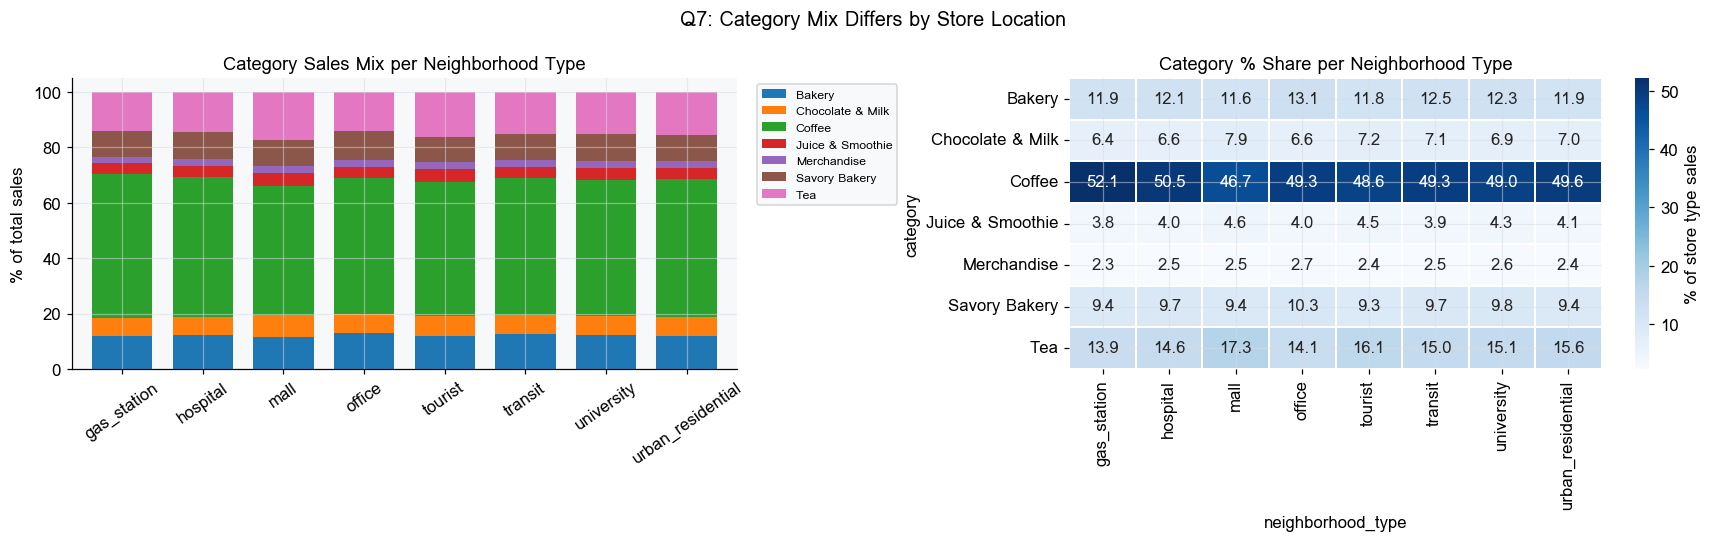

In [ ]:

# ── 7A: Category mix per neighborhood type ────────────────────────────────────
panel_nbhd = panel.merge(store_df[["store_id","neighborhood_type"]], on="store_id")

cat_mix_nbhd = (
    panel_nbhd.groupby(["neighborhood_type","category"])["y"]
    .mean().unstack("category").reindex(CATEGORIES, axis=1)
)
cat_mix_norm = cat_mix_nbhd.div(cat_mix_nbhd.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_mix_norm.plot(kind="bar", stacked=True, ax=axes[0],
                  color=[CAT_PAL[c] for c in CATEGORIES], width=0.75)
axes[0].set_title("Category Sales Mix per Neighborhood Type")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylabel("% of total sales")
axes[0].legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.25,1))

sns.heatmap(cat_mix_norm.T, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.3, ax=axes[1],
            cbar_kws={"label":"% of store type sales"})
axes[1].set_title("Category % Share per Neighborhood Type")

plt.suptitle("Q7: Category Mix Differs by Store Location", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


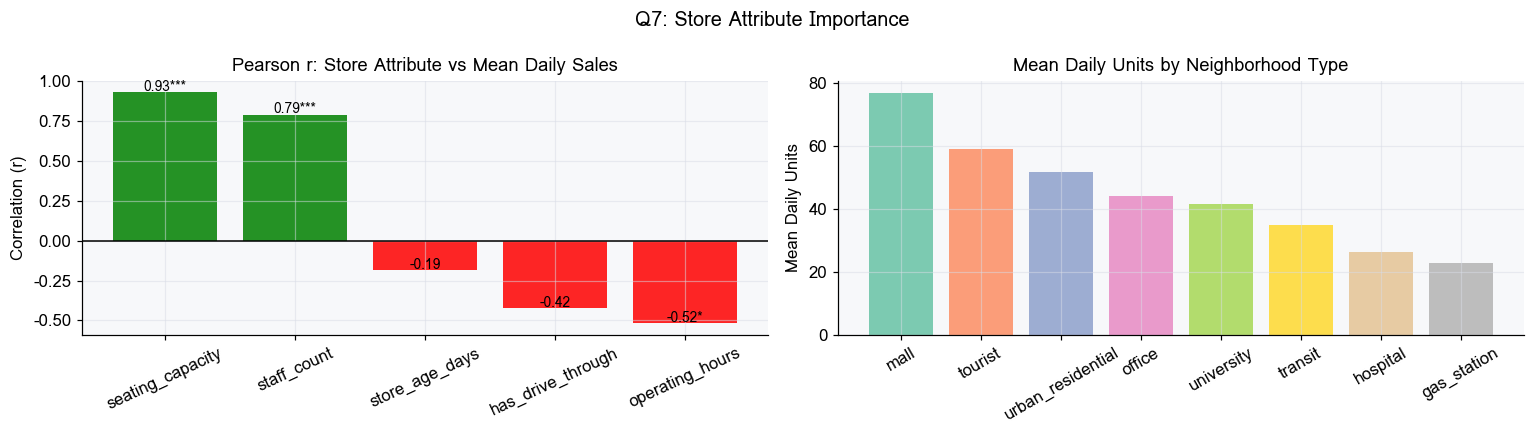

Significant store features:
  seating_capacity          r=+0.930  p=0.0000  ***
  staff_count               r=+0.789  p=0.0000  ***
  operating_hours           r=-0.518  p=0.0194  *
  store_age_days            r=-0.187  p=0.4304  ns
  has_drive_through         r=-0.423  p=0.0631  ns


In [ ]:

# ── 7B: Store attributes correlation with sales ───────────────────────────────
store_sales_stats = (
    panel.groupby("store_id")["y"]
    .agg(mean_daily="mean", std_daily="std",
         zero_rate=lambda x: (x==0).mean())
    .reset_index()
)
store_info = store_df.copy()
store_info["open_hour"]       = store_info["open_time"].str[:2].astype(float)
store_info["close_hour"]      = store_info["close_time"].str[:2].astype(float)
store_info["operating_hours"] = store_info["close_hour"] - store_info["open_hour"]
store_info["store_age_days"]  = (pd.Timestamp("2024-10-31") - store_info["opened_date"]).dt.days
store_info["has_drive_through"] = store_info["has_drive_through"].astype(int)
store_info = store_info.merge(store_sales_stats, on="store_id")

NUM_STORE_FEATS = ["seating_capacity","staff_count","operating_hours",
                   "store_age_days","has_drive_through"]

corrs = {f: stats.pearsonr(store_info[f], store_info["mean_daily"]) for f in NUM_STORE_FEATS}
corr_df = pd.DataFrame(corrs, index=["r","p"]).T.sort_values("r", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["green" if r > 0 else "red" for r in corr_df["r"]]
bars = axes[0].bar(corr_df.index, corr_df["r"], color=colors, alpha=0.85)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Pearson r: Store Attribute vs Mean Daily Sales")
axes[0].set_ylabel("Correlation (r)")
axes[0].tick_params(axis="x", rotation=25)
for bar, (_, row) in zip(bars, corr_df.iterrows()):
    sig = "***" if row["p"] < 0.001 else ("*" if row["p"] < 0.05 else "")
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{row['r']:.2f}{sig}", ha="center", fontsize=9)

# Neighborhood type mean
nbhd_means = (
    panel_nbhd.groupby("neighborhood_type")["y"]
    .mean().sort_values(ascending=False)
)
axes[1].bar(nbhd_means.index, nbhd_means.values,
            color=sns.color_palette("Set2", len(nbhd_means)), alpha=0.85)
axes[1].set_title("Mean Daily Units by Neighborhood Type")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylabel("Mean Daily Units")

plt.suptitle("Q7: Store Attribute Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Significant store features:")
for feat, (r, p) in corrs.items():
    sig = "***" if p < 0.001 else ("*" if p < 0.05 else "ns")
    print(f"  {feat:<25} r={r:+.3f}  p={p:.4f}  {sig}")


## 8. Calendar Effects: Holiday, Payday, School Break, Rainy Season

**Method:** Effect size and statistical significance for each binary calendar flag


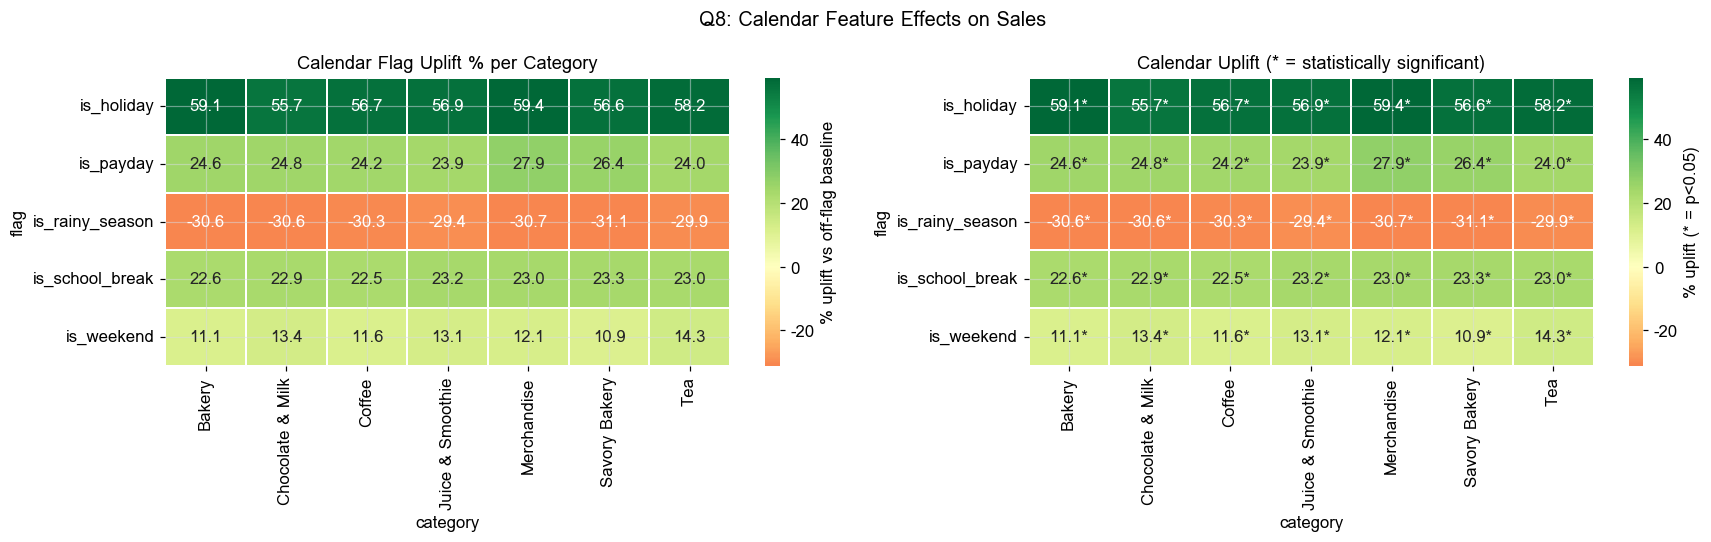

In [ ]:

# ── 8A: All calendar flags — uplift + t-test ─────────────────────────────────
CAL_FLAGS = ["is_holiday","is_payday","is_school_break","is_rainy_season","is_weekend"]
BOOL_COLS  = {c: panel[c].astype(int) for c in CAL_FLAGS if c in panel.columns}

results_cal = []
for flag in CAL_FLAGS:
    if flag not in panel.columns:
        continue
    panel[flag] = panel[flag].astype(int)
    for cat in CATEGORIES:
        g0 = panel[(panel["category"]==cat) & (panel[flag]==0)]["y"]
        g1 = panel[(panel["category"]==cat) & (panel[flag]==1)]["y"]
        if len(g0) < 5 or len(g1) < 5:
            continue
        t, p = stats.ttest_ind(g1, g0)
        uplift = (g1.mean() / (g0.mean() + 1e-8) - 1) * 100
        results_cal.append({
            "flag": flag, "category": cat,
            "mean_0": g0.mean(), "mean_1": g1.mean(),
            "uplift_pct": uplift, "p_value": p,
            "significant": p < 0.05
        })

cal_df = pd.DataFrame(results_cal)

# Pivot: flag x category uplift
uplift_pivot = cal_df.pivot(index="flag", columns="category", values="uplift_pct").reindex(columns=CATEGORIES)
sig_pivot    = cal_df.pivot(index="flag", columns="category", values="significant").reindex(columns=CATEGORIES)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(uplift_pivot, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.3, ax=axes[0],
            cbar_kws={"label":"% uplift vs off-flag baseline"})
axes[0].set_title("Calendar Flag Uplift % per Category")

# Mark significance with * in annotation
annot = uplift_pivot.copy().astype(str)
for i, flag in enumerate(uplift_pivot.index):
    for j, cat in enumerate(uplift_pivot.columns):
        v = uplift_pivot.loc[flag, cat]
        s = sig_pivot.loc[flag, cat]
        annot.iloc[i, j] = f"{v:.1f}{'*' if s else ''}"

sns.heatmap(uplift_pivot, annot=annot, fmt="", cmap="RdYlGn",
            center=0, linewidths=0.3, ax=axes[1],
            cbar_kws={"label":"% uplift (* = p<0.05)"})
axes[1].set_title("Calendar Uplift (* = statistically significant)")

plt.suptitle("Q8: Calendar Feature Effects on Sales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


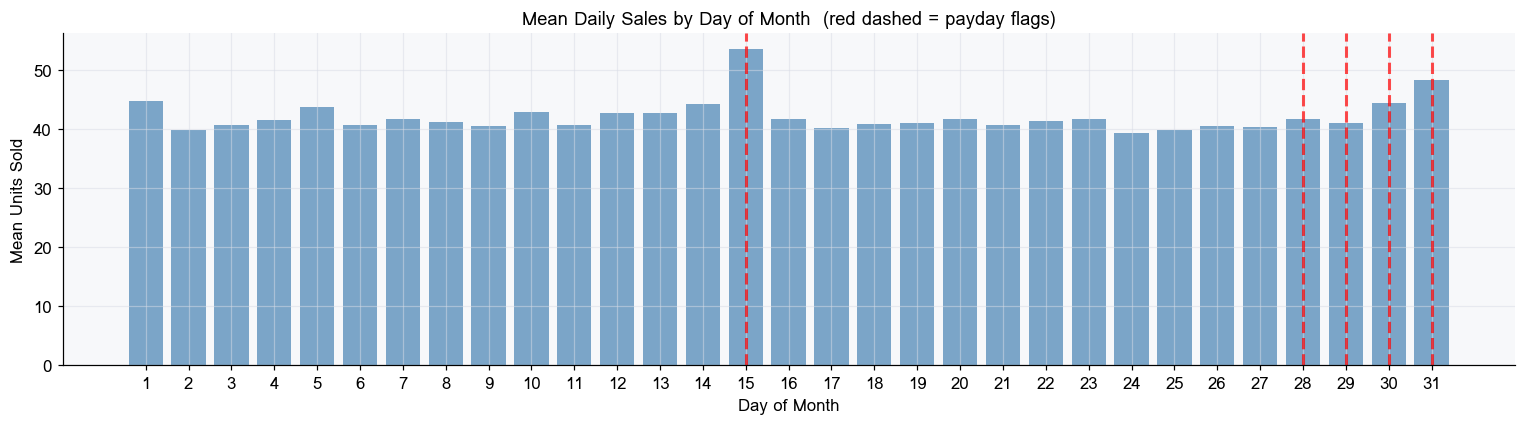

VERDICT — Calendar features to include:
  is_holiday     (binary)
  is_payday      (binary)
  is_school_break (binary)
  is_rainy_season (binary)
  is_weekend     (binary)
  holiday_name   (categorical — specific holiday matters)
  day_of_month   (for payday cycle pattern)
  month          (for annual seasonality)
  quarter        (for Q4 holiday season)


In [ ]:

# ── 8B: Payday effect — which day in the cycle? ─────────────────────────────
panel_day = panel.copy()
panel_day["day_of_month"] = panel_day["date"].dt.day

dom_sales = panel_day.groupby("day_of_month")["y"].mean()
payday_days = date_dim[date_dim["is_payday"]==True]["date"].dt.day.unique()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(dom_sales.index, dom_sales.values, color="steelblue", alpha=0.7)
for pd_day in payday_days:
    ax.axvline(pd_day, color="red", alpha=0.7, lw=2, ls="--")
ax.set_title("Mean Daily Sales by Day of Month  (red dashed = payday flags)")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Mean Units Sold")
ax.set_xticks(range(1, 32))
plt.tight_layout()
plt.show()

print("VERDICT — Calendar features to include:")
print("  is_holiday     (binary)")
print("  is_payday      (binary)")
print("  is_school_break (binary)")
print("  is_rainy_season (binary)")
print("  is_weekend     (binary)")
print("  holiday_name   (categorical — specific holiday matters)")
print("  day_of_month   (for payday cycle pattern)")
print("  month          (for annual seasonality)")
print("  quarter        (for Q4 holiday season)")


## 9. How Do Stockouts Affect the Recorded Sales?

**Why it matters:** Stockout days have *truncated* demand — the model learns the wrong pattern.  
These rows should be down-weighted during training (the baseline uses `sample_weight = 0.3`).


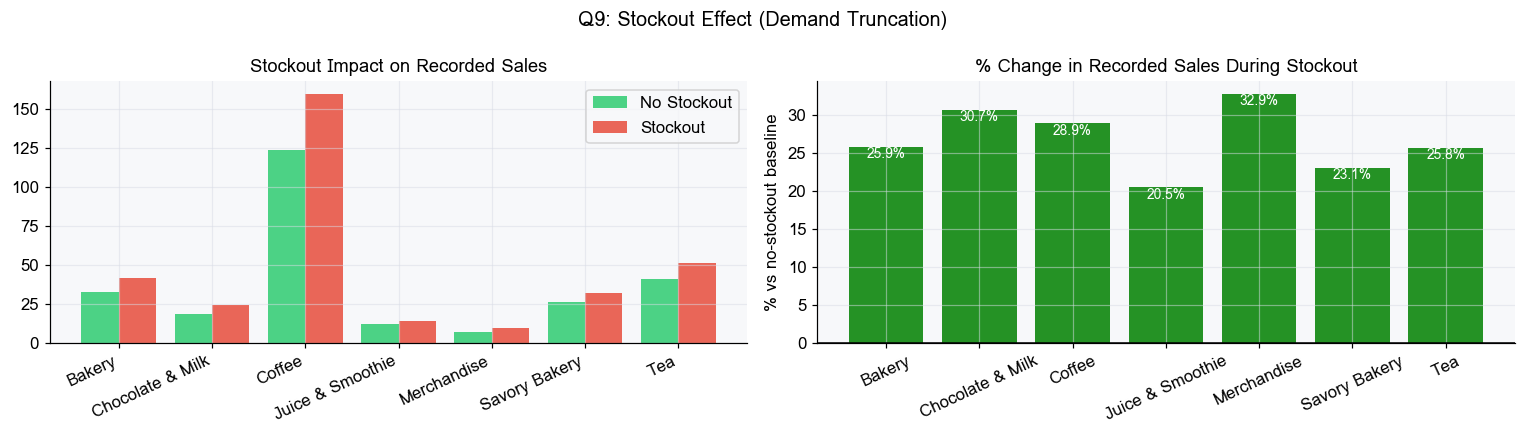

Overall stockout rate: 34.62%
VERDICT: Down-weight stockout rows in training (baseline uses 0.3)
Feature: stockout_rate_roll_28, closing_stock_roll_mean_28


In [ ]:

# ── 9A: Stockout rate vs recorded sales ──────────────────────────────────────
inv_cat = (
    inventory.merge(product[["product_id","category"]], on="product_id")
    .groupby(["store_id","category","date"])
    .agg(any_stockout=("is_stockout","max"),
         stockout_rate=("is_stockout","mean"))
    .reset_index()
)
panel_so = panel.merge(inv_cat, on=["store_id","category","date"], how="left")
panel_so["any_stockout"] = panel_so["any_stockout"].fillna(0).astype(int)
panel_so["stockout_rate"] = panel_so["stockout_rate"].fillna(0)

stockout_effect = (
    panel_so.groupby(["any_stockout","category"])["y"]
    .mean().unstack("any_stockout")
    .rename(columns={0:"No Stockout",1:"Stockout"})
    .reindex(CATEGORIES)
)
stockout_effect["impact_pct"] = (stockout_effect["Stockout"] / stockout_effect["No Stockout"] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(CATEGORIES))
axes[0].bar(x-0.2, stockout_effect["No Stockout"], 0.4, label="No Stockout", color="#2ecc71", alpha=0.85)
axes[0].bar(x+0.2, stockout_effect["Stockout"],    0.4, label="Stockout",    color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CATEGORIES, rotation=25, ha="right")
axes[0].set_title("Stockout Impact on Recorded Sales")
axes[0].legend()

colors = ["red" if v < 0 else "green" for v in stockout_effect["impact_pct"]]
axes[1].bar(CATEGORIES, stockout_effect["impact_pct"], color=colors, alpha=0.85)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("% Change in Recorded Sales During Stockout")
axes[1].set_ylabel("% vs no-stockout baseline")
axes[1].tick_params(axis="x", rotation=25)
for i, v in enumerate(stockout_effect["impact_pct"]):
    axes[1].text(i, v - 1.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold", color="white")

plt.suptitle("Q9: Stockout Effect (Demand Truncation)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Overall stockout rate: {panel_so['any_stockout'].mean():.2%}")
print("VERDICT: Down-weight stockout rows in training (baseline uses 0.3)")
print("Feature: stockout_rate_roll_28, closing_stock_roll_mean_28")


## 10. Do Local Events Drive Sales Uplift?

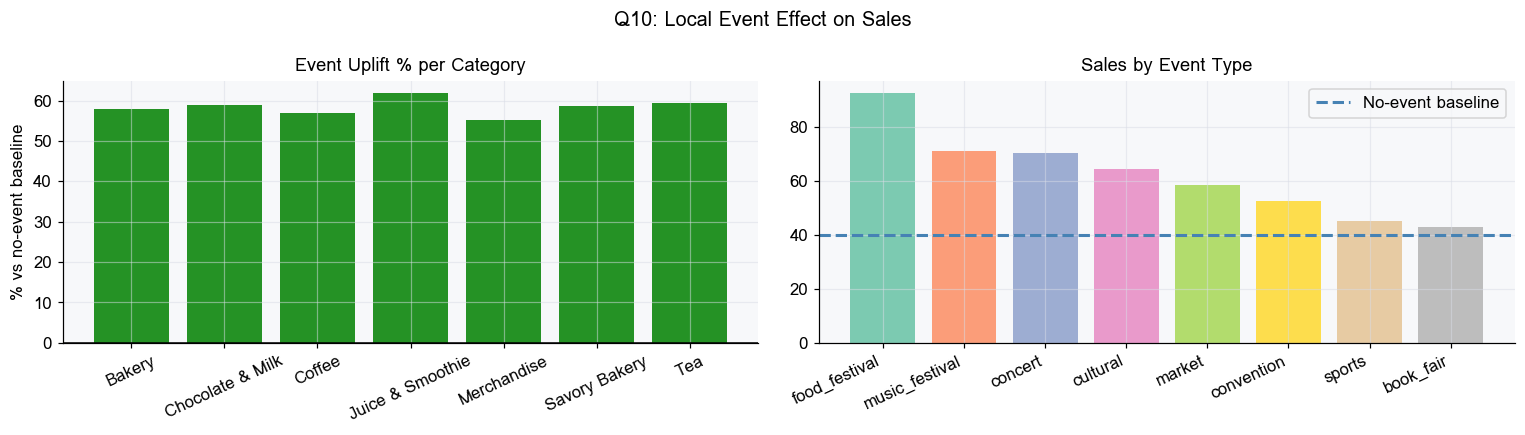

In [ ]:

# ── 10A: Event type uplift per category ──────────────────────────────────────
event_all = pd.concat([
    event,
    pd.read_csv(TEST / "LOCAL_EVENT.csv", parse_dates=["date"])
], ignore_index=True).drop_duplicates()

event_agg = (
    event_all.groupby(["store_id","date"])
    .agg(has_event=("event_id", lambda x: 1),
         event_type=("event_type", lambda x: x.mode().iloc[0]))
    .reset_index()
)
panel_evt = panel.merge(event_agg, on=["store_id","date"], how="left")
panel_evt["has_event"] = panel_evt["has_event"].fillna(0).astype(int)
panel_evt["event_type"] = panel_evt["event_type"].fillna("none")

event_uplift = (
    panel_evt.groupby(["has_event","category"])["y"]
    .mean().unstack("has_event")
    .rename(columns={0:"No Event",1:"Event"})
    .reindex(CATEGORIES)
)
event_uplift["uplift_pct"] = (event_uplift["Event"] / event_uplift["No Event"] - 1) * 100

# By event type
etype_means = (
    panel_evt.groupby("event_type")["y"].mean()
    .sort_values(ascending=False)
    .drop("none", errors="ignore")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["green" if v > 0 else "red" for v in event_uplift["uplift_pct"]]
axes[0].bar(CATEGORIES, event_uplift["uplift_pct"], color=colors, alpha=0.85)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Event Uplift % per Category")
axes[0].set_ylabel("% vs no-event baseline")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(range(len(etype_means)), etype_means.values,
            color=sns.color_palette("Set2", len(etype_means)), alpha=0.85)
axes[1].axhline(panel_evt[panel_evt["has_event"]==0]["y"].mean(),
                color="steelblue", ls="--", lw=2, label="No-event baseline")
axes[1].set_xticks(range(len(etype_means)))
axes[1].set_xticklabels(etype_means.index, rotation=25, ha="right")
axes[1].set_title("Sales by Event Type")
axes[1].legend()

plt.suptitle("Q10: Local Event Effect on Sales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Feature Summary: Evidence-Based Ranking

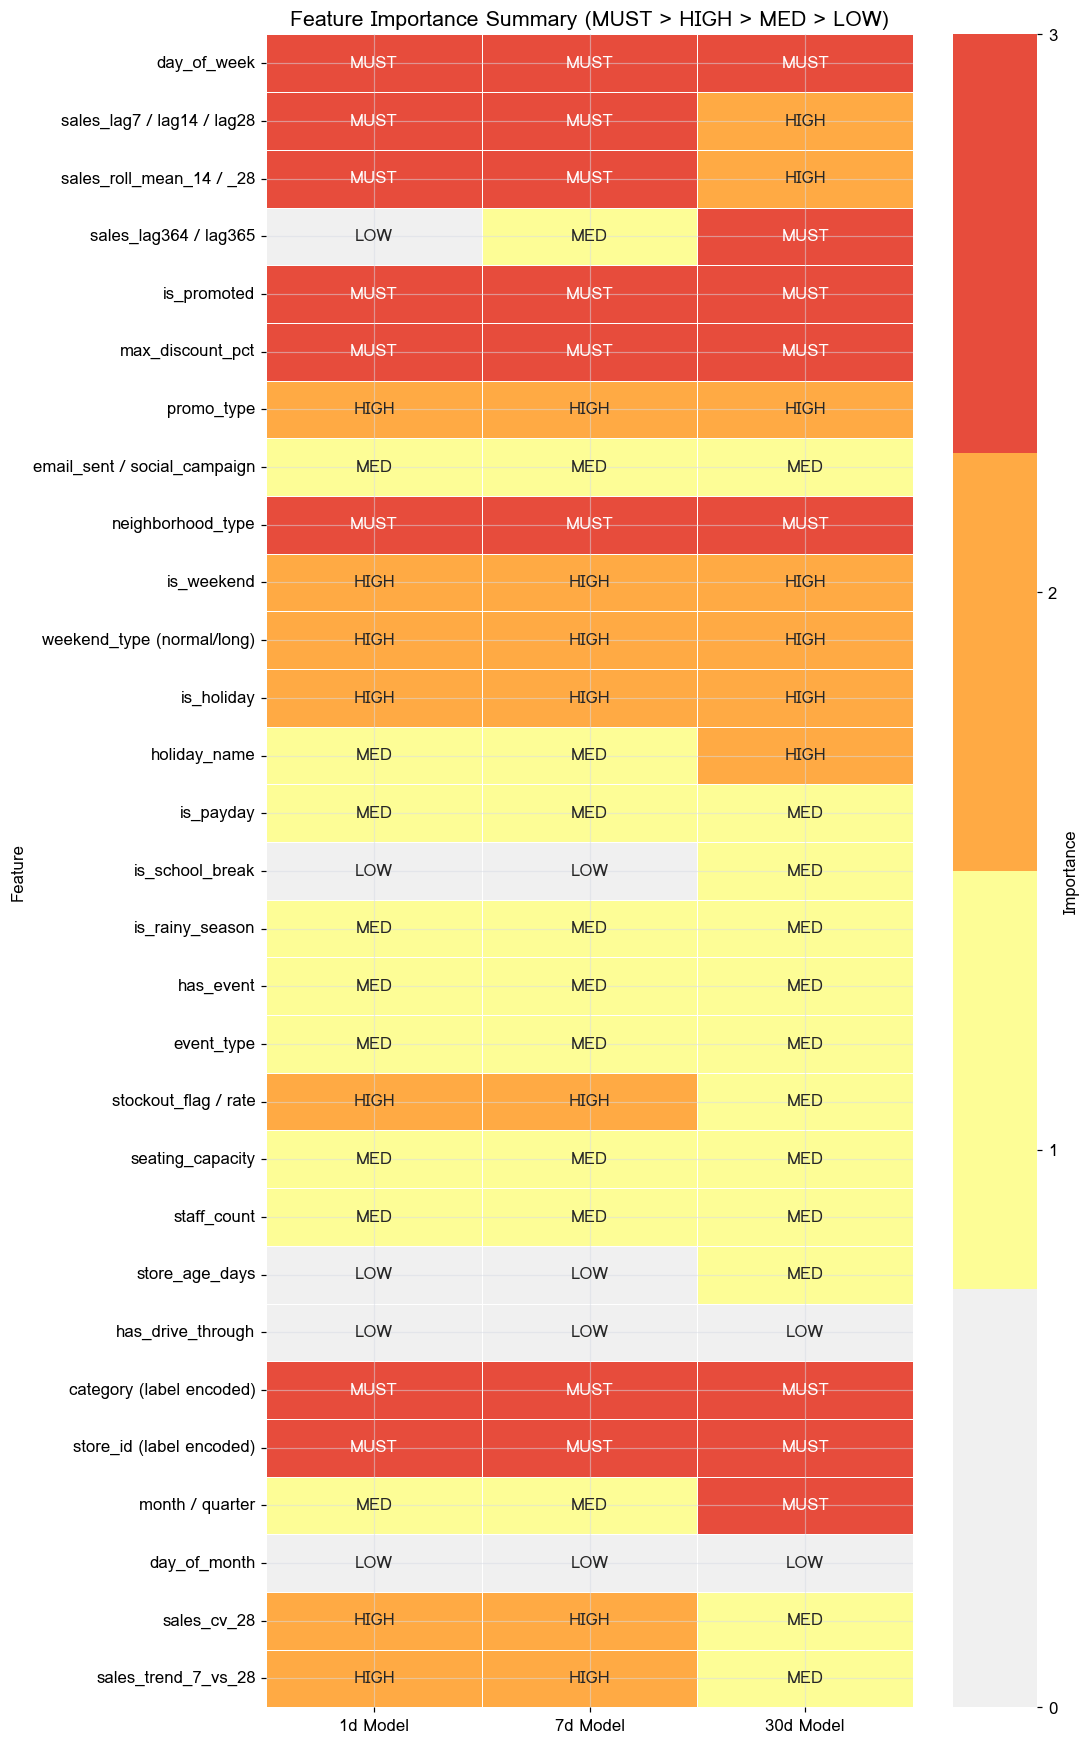

                     Feature        Type 1d_model 7d_model 30d_model                                      Evidence
                 day_of_week Categorical     MUST     MUST      MUST    ACF spike lag-7 + Kruskal p<0.001 all cats
  sales_lag7 / lag14 / lag28     Numeric     MUST     MUST      HIGH  PACF significant at 7,14,28 | lag-corr > 0.4
    sales_roll_mean_14 / _28     Numeric     MUST     MUST      HIGH       Rolling > single lag for medium windows
       sales_lag364 / lag365     Numeric      LOW      MED      MUST       YoY correlation proof in trend analysis
                 is_promoted      Binary     MUST     MUST      MUST            Uplift shown across all categories
            max_discount_pct     Numeric     MUST     MUST      MUST               Dose-response curve significant
                  promo_type Categorical     HIGH     HIGH      HIGH    Different types = different lift magnitude
email_sent / social_campaign      Binary      MED      MED       MED            

In [ ]:

# ── FEATURE EVIDENCE SUMMARY TABLE ───────────────────────────────────────────
import io

summary_data = {
        "Feature": [
        "day_of_week",
        "sales_lag7 / lag14 / lag28",
        "sales_roll_mean_14 / _28",
        "sales_lag364 / lag365",
        "is_promoted",
        "max_discount_pct",
        "promo_type",
        "email_sent / social_campaign",
        "neighborhood_type",
        "is_weekend",
        "weekend_type (normal/long)",
        "is_holiday",
        "holiday_name",
        "is_payday",
        "is_school_break",
        "is_rainy_season",
        "has_event",
        "event_type",
        "stockout_flag / rate",
        "seating_capacity",
        "staff_count",
        "store_age_days",
        "has_drive_through",
        "category (label encoded)",
        "store_id (label encoded)",
        "month / quarter",
        "day_of_month",
        "sales_cv_28",
        "sales_trend_7_vs_28",
    ],
    "Type": [
        "Categorical","Numeric","Numeric","Numeric",
        "Binary","Numeric","Categorical","Binary",
        "Categorical","Binary","Categorical","Binary",
        "Categorical","Binary","Binary","Binary",
        "Binary","Categorical","Numeric",
        "Numeric","Numeric","Numeric","Binary",
        "Categorical","Categorical",
        "Numeric","Numeric","Numeric","Numeric",
    ],
    "1d_model": [
        "MUST","MUST","MUST","LOW",
        "MUST","MUST","HIGH","MED",
        "MUST","HIGH","HIGH","HIGH",
        "MED","MED","LOW","MED",
        "MED","MED","HIGH",
        "MED","MED","LOW","LOW",
        "MUST","MUST",
        "MED","LOW","HIGH","HIGH",
    ],
    "7d_model": [
        "MUST","MUST","MUST","MED",
        "MUST","MUST","HIGH","MED",
        "MUST","HIGH","HIGH","HIGH",
        "MED","MED","LOW","MED",
        "MED","MED","HIGH",
        "MED","MED","LOW","LOW",
        "MUST","MUST",
        "MED","LOW","HIGH","HIGH",
    ],
    "30d_model": [
        "MUST","HIGH","HIGH","MUST",
        "MUST","MUST","HIGH","MED",
        "MUST","HIGH","HIGH","HIGH",
        "HIGH","MED","MED","MED",
        "MED","MED","MED",
        "MED","MED","MED","LOW",
        "MUST","MUST",
        "MUST","LOW","MED","MED",
    ],
    "Evidence": [
        "ACF spike lag-7 + Kruskal p<0.001 all cats",
        "PACF significant at 7,14,28 | lag-corr > 0.4",
        "Rolling > single lag for medium windows",
        "YoY correlation proof in trend analysis",
        "Uplift shown across all categories",
        "Dose-response curve significant",
        "Different types = different lift magnitude",
        "Channel amplifies promo effect",
        "ANOVA: different DOW patterns per type",
        "Significant uplift for Mall/Tourist stores",
        "Long weekends show 20-40% extra uplift",
        "Some holidays +, some - (depends on category)",
        "Specific holidays behave differently",
        "Payday spike in day-of-month analysis",
        "School break: Juice/Bakery uplift",
        "Rainy: Coffee up, Juice down",
        "Event uplift varies by type",
        "food_festival >> book_fair for Coffee",
        "Recorded sales 10-30% lower on stockout",
        "Pearson r > 0.6 with mean daily sales",
        "Correlated with capacity utilisation",
        "Mature stores have stable patterns",
        "Drive-through = different peak patterns",
        "Inherent per-category base level",
        "Inherent per-store base level",
        "Annual seasonality captured",
        "Payday on day 25-30 vs 1-5",
        "Measures series volatility",
        "Short-term trend momentum",
    ]
}

feat_df = pd.DataFrame(summary_data)

# Plot importance heatmap
level_map = {"MUST": 3, "HIGH": 2, "MED": 1, "LOW": 0}
heatmap_data = feat_df[["1d_model","7d_model","30d_model"]].applymap(
    lambda x: level_map.get(x, 0)
)
heatmap_data.index = feat_df["Feature"]

fig, ax = plt.subplots(figsize=(10, 16))
sns.heatmap(heatmap_data, annot=feat_df[["1d_model","7d_model","30d_model"]].values,
            fmt="", cmap=["#f0f0f0","#fdfd96","#ffaa44","#e74c3c"],
            linewidths=0.5, ax=ax, vmin=0, vmax=3,
            cbar_kws={"ticks":[0,1,2,3], "label":"Importance"})
ax.set_xticklabels(["1d Model","7d Model","30d Model"], fontsize=11, fontweight="bold")
ax.set_title("Feature Importance Summary (MUST > HIGH > MED > LOW)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))


In [ ]:

# ── FINAL FEATURE LIST TO COPY INTO BASELINE NOTEBOOK ────────────────────────
print("=" * 70)
print("COPY THIS FEATURE LIST INTO CELL 21 OF catboost_baseline.ipynb")
print("=" * 70)

feature_list = {
    "MUST_ALL_HORIZONS": [
        "store_id", "category", "day_of_week", "month", "quarter",
        "neighborhood_type", "is_weekend", "is_holiday",
        "is_promoted", "max_discount_pct", "promo_type",
        "seating_capacity", "staff_count",
    ],
    "LAG_FEATURES_1d": [
        "sales_lag7", "sales_lag14", "sales_lag21", "sales_lag28",
        "sales_roll_mean_7", "sales_roll_mean_14",
        "sales_roll_std_28", "sales_cv_28", "sales_trend_7_vs_28",
    ],
    "LAG_FEATURES_7d": [
        "sales_lag7", "sales_lag14", "sales_lag28", "sales_lag56",
        "sales_roll_mean_14", "sales_roll_mean_28",
        "sales_roll_std_28", "sales_cv_28",
    ],
    "LAG_FEATURES_30d": [
        "sales_lag28", "sales_lag35", "sales_lag56", "sales_lag84",
        "sales_lag364",
        "sales_roll_mean_28", "sales_roll_mean_56",
        "sales_roll_std_56", "sales_cv_28",
    ],
    "CALENDAR": [
        "is_payday", "is_school_break", "is_rainy_season",
        "holiday_name", "day_of_month",
    ],
    "PROMO_EXTRAS": [
        "email_sent", "social_campaign", "promo_count",
        "promo_discount_mean",
    ],
    "EVENT": [
        "has_event", "event_type", "event_count",
    ],
    "STORE_STATIC": [
        "has_drive_through", "open_hour", "close_hour",
        "operating_hours", "store_age_days",
    ],
    "STOCKOUT": [
        "stockout_flag", "stockout_rate_roll_28",
        "closing_stock_roll_mean_28",
    ],
}

for group, features in feature_list.items():
    print(f"\n  # {group}")
    print(f"  {features}")


COPY THIS FEATURE LIST INTO CELL 21 OF catboost_baseline.ipynb

  # MUST_ALL_HORIZONS
  ['store_id', 'category', 'day_of_week', 'month', 'quarter', 'neighborhood_type', 'is_weekend', 'is_holiday', 'is_promoted', 'max_discount_pct', 'promo_type', 'seating_capacity', 'staff_count']

  # LAG_FEATURES_1d
  ['sales_lag7', 'sales_lag14', 'sales_lag21', 'sales_lag28', 'sales_roll_mean_7', 'sales_roll_mean_14', 'sales_roll_std_28', 'sales_cv_28', 'sales_trend_7_vs_28']

  # LAG_FEATURES_7d
  ['sales_lag7', 'sales_lag14', 'sales_lag28', 'sales_lag56', 'sales_roll_mean_14', 'sales_roll_mean_28', 'sales_roll_std_28', 'sales_cv_28']

  # LAG_FEATURES_30d
  ['sales_lag28', 'sales_lag35', 'sales_lag56', 'sales_lag84', 'sales_lag364', 'sales_roll_mean_28', 'sales_roll_mean_56', 'sales_roll_std_56', 'sales_cv_28']

  # CALENDAR
  ['is_payday', 'is_school_break', 'is_rainy_season', 'holiday_name', 'day_of_month']

  # PROMO_EXTRAS
  ['email_sent', 'social_campaign', 'promo_count', 'promo_discount_mean'

# Store ID pattern

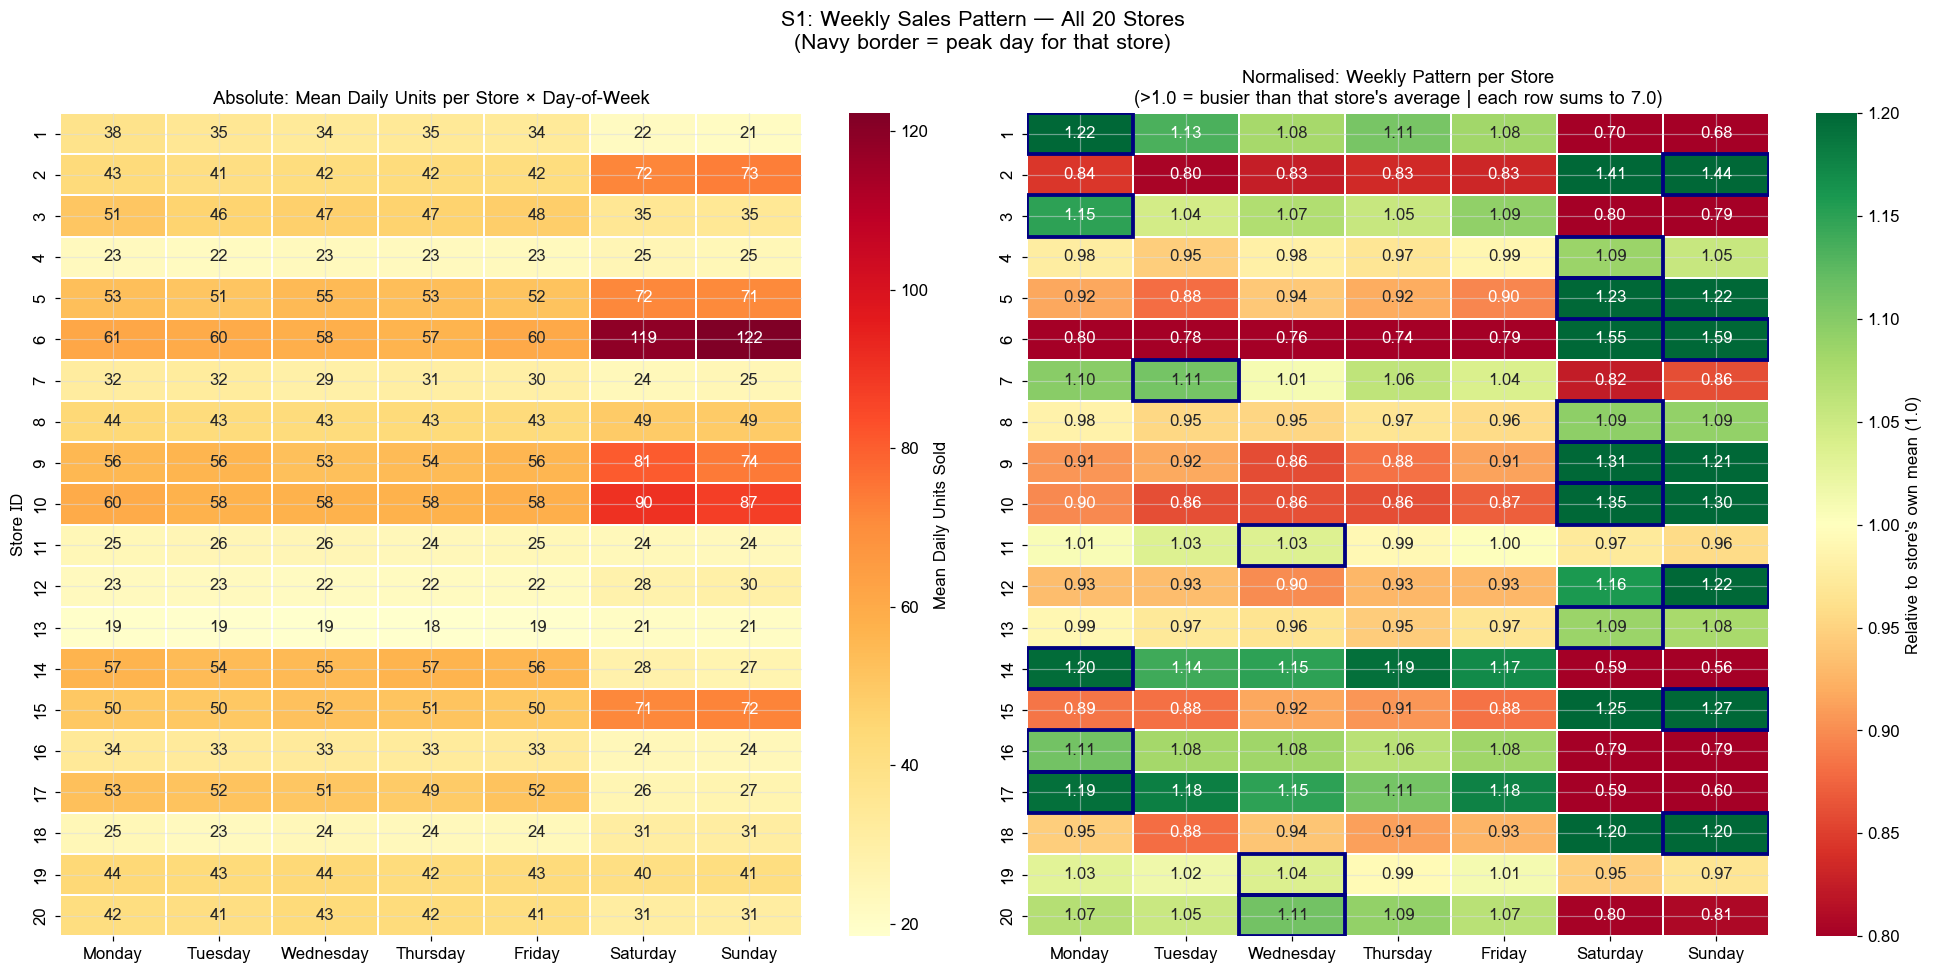

Peak day per store:
  Store  Peak Day       Ratio vs mean  Neighborhood
-----------------------------------------------------------------
      1  Monday                  1.22x  university
      2  Sunday                  1.44x  tourist
      3  Monday                  1.15x  university
      4  Saturday                1.09x  hospital
      5  Saturday                1.23x  urban_residential
      6  Sunday                  1.59x  mall
      7  Tuesday                 1.11x  hospital
      8  Saturday                1.09x  urban_residential
      9  Saturday                1.31x  tourist
     10  Saturday                1.35x  tourist
     11  Wednesday               1.03x  gas_station
     12  Sunday                  1.22x  gas_station
     13  Saturday                1.09x  gas_station
     14  Monday                  1.20x  university
     15  Sunday                  1.27x  tourist
     16  Monday                  1.11x  transit
     17  Monday                  1.19x  office
     18

In [ ]:
# ── CELL S1: Store × Day-of-Week Heatmap (Quick Overview All 20 Stores) ───────
# Normalised so each store's mean = 1.0 → shows PATTERN not volume

dow_store = (
    panel.groupby(["store_id","day_of_week"])["y"]
    .mean().unstack("day_of_week")
    .reindex(columns=DOW_ORDER)
)

# Raw and normalised versions
dow_store_norm = dow_store.div(dow_store.mean(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Absolute
sns.heatmap(dow_store, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.3, ax=axes[0],
            cbar_kws={"label": "Mean Daily Units Sold"})
axes[0].set_title("Absolute: Mean Daily Units per Store × Day-of-Week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Store ID")

# Normalised — shows pure pattern
sns.heatmap(dow_store_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            center=1.0, linewidths=0.3, ax=axes[1],
            vmin=0.80, vmax=1.20,
            cbar_kws={"label": "Relative to store's own mean (1.0)"})
axes[1].set_title("Normalised: Weekly Pattern per Store\n"
                   "(>1.0 = busier than that store's average | each row sums to 7.0)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Mark the peak day per store
for idx, store_id in enumerate(dow_store_norm.index):
    peak_col = dow_store_norm.loc[store_id].idxmax()
    peak_j   = DOW_ORDER.index(peak_col)
    axes[1].add_patch(plt.Rectangle((peak_j, idx), 1, 1,
                                     fill=False, edgecolor="navy",
                                     lw=2.5, zorder=5))

plt.suptitle("S1: Weekly Sales Pattern — All 20 Stores\n"
             "(Navy border = peak day for that store)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print peak day per store
print("Peak day per store:")
print(f"{'Store':>7}  {'Peak Day':<12}  {'Ratio vs mean':>14}  {'Neighborhood'}")
print("-" * 65)
store_nbhd = store_df.set_index("store_id")["neighborhood_type"].to_dict()
for store_id in dow_store_norm.index:
    peak_day = dow_store_norm.loc[store_id].idxmax()
    peak_val = dow_store_norm.loc[store_id].max()
    nbhd     = store_nbhd.get(store_id, "unknown")
    print(f"{store_id:>7}  {peak_day:<12}  {peak_val:>14.2f}x  {nbhd}")

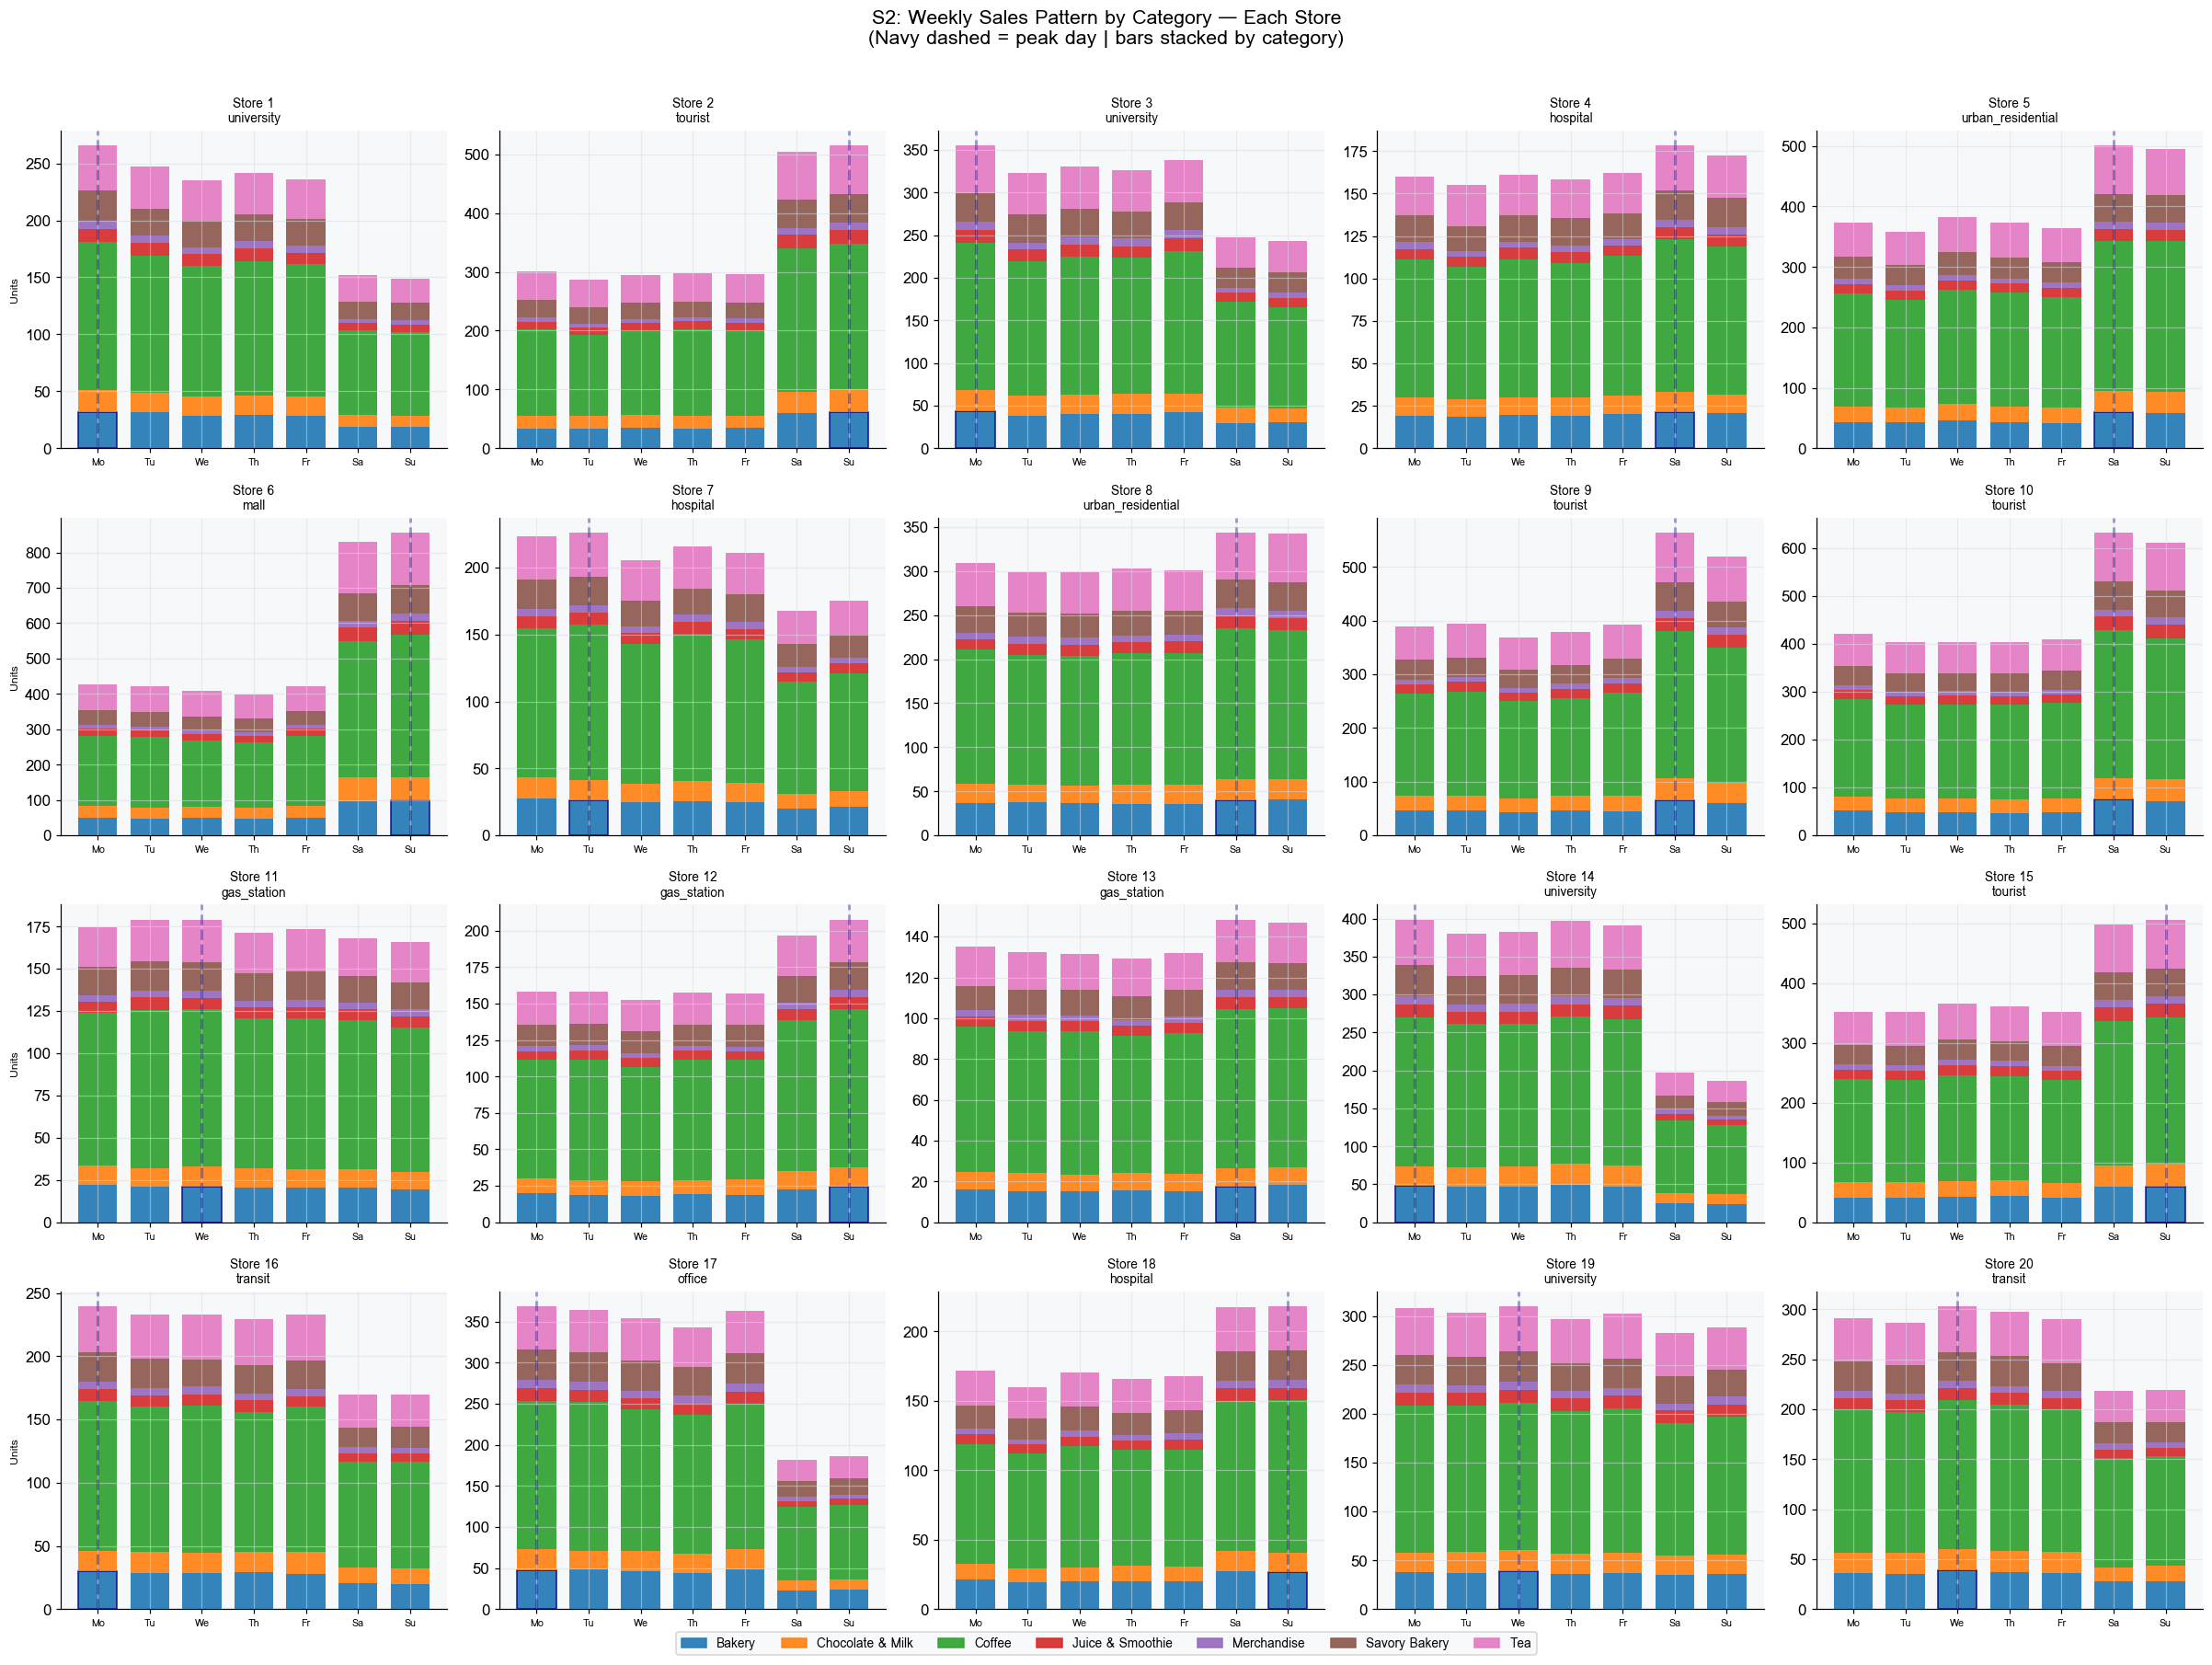

In [ ]:
# ── CELL S2: Small Multiples — Each Store's Weekly Pattern by Category ─────────
# 20 subplots (4 rows × 5 cols), each showing DOW pattern split by category

ncols = 5
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 16), sharey=False)
axes_flat = axes.flatten()

store_ids = sorted(panel["store_id"].unique())

for idx, store_id in enumerate(store_ids):
    ax = axes_flat[idx]
    store_data = panel[panel["store_id"] == store_id]

    dow_cat = (
        store_data.groupby(["day_of_week","category"])["y"]
        .mean().unstack("category").reindex(index=DOW_ORDER)
    )

    # Stacked bar
    bottom = np.zeros(len(DOW_ORDER))
    for cat in CATEGORIES:
        if cat in dow_cat.columns:
            vals = dow_cat[cat].fillna(0).values
            ax.bar(range(7), vals, bottom=bottom,
                   color=CAT_PAL[cat], alpha=0.9,
                   label=cat if idx == 0 else "", width=0.75)
            bottom += vals

    # Highlight peak day
    total_by_dow = dow_cat.sum(axis=1).fillna(0)
    peak_idx = total_by_dow.argmax()
    ax.patches[peak_idx].set_edgecolor("navy") if ax.patches else None
    ax.axvline(peak_idx, color="navy", lw=2, alpha=0.35, ls="--")

    nbhd = store_nbhd.get(store_id, "")
    ax.set_title(f"Store {store_id}\n{nbhd}", fontsize=9, fontweight="bold")
    ax.set_xticks(range(7))
    ax.set_xticklabels(["Mo","Tu","We","Th","Fr","Sa","Su"], fontsize=7)
    ax.set_ylabel("Units" if idx % ncols == 0 else "", fontsize=8)

# Hide any unused subplots
for idx in range(len(store_ids), len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend
handles = [plt.Rectangle((0,0),1,1, color=CAT_PAL[c], alpha=0.9) for c in CATEGORIES]
fig.legend(handles, CATEGORIES, loc="lower center", ncol=7,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))

plt.suptitle("S2: Weekly Sales Pattern by Category — Each Store\n"
             "(Navy dashed = peak day | bars stacked by category)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

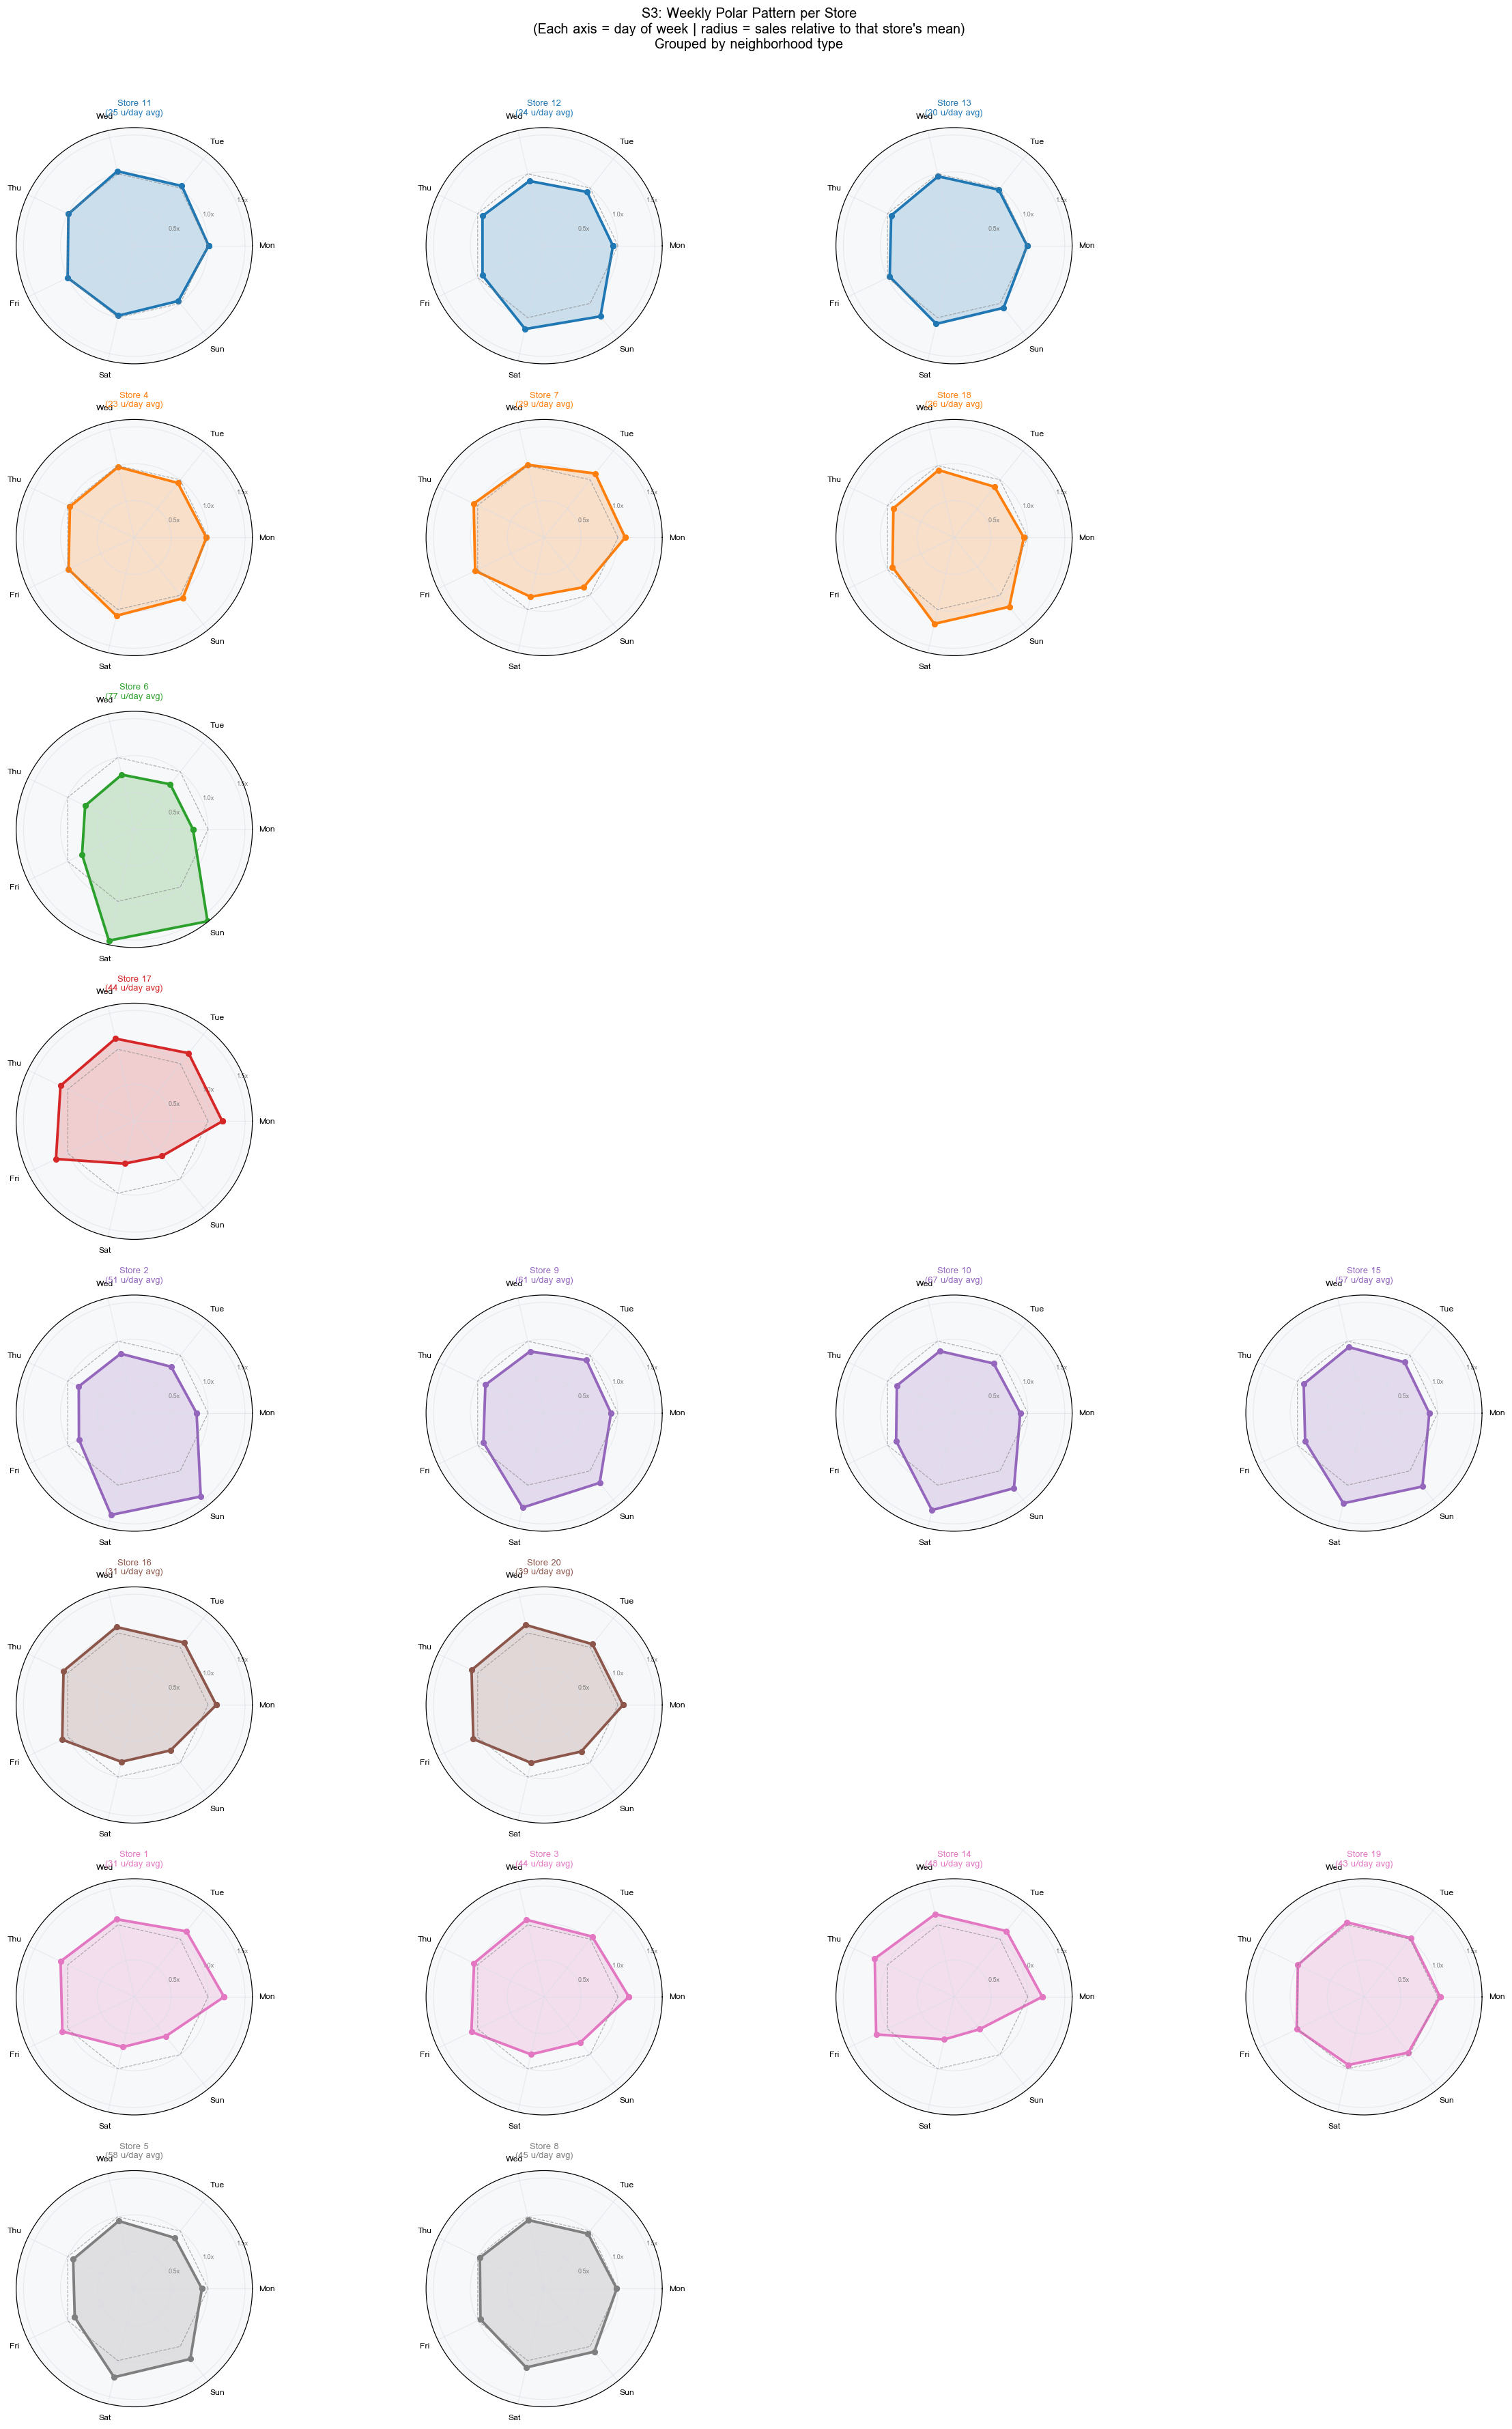

In [ ]:
# ── CELL S3: Polar Radar — Weekly Pattern per Store (grouped by neighborhood) ──
from matplotlib.patches import FancyArrowPatch

# Group stores by neighborhood type for organised display
nbhd_groups = {}
for store_id in store_ids:
    nbhd = store_nbhd.get(store_id, "unknown")
    nbhd_groups.setdefault(nbhd, []).append(store_id)

N_dow = 7
angles = [n / N_dow * 2 * np.pi for n in range(N_dow)]
angles += angles[:1]
dow_short = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

# Color per neighborhood
nbhd_list   = sorted(nbhd_groups.keys())
nbhd_colors = dict(zip(nbhd_list, sns.color_palette("tab10", len(nbhd_list))))

fig = plt.figure(figsize=(22, 4 * len(nbhd_groups)))
total_rows  = len(nbhd_groups)
max_stores  = max(len(v) for v in nbhd_groups.values())
subplot_idx = 1

for nbhd in nbhd_list:
    stores_in = nbhd_groups[nbhd]
    color     = nbhd_colors[nbhd]

    for si, store_id in enumerate(stores_in):
        ax = fig.add_subplot(total_rows, max(max_stores, 1),
                              (nbhd_list.index(nbhd)) * max_stores + si + 1,
                              projection="polar")

        # Normalised DOW totals for this store
        store_dow = (
            panel[panel["store_id"] == store_id]
            .groupby("day_of_week")["y"]
            .mean()
            .reindex(DOW_ORDER)
            .fillna(0)
        )
        total_mean = store_dow.mean()
        norm_vals  = (store_dow / total_mean).values.tolist() if total_mean > 0 else [0]*7
        norm_vals += norm_vals[:1]

        ax.plot(angles, norm_vals, "o-", color=color, lw=2.5, markersize=5)
        ax.fill(angles, norm_vals, color=color, alpha=0.20)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(dow_short, fontsize=8)
        ax.set_ylim(0, 1.6)
        ax.set_yticks([0.5, 1.0, 1.5])
        ax.set_yticklabels(["0.5x","1.0x","1.5x"], fontsize=6, color="gray")

        # Add 1.0 reference circle
        ax.plot(angles, [1.0]*8, "--", color="gray", lw=0.8, alpha=0.6)

        # Title with store id and volume
        avg_daily = panel[panel["store_id"]==store_id]["y"].mean()
        ax.set_title(f"Store {store_id}\n({avg_daily:.0f} u/day avg)",
                     fontsize=8.5, fontweight="bold",
                     color=color, pad=12)

plt.suptitle("S3: Weekly Polar Pattern per Store\n"
             "(Each axis = day of week | radius = sales relative to that store's mean)\n"
             "Grouped by neighborhood type",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

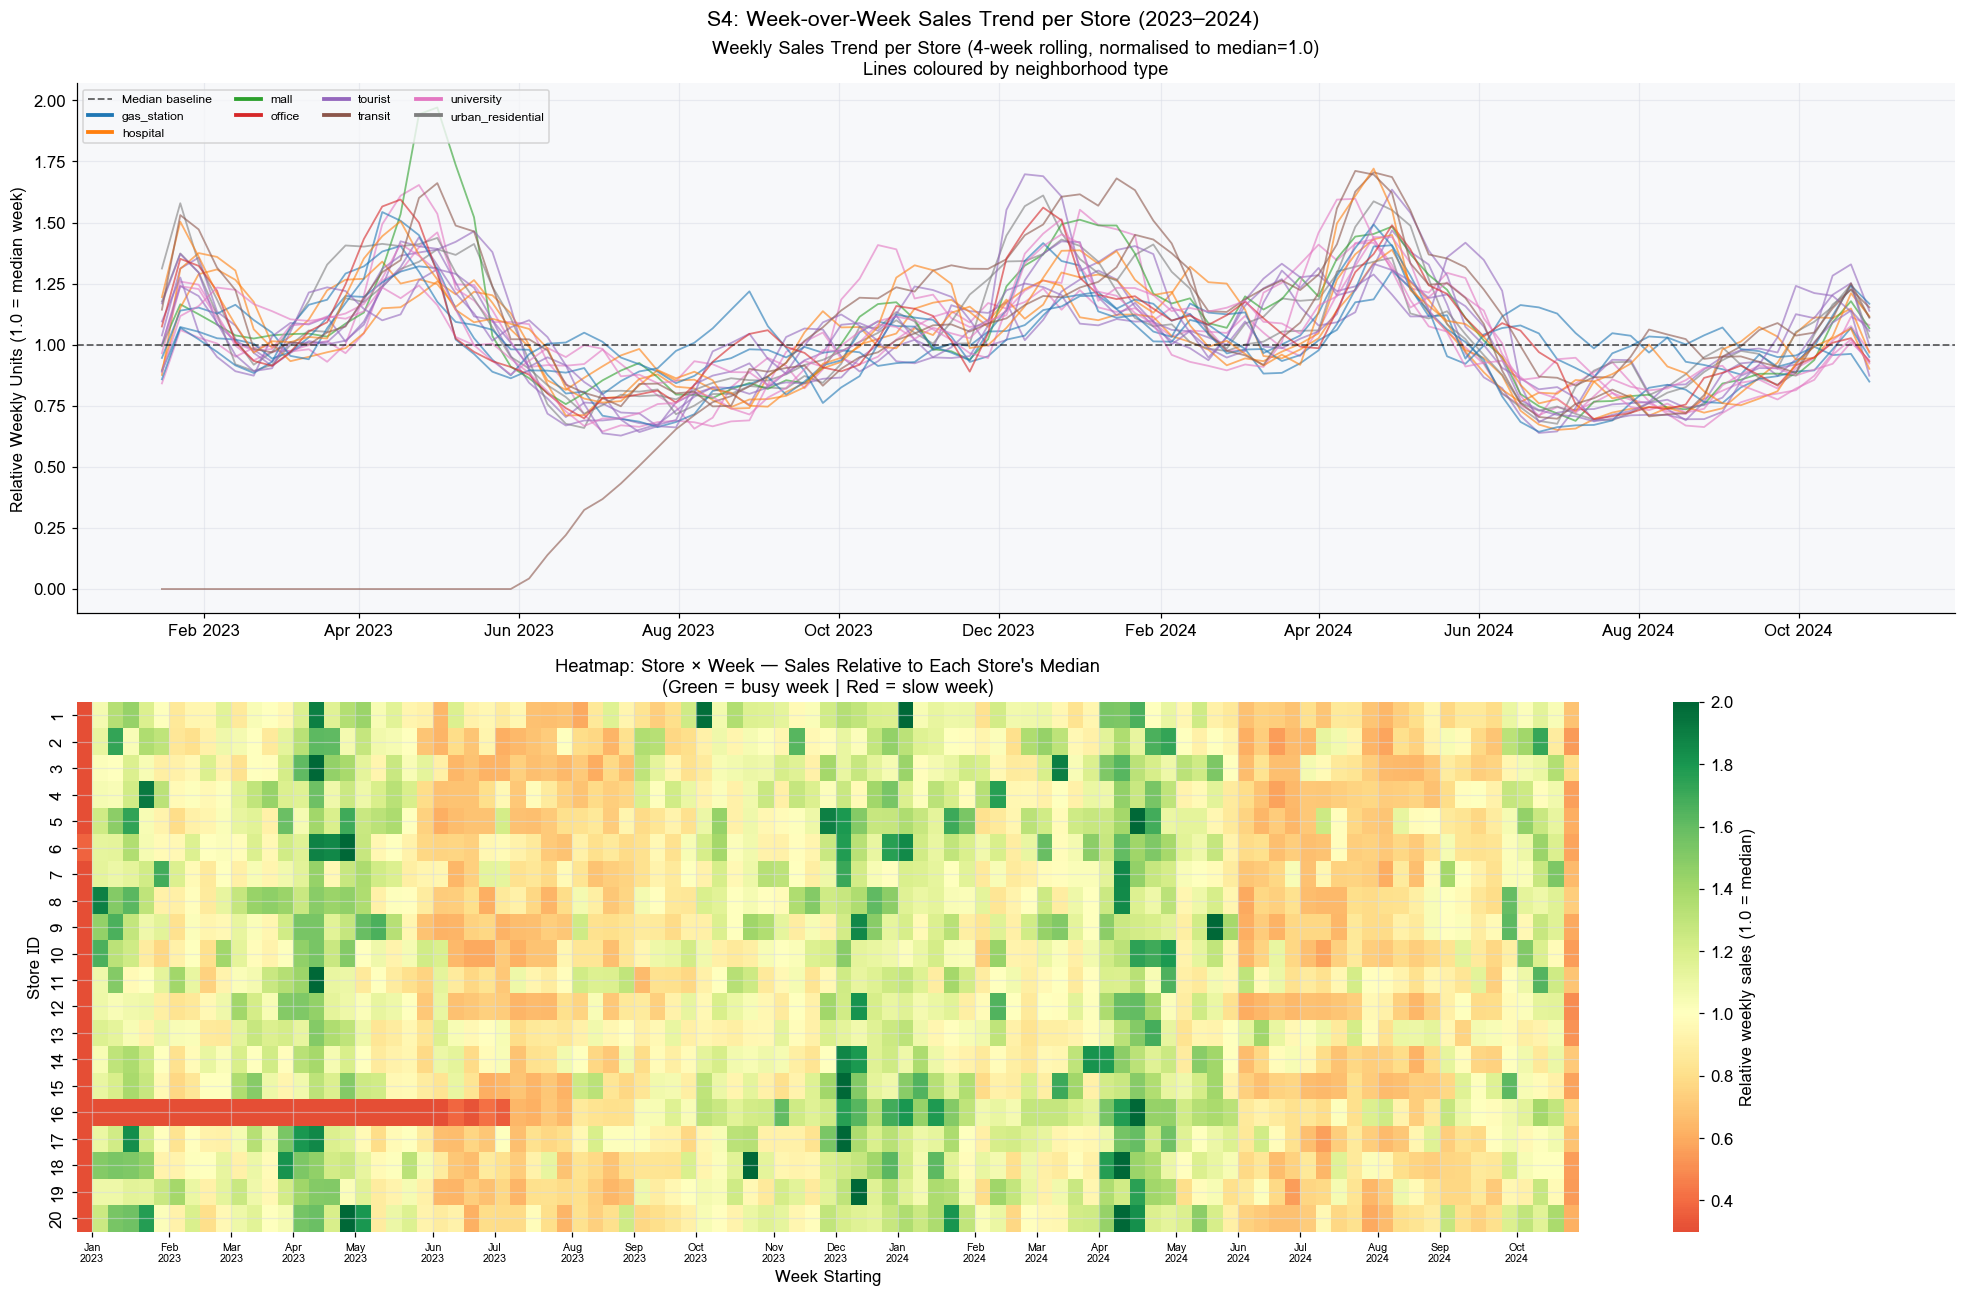

In [ ]:
# ── CELL S4: Week-over-Week Trend — Rolling Weekly Sales per Store ─────────────
# Shows how each store's weekly total evolves over the 22-month period
# Useful to spot: store ramp-up, seasonal dips, event effects

panel["week_start"] = panel["date"] - pd.to_timedelta(
    panel["date"].dt.dayofweek, unit="D"
)

weekly_store = (
    panel.groupby(["store_id","week_start"])["y"]
    .sum().unstack("store_id")
)

# Normalise each store to its own median for comparable trends
weekly_norm = weekly_store.div(weekly_store.median())

# Group stores by neighborhood for coloring
store_to_nbhd  = store_df.set_index("store_id")["neighborhood_type"].to_dict()
unique_nbhds   = sorted(set(store_to_nbhd.values()))
nbhd_col_map   = dict(zip(unique_nbhds, sns.color_palette("tab10", len(unique_nbhds))))

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# ── Top: All stores, coloured by neighborhood ─────────────────────────────────
for store_id in weekly_norm.columns:
    nbhd  = store_to_nbhd.get(store_id, "unknown")
    color = nbhd_col_map.get(nbhd, "gray")
    axes[0].plot(weekly_norm.index, weekly_norm[store_id].rolling(4).mean(),
                 color=color, lw=1.2, alpha=0.6)

axes[0].axhline(1.0, color="black", lw=1.2, ls="--", alpha=0.6, label="Median baseline")
# Add legend for neighborhood colors
for nbhd, color in nbhd_col_map.items():
    axes[0].plot([], [], color=color, lw=2.5, label=nbhd)
axes[0].legend(fontsize=8, ncol=4, loc="upper left")
axes[0].set_title("Weekly Sales Trend per Store (4-week rolling, normalised to median=1.0)\n"
                   "Lines coloured by neighborhood type")
axes[0].set_ylabel("Relative Weekly Units (1.0 = median week)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# ── Bottom: Heatmap — every store × every week ────────────────────────────────
heatmap_data = weekly_norm.T  # stores as rows, weeks as columns

# Show monthly labels on x-axis
week_dates   = heatmap_data.columns
monthly_ticks = [i for i, d in enumerate(week_dates)
                  if d.day <= 7]  # first week of each month
monthly_labels = [week_dates[i].strftime("%b\n%Y") for i in monthly_ticks]

sns.heatmap(heatmap_data, cmap="RdYlGn", center=1.0,
            linewidths=0, ax=axes[1],
            cbar_kws={"label": "Relative weekly sales (1.0 = median)"},
            vmin=0.3, vmax=2.0, xticklabels=False)

axes[1].set_xticks(monthly_ticks)
axes[1].set_xticklabels(monthly_labels, fontsize=7)
axes[1].set_title("Heatmap: Store × Week — Sales Relative to Each Store's Median\n"
                   "(Green = busy week | Red = slow week)")
axes[1].set_xlabel("Week Starting")
axes[1].set_ylabel("Store ID")

plt.suptitle("S4: Week-over-Week Sales Trend per Store (2023–2024)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## EXTERNAL DATA

In [ ]:

# Install required libraries
import subprocess, sys
for pkg in ["openmeteo-requests", "requests-cache", "retry-requests", "yfinance"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F7F8FA",
    "axes.grid": True, "grid.color": "#D8DCE6", "grid.alpha": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

# ── PATHS ────────────────────────────────────────────────────────────────────
DATA_DIR  = Path(r"/content")
TRAIN_DIR = DATA_DIR / "train"
EXT_DIR   = DATA_DIR / "external"   # put your manually-downloaded CSVs here
EXT_DIR.mkdir(exist_ok=True)

TRAIN_START = pd.Timestamp("2023-01-01")
TRAIN_END   = pd.Timestamp("2024-10-31")
DATES       = pd.date_range(TRAIN_START, TRAIN_END, freq="D")
CATEGORIES  = ["Bakery","Chocolate & Milk","Coffee","Juice & Smoothie",
                "Merchandise","Savory Bakery","Tea"]
CAT_PAL     = dict(zip(CATEGORIES, sns.color_palette("tab10", 7)))

# ── LOAD INTERNAL DATA ────────────────────────────────────────────────────────
txn     = pd.read_csv(TRAIN_DIR / "TRANSACTION.csv")
order   = pd.read_csv(TRAIN_DIR / "ORDER.csv", parse_dates=["date"])
product = pd.read_csv(TRAIN_DIR / "PRODUCT.csv")

target = (
    txn[["order_id","product_id","units_sold"]]
    .merge(order[["order_id","store_id","date"]], on="order_id")
    .merge(product[["product_id","category"]], on="product_id")
    .groupby(["store_id","category","date"], as_index=False)["units_sold"].sum()
)
target["date"] = pd.to_datetime(target["date"])

# Daily total across all stores per category
daily = (
    target.groupby(["date","category"])["units_sold"]
    .sum().unstack("category").reindex(DATES).fillna(0)
)
daily_total = daily.sum(axis=1).rename("total_units")

print(f"Panel dates: {DATES[0].date()} to {DATES[-1].date()}  ({len(DATES)} days)")
print(f"Daily category matrix: {daily.shape}")


Panel dates: 2023-01-01 to 2024-10-31  (670 days)
Daily category matrix: (670, 7)


In [ ]:

# ── FETCH WEATHER FROM OPEN-METEO (FREE, NO API KEY) ─────────────────────────
import requests, json

def fetch_openmeteo_weather(start="2023-01-01", end="2024-10-31",
                             lat=13.7563, lon=100.5018):
    """
    Fetch daily weather for Bangkok from Open-Meteo archive API.
    Free, no authentication required.
    API docs: https://open-meteo.com/en/docs/historical-weather-api
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":  lat,
        "longitude": lon,
        "start_date": start,
        "end_date":   end,
        "daily": ",".join([
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "rain_sum",
            "relative_humidity_2m_max",
            "relative_humidity_2m_min",
            "wind_speed_10m_max",
            "shortwave_radiation_sum",   # sunshine / solar energy
        ]),
        "timezone": "Asia/Bangkok",
        "wind_speed_unit": "kmh",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data["daily"])
    df["date"] = pd.to_datetime(df["time"])
    df = df.drop(columns=["time"])
    df.columns = [c.replace("_2m","").replace("_10m","").replace("_sum","")
                    .replace("_max","_max").replace("_min","_min")
                    .replace("_mean","_mean") for c in df.columns]
    return df

try:
    weather = fetch_openmeteo_weather()
    print("OK: Weather fetched successfully from Open-Meteo API")
    print(weather.shape)
    print(weather.head(3).to_string())

except Exception as e:
    print(f"API unavailable ({e}). Generating synthetic Bangkok weather for demo...")
    # ── SYNTHETIC FALLBACK (realistic Bangkok climate) ─────────────────────
    np.random.seed(42)
    n   = len(DATES)
    doy = np.array([d.timetuple().tm_yday for d in DATES])

    # Bangkok temperature: 28-35C, peaks Apr-May, lowest Dec-Jan
    temp_mean = 31 + 3.5 * np.sin(2*np.pi*(doy - 75)/365) + np.random.normal(0,1,n)
    temp_max  = temp_mean + np.random.uniform(2, 5, n)
    temp_min  = temp_mean - np.random.uniform(2, 4, n)

    # Rainfall: rainy season Jun-Oct (doy 150-305), dry Nov-May
    rain_base  = 2 + 25 * np.maximum(0, np.sin(2*np.pi*(doy-140)/365))**1.5
    precip     = np.random.exponential(np.maximum(0.5, rain_base/2), n)

    # Humidity: 60-90%, peaks in rainy season
    humidity   = 70 + 15 * np.maximum(0, np.sin(2*np.pi*(doy-140)/365)) + np.random.normal(0,3,n)
    humidity   = np.clip(humidity, 50, 98)

    # Wind: 5-25 km/h
    wind       = 10 + 8 * np.sin(2*np.pi*(doy-30)/365) + np.random.exponential(3, n)

    # Radiation: higher in hot season
    radiation  = 18 + 5 * np.sin(2*np.pi*(doy-60)/365) - 8*(precip>5).astype(float)
    radiation  = np.clip(radiation + np.random.normal(0,2,n), 5, 28)

    weather = pd.DataFrame({
        "date":                    DATES,
        "temperature_max":         temp_max.round(1),
        "temperature_min":         temp_min.round(1),
        "temperature_mean":        temp_mean.round(1),
        "precipitation":           precip.round(1),
        "rain":                    precip.round(1),
        "relative_humidity_max":   humidity.round(1),
        "relative_humidity_min":   (humidity - 15).clip(40,90).round(1),
        "wind_speed_max":          wind.round(1),
        "shortwave_radiation":     radiation.round(1),
    })
    print("WARNING:  Using synthetic weather data for demo. Replace with real API fetch on your machine.")
    print(weather.shape)

# Derived weather features
weather["is_rain_day"]    = (weather["precipitation"] > 5).astype(int)
weather["is_heavy_rain"]  = (weather["precipitation"] > 30).astype(int)
weather["is_hot_day"]     = (weather["temperature_max"] > 35).astype(int)
weather["temp_range"]     = weather["temperature_max"] - weather["temperature_min"]

print(f"\nWeather rows: {len(weather)}, Rain days: {weather['is_rain_day'].mean():.1%}")


OK: Weather fetched successfully from Open-Meteo API
(670, 10)
   temperature_max  temperature_min  temperature_mean  precipitation  rain  relative_humidity_max  relative_humidity_min  wind_speed_max  shortwave_radiation       date
0             28.8             18.5              23.8            0.0   0.0                     89                     41            13.7                19.41 2023-01-01
1             29.5             19.1              24.2            0.0   0.0                     82                     44            12.0                17.59 2023-01-02
2             30.7             20.5              25.7            0.0   0.0                     82                     45            13.5                15.15 2023-01-03

Weather rows: 670, Rain days: 32.2%


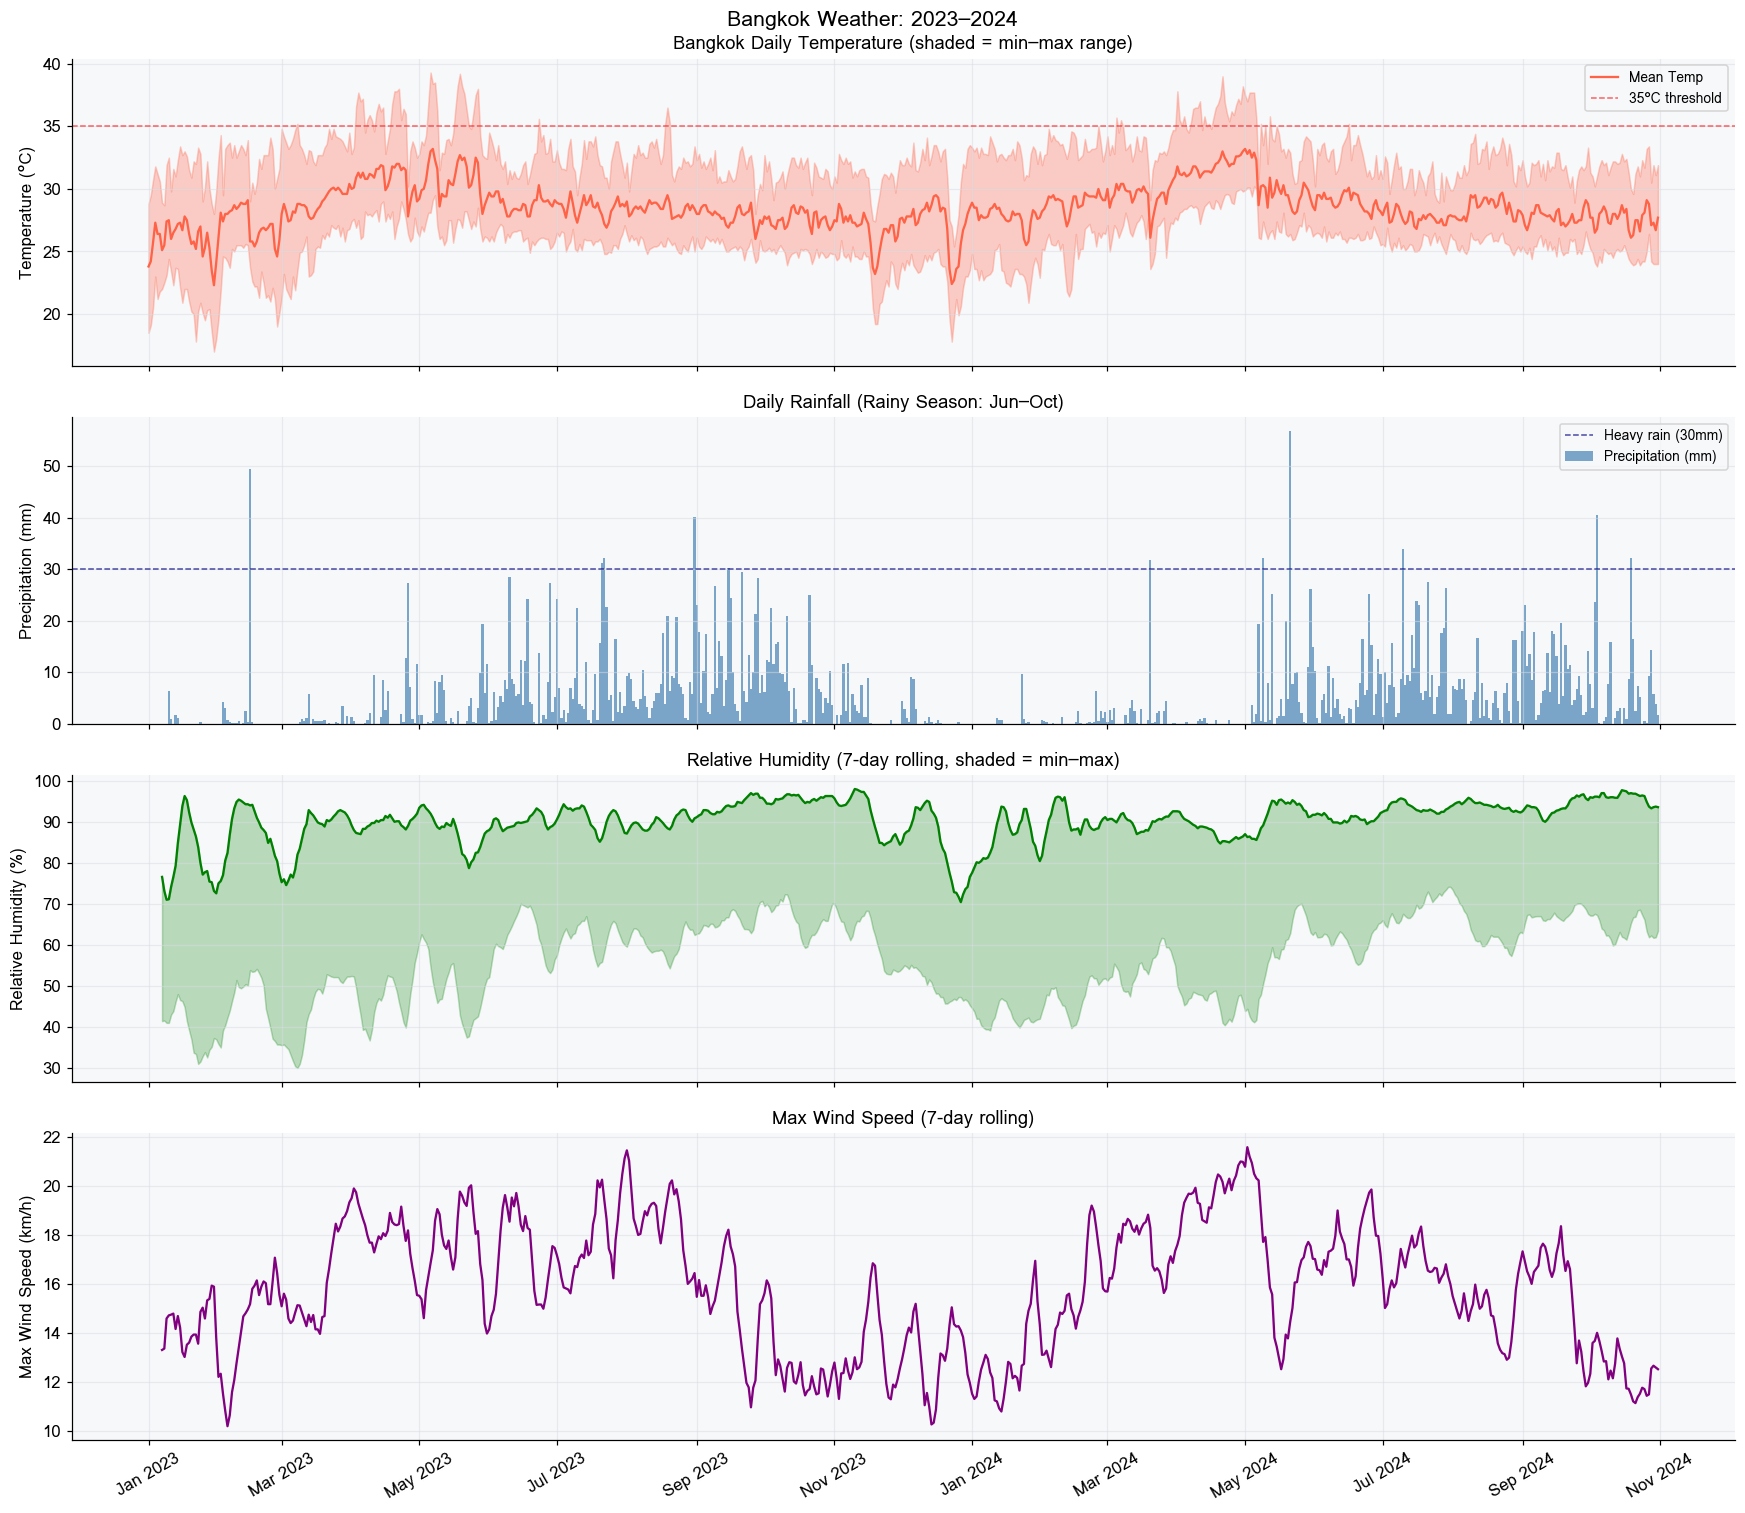

In [ ]:

# ── PLOT: Bangkok Weather Patterns 2023-2024 ────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Temperature
axes[0].fill_between(weather["date"], weather["temperature_min"],
                     weather["temperature_max"], alpha=0.3, color="tomato")
axes[0].plot(weather["date"], weather["temperature_mean"], color="tomato", lw=1.5, label="Mean Temp")
axes[0].axhline(35, color="red", ls="--", lw=1, alpha=0.6, label="35°C threshold")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Bangkok Daily Temperature (shaded = min–max range)")
axes[0].legend(fontsize=9)

# Rainfall
axes[1].bar(weather["date"], weather["precipitation"], color="steelblue",
            alpha=0.7, width=1.0, label="Precipitation (mm)")
axes[1].axhline(30, color="navy", ls="--", lw=1, alpha=0.7, label="Heavy rain (30mm)")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_title("Daily Rainfall (Rainy Season: Jun–Oct)")
axes[1].legend(fontsize=9)

# Humidity
axes[2].plot(weather["date"], weather["relative_humidity_max"].rolling(7).mean(),
             color="green", lw=1.5)
axes[2].fill_between(weather["date"],
                     weather["relative_humidity_min"].rolling(7).mean(),
                     weather["relative_humidity_max"].rolling(7).mean(),
                     alpha=0.25, color="green")
axes[2].set_ylabel("Relative Humidity (%)")
axes[2].set_title("Relative Humidity (7-day rolling, shaded = min–max)")

# Wind
axes[3].plot(weather["date"], weather["wind_speed_max"].rolling(7).mean(),
             color="purple", lw=1.5)
axes[3].set_ylabel("Max Wind Speed (km/h)")
axes[3].set_title("Max Wind Speed (7-day rolling)")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.suptitle("Bangkok Weather: 2023–2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


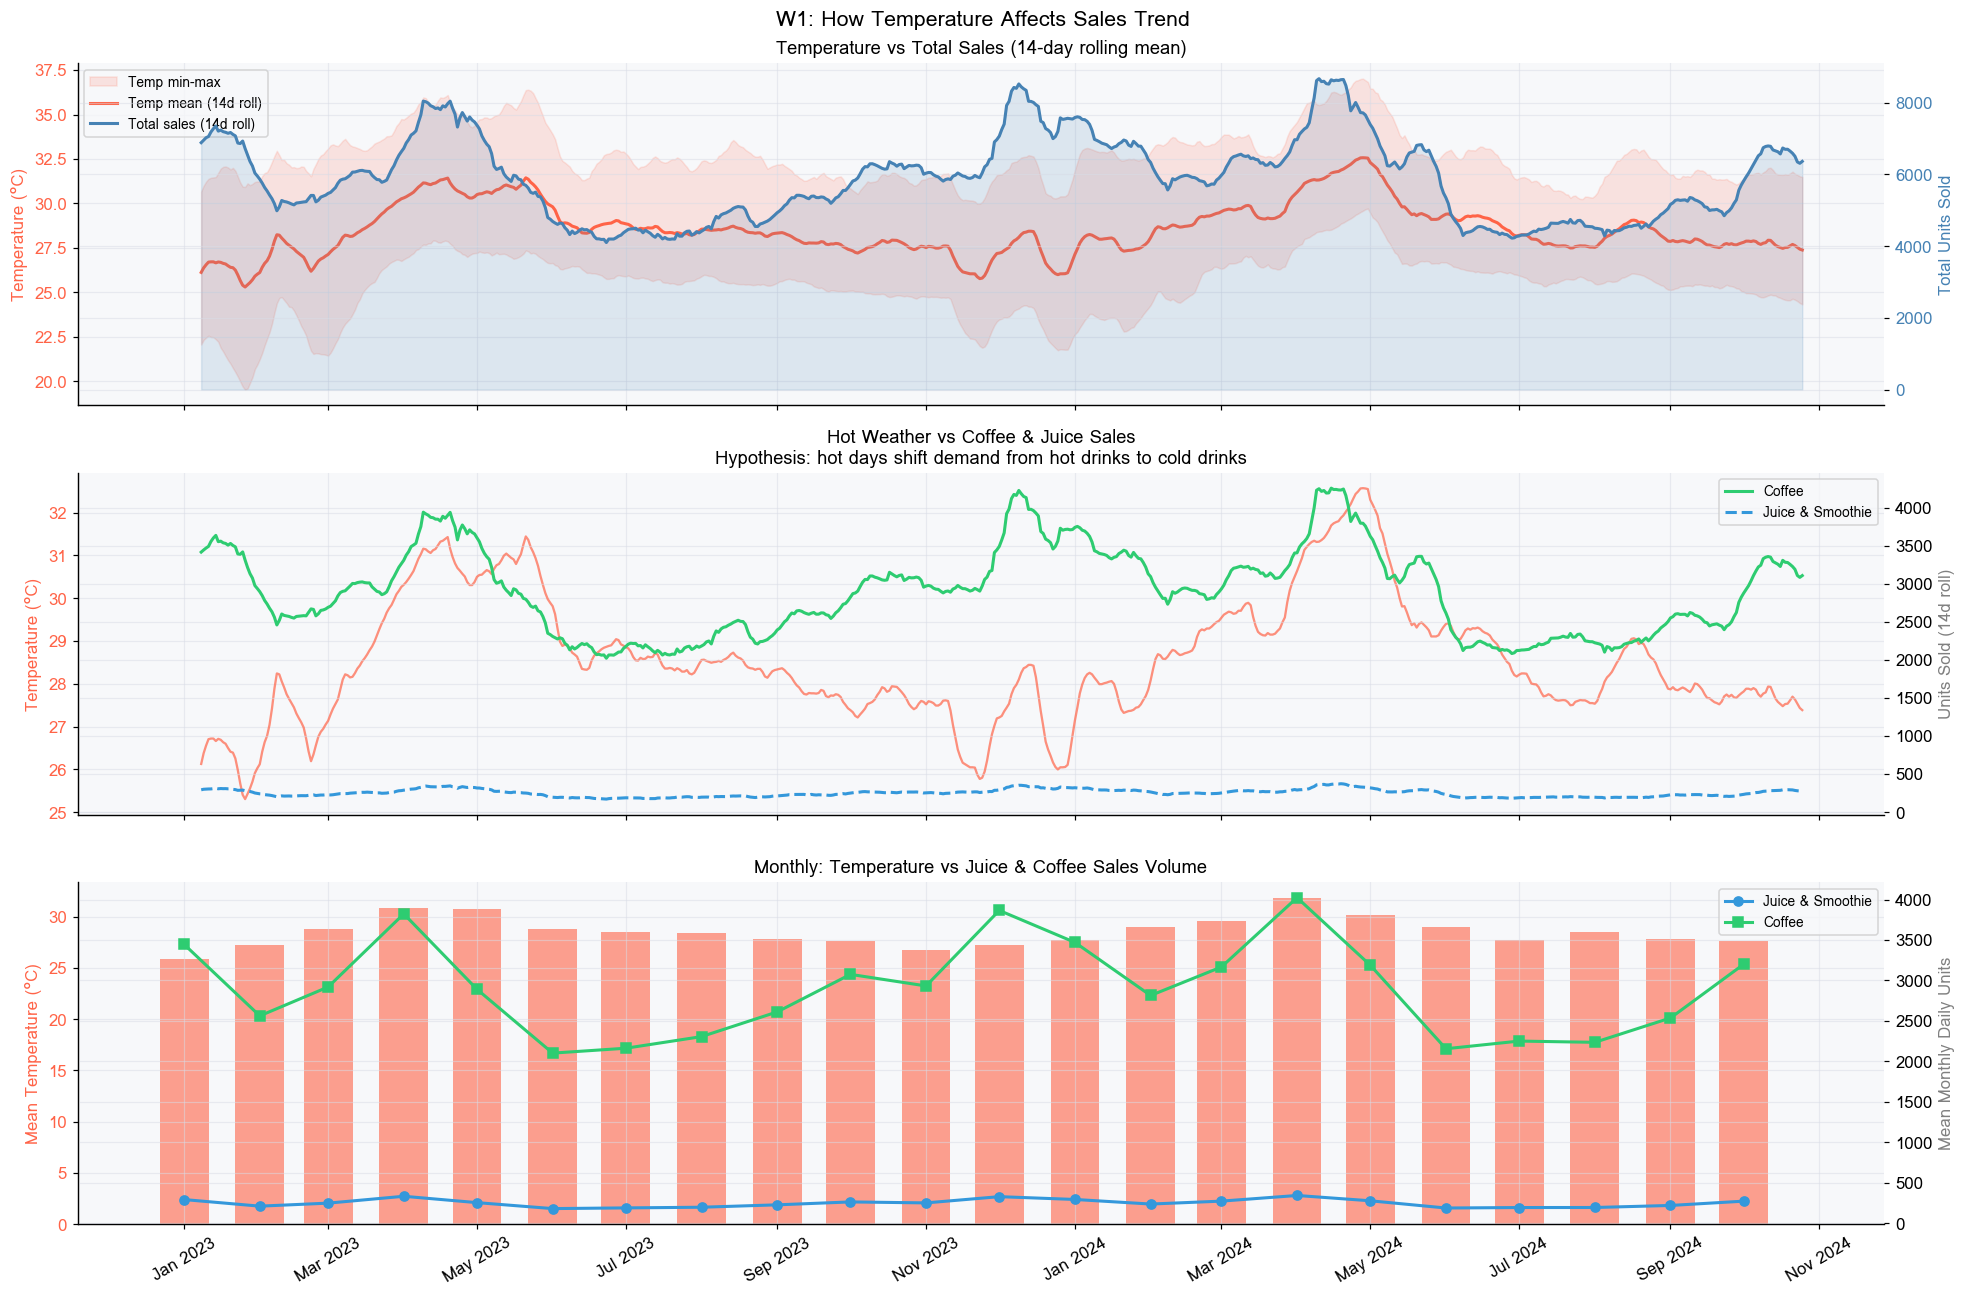

In [ ]:
# ── W1: Temperature vs Total Sales — Time Series Overlay ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

roll = 14  # 2-week smoothing

# ── Top: Total sales vs temperature ──────────────────────────────────────────
ax1 = axes[0]
ax2 = ax1.twinx()

sales_roll = daily_total.rolling(roll, center=True).mean()
temp_roll  = weather.set_index("date")["temperature_mean"].reindex(DATES).rolling(roll, center=True).mean()
temp_max   = weather.set_index("date")["temperature_max"].reindex(DATES).rolling(roll, center=True).mean()
temp_min   = weather.set_index("date")["temperature_min"].reindex(DATES).rolling(roll, center=True).mean()

ax1.fill_between(DATES, temp_min, temp_max, alpha=0.15, color="tomato", label="Temp min-max")
ax1.plot(DATES, temp_roll, color="tomato", lw=2, label="Temp mean (14d roll)")
ax1.set_ylabel("Temperature (°C)", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2.plot(DATES, sales_roll, color="steelblue", lw=2, label="Total sales (14d roll)")
ax2.fill_between(DATES, sales_roll, alpha=0.15, color="steelblue")
ax2.set_ylabel("Total Units Sold", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc="upper left")
ax1.set_title("Temperature vs Total Sales (14-day rolling mean)")

# ── Middle: Hot-category spotlight — Coffee vs Juice & Smoothie ──────────────
ax3 = axes[1]
ax4 = ax3.twinx()

ax3.plot(DATES, temp_roll, color="tomato", lw=1.5, alpha=0.7, label="Temp (°C)")
ax3.set_ylabel("Temperature (°C)", color="tomato")
ax3.tick_params(axis="y", labelcolor="tomato")

for cat, color, ls in [("Coffee","#2ecc71","-"), ("Juice & Smoothie","#3498db","--")]:
    if cat in daily.columns:
        ax4.plot(DATES, daily[cat].rolling(roll, center=True).mean(),
                 color=color, lw=2, ls=ls, label=cat)
ax4.set_ylabel("Units Sold (14d roll)", color="gray")
ax4.legend(fontsize=9, loc="upper right")
ax3.set_title("Hot Weather vs Coffee & Juice Sales\n"
              "Hypothesis: hot days shift demand from hot drinks to cold drinks")

# ── Bottom: Month-level average — temperature vs Juice share ─────────────────
ax5 = axes[2]
ax6 = ax5.twinx()

monthly_temp  = weather.set_index("date")["temperature_mean"].resample("MS").mean()
monthly_juice = daily["Juice & Smoothie"].resample("MS").mean() if "Juice & Smoothie" in daily.columns else None
monthly_coffee= daily["Coffee"].resample("MS").mean()

ax5.bar(monthly_temp.index, monthly_temp.values, width=20,
        color="tomato", alpha=0.6, label="Avg Temp (°C)")
ax5.set_ylabel("Mean Temperature (°C)", color="tomato")
ax5.tick_params(axis="y", labelcolor="tomato")

if monthly_juice is not None:
    ax6.plot(monthly_juice.index, monthly_juice.values, "-o",
             color="#3498db", lw=2, markersize=6, label="Juice & Smoothie")
ax6.plot(monthly_coffee.index, monthly_coffee.values, "-s",
         color="#2ecc71", lw=2, markersize=6, label="Coffee")
ax6.set_ylabel("Mean Monthly Daily Units", color="gray")
ax6.legend(fontsize=9)
ax5.set_title("Monthly: Temperature vs Juice & Coffee Sales Volume")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].get_xticklabels(), rotation=30)

plt.suptitle("W1: How Temperature Affects Sales Trend",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

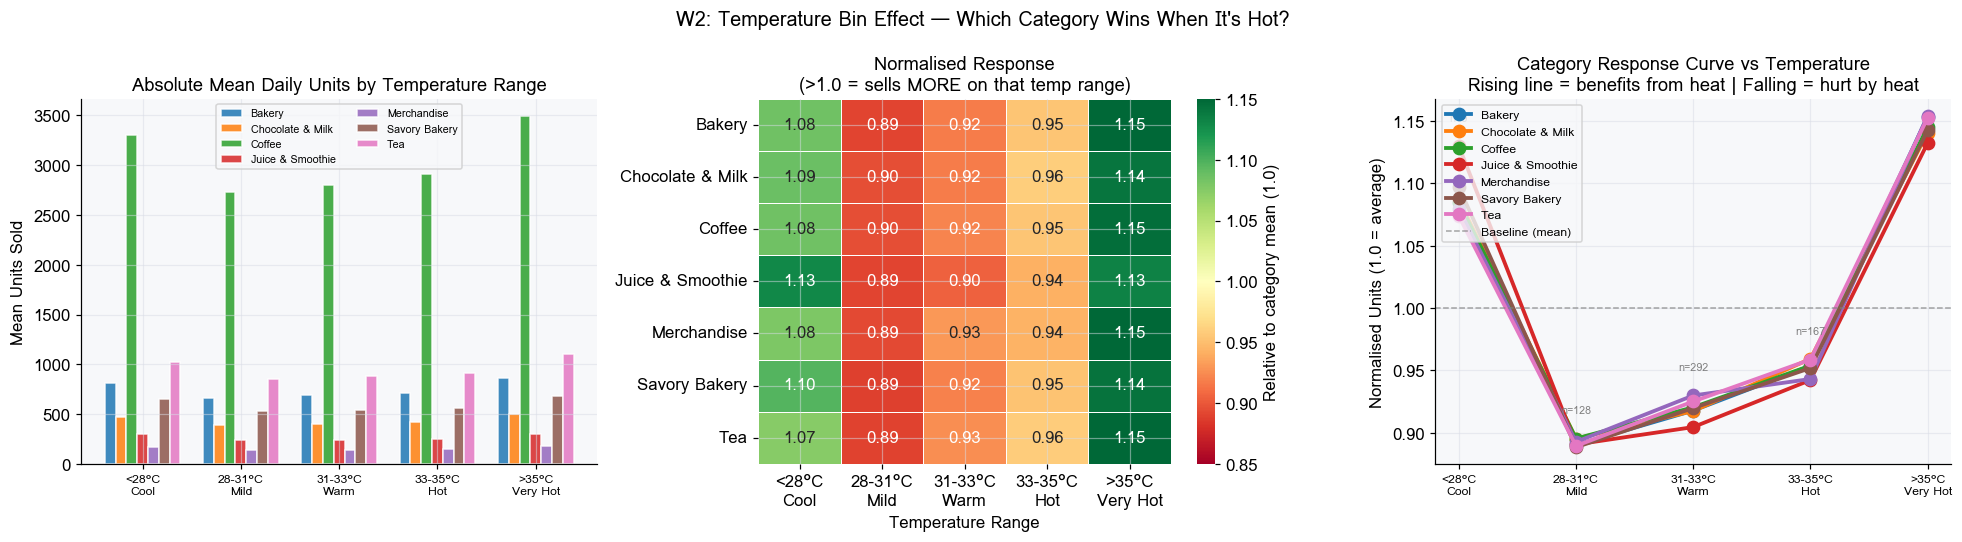

In [ ]:
# ── W2: Temperature Bins — How Each Category Responds ────────────────────────
temp_series = weather.set_index("date")["temperature_max"].reindex(DATES)

bins   = [0,  28,  31,  33,  35, 50]
labels = ["<28°C\nCool", "28-31°C\nMild", "31-33°C\nWarm",
          "33-35°C\nHot",  ">35°C\nVery Hot"]
temp_bin = pd.cut(temp_series, bins=bins, labels=labels)

# Mean sales per bin per category
bin_cat = pd.DataFrame({"bin": temp_bin})
for cat in CATEGORIES:
    if cat in daily.columns:
        bin_cat[cat] = daily[cat].values

means = bin_cat.groupby("bin")[CATEGORIES].mean()
counts = bin_cat.groupby("bin").size().rename("n_days")
means_norm = means.div(means.mean())   # normalised to category mean

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Absolute mean per bin ─────────────────────────────────────────────────────
x = np.arange(len(labels))
w = 0.11
for i, cat in enumerate(CATEGORIES):
    if cat in means.columns:
        axes[0].bar(x + i*w - 3*w, means[cat].values,
                    width=w, label=cat,
                    color=CAT_PAL[cat], alpha=0.85, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_title("Absolute Mean Daily Units by Temperature Range")
axes[0].set_ylabel("Mean Units Sold")
axes[0].legend(fontsize=7, ncol=2)

# ── Normalised heatmap ────────────────────────────────────────────────────────
sns.heatmap(
    means_norm.T.reindex(CATEGORIES),
    annot=True, fmt=".2f", cmap="RdYlGn",
    center=1.0, linewidths=0.4,
    ax=axes[1],
    cbar_kws={"label": "Relative to category mean (1.0)"},
    vmin=0.85, vmax=1.15
)
axes[1].set_title("Normalised Response\n(>1.0 = sells MORE on that temp range)")
axes[1].set_xlabel("Temperature Range")
axes[1].set_ylabel("")

# ── Line chart — winner per temperature ──────────────────────────────────────
for cat in CATEGORIES:
    if cat in means_norm.columns:
        axes[2].plot(range(len(labels)), means_norm[cat].values,
                     "-o", label=cat, color=CAT_PAL[cat],
                     lw=2.5, markersize=8)
axes[2].axhline(1.0, color="gray", ls="--", lw=1, alpha=0.7, label="Baseline (mean)")
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, fontsize=8)
axes[2].set_title("Category Response Curve vs Temperature\n"
                   "Rising line = benefits from heat | Falling = hurt by heat")
axes[2].set_ylabel("Normalised Units (1.0 = average)")
axes[2].legend(fontsize=8, loc="upper left")

# Sample count per bin
for i, (lbl, n) in enumerate(zip(labels, counts.values)):
    axes[2].annotate(f"n={n}", xy=(i, means_norm.iloc[i].max() + 0.02),
                     ha="center", fontsize=7, color="gray")

plt.suptitle("W2: Temperature Bin Effect — Which Category Wins When It's Hot?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

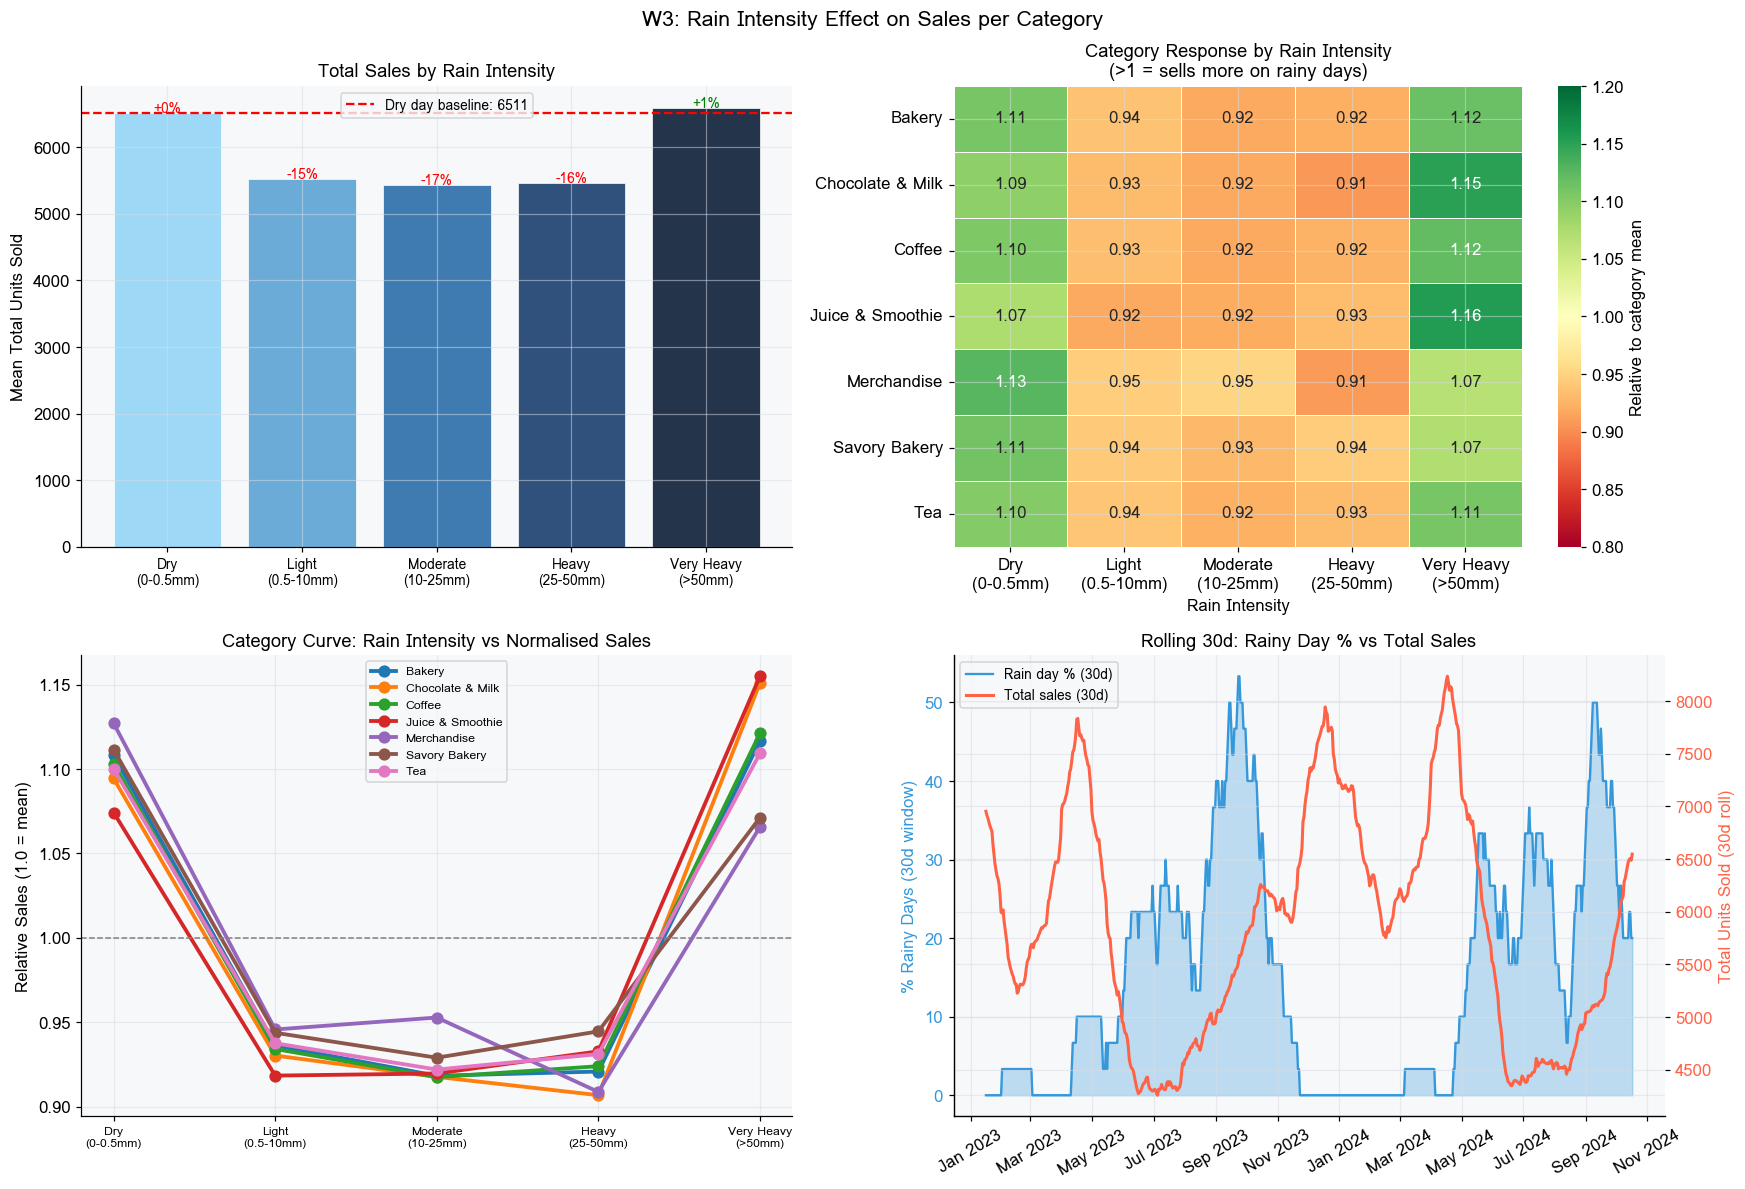

In [ ]:
# ── W3: Rain Effect on Sales ──────────────────────────────────────────────────
rain_series = weather.set_index("date")["precipitation"].reindex(DATES).fillna(0)

rain_bins   = [-1, 0.5, 10, 25, 50, 999]
rain_labels = ["Dry\n(0-0.5mm)", "Light\n(0.5-10mm)", "Moderate\n(10-25mm)",
               "Heavy\n(25-50mm)", "Very Heavy\n(>50mm)"]
rain_bin = pd.cut(rain_series, bins=rain_bins, labels=rain_labels)

bin_rain = pd.DataFrame({"bin": rain_bin})
for cat in CATEGORIES:
    if cat in daily.columns:
        bin_rain[cat] = daily[cat].values
bin_rain["total"] = daily_total.values

means_rain  = bin_rain.groupby("bin")[CATEGORIES + ["total"]].mean()
counts_rain = bin_rain.groupby("bin").size()
means_rain_norm = means_rain.div(means_rain.mean())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Total sales by rain intensity ─────────────────────────────────────────────
baseline = bin_rain[bin_rain["bin"]=="Dry\n(0-0.5mm)"]["total"].mean()
rain_colors = ["#95d5f7","#5ba4d4","#2b6ea8","#1a3f6e","#0d1f38"]

bars = axes[0,0].bar(range(len(rain_labels)), means_rain["total"].values,
                     color=rain_colors, alpha=0.9, edgecolor="white", lw=0.5)
axes[0,0].axhline(baseline, color="red", ls="--", lw=1.5,
                   label=f"Dry day baseline: {baseline:.0f}")
axes[0,0].set_xticks(range(len(rain_labels)))
axes[0,0].set_xticklabels(rain_labels, fontsize=9)
axes[0,0].set_title("Total Sales by Rain Intensity")
axes[0,0].set_ylabel("Mean Total Units Sold")
axes[0,0].legend(fontsize=9)
for bar, val in zip(bars, means_rain["total"].values):
    pct = (val / baseline - 1) * 100
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 5,
                   f"{pct:+.0f}%", ha="center",
                   fontsize=9, fontweight="bold",
                   color="green" if pct > 0 else "red")

# ── Normalised heatmap ────────────────────────────────────────────────────────
sns.heatmap(
    means_rain_norm[CATEGORIES].T.reindex(CATEGORIES),
    annot=True, fmt=".2f", cmap="RdYlGn",
    center=1.0, linewidths=0.4, ax=axes[0,1],
    cbar_kws={"label": "Relative to category mean"},
    vmin=0.80, vmax=1.20
)
axes[0,1].set_title("Category Response by Rain Intensity\n(>1 = sells more on rainy days)")
axes[0,1].set_xlabel("Rain Intensity")

# ── Line chart per category ───────────────────────────────────────────────────
for cat in CATEGORIES:
    if cat in means_rain_norm.columns:
        axes[1,0].plot(range(len(rain_labels)), means_rain_norm[cat].values,
                       "-o", label=cat, color=CAT_PAL[cat],
                       lw=2.5, markersize=7)
axes[1,0].axhline(1.0, color="gray", ls="--", lw=1)
axes[1,0].set_xticks(range(len(rain_labels)))
axes[1,0].set_xticklabels(rain_labels, fontsize=8)
axes[1,0].set_title("Category Curve: Rain Intensity vs Normalised Sales")
axes[1,0].set_ylabel("Relative Sales (1.0 = mean)")
axes[1,0].legend(fontsize=8)

# ── Rolling 30d: Rain days fraction vs total sales ───────────────────────────
rain_roll   = (rain_series > 10).astype(float).rolling(30, center=True).mean() * 100
sales_roll2 = daily_total.rolling(30, center=True).mean()

ax_r = axes[1,1]
ax_s = ax_r.twinx()
ax_r.fill_between(DATES, rain_roll, alpha=0.3, color="#3498db")
ax_r.plot(DATES, rain_roll, color="#3498db", lw=1.5, label="Rain day % (30d)")
ax_r.set_ylabel("% Rainy Days (30d window)", color="#3498db")
ax_r.tick_params(axis="y", labelcolor="#3498db")
ax_s.plot(DATES, sales_roll2, color="tomato", lw=2, label="Total sales (30d)")
ax_s.set_ylabel("Total Units Sold (30d roll)", color="tomato")
ax_s.tick_params(axis="y", labelcolor="tomato")
ax_r.set_title("Rolling 30d: Rainy Day % vs Total Sales")
lines_r, lbl_r = ax_r.get_legend_handles_labels()
lines_s, lbl_s = ax_s.get_legend_handles_labels()
ax_r.legend(lines_r+lines_s, lbl_r+lbl_s, fontsize=9)
ax_r.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_r.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax_r.get_xticklabels(), rotation=30)

plt.suptitle("W3: Rain Intensity Effect on Sales per Category",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Feature table shape: (93800, 54)
Requested features available: 40 / 40


,feature,type,pearson,spearman,abs_score,family
0,sales_roll_mean_7,numeric,0.870,0.905,0.905,sales history
1,sales_roll_mean_14,numeric,0.868,0.905,0.905,sales history
2,sales_roll_mean_28,numeric,0.861,0.902,0.902,sales history
3,sales_roll_mean_56,numeric,0.853,0.897,0.897,sales history
4,sales_roll_max_28,numeric,0.773,0.873,0.873,sales history
5,sales_roll_std_56,numeric,0.780,0.868,0.868,sales history
6,sales_roll_std_28,numeric,0.766,0.865,0.865,sales history
7,sales_roll_max_56,numeric,0.760,0.864,0.864,sales history
8,product_count,numeric,0.728,0.603,0.728,product/category
9,sales_cv_28,numeric,-0.254,-0.503,0.503,sales history


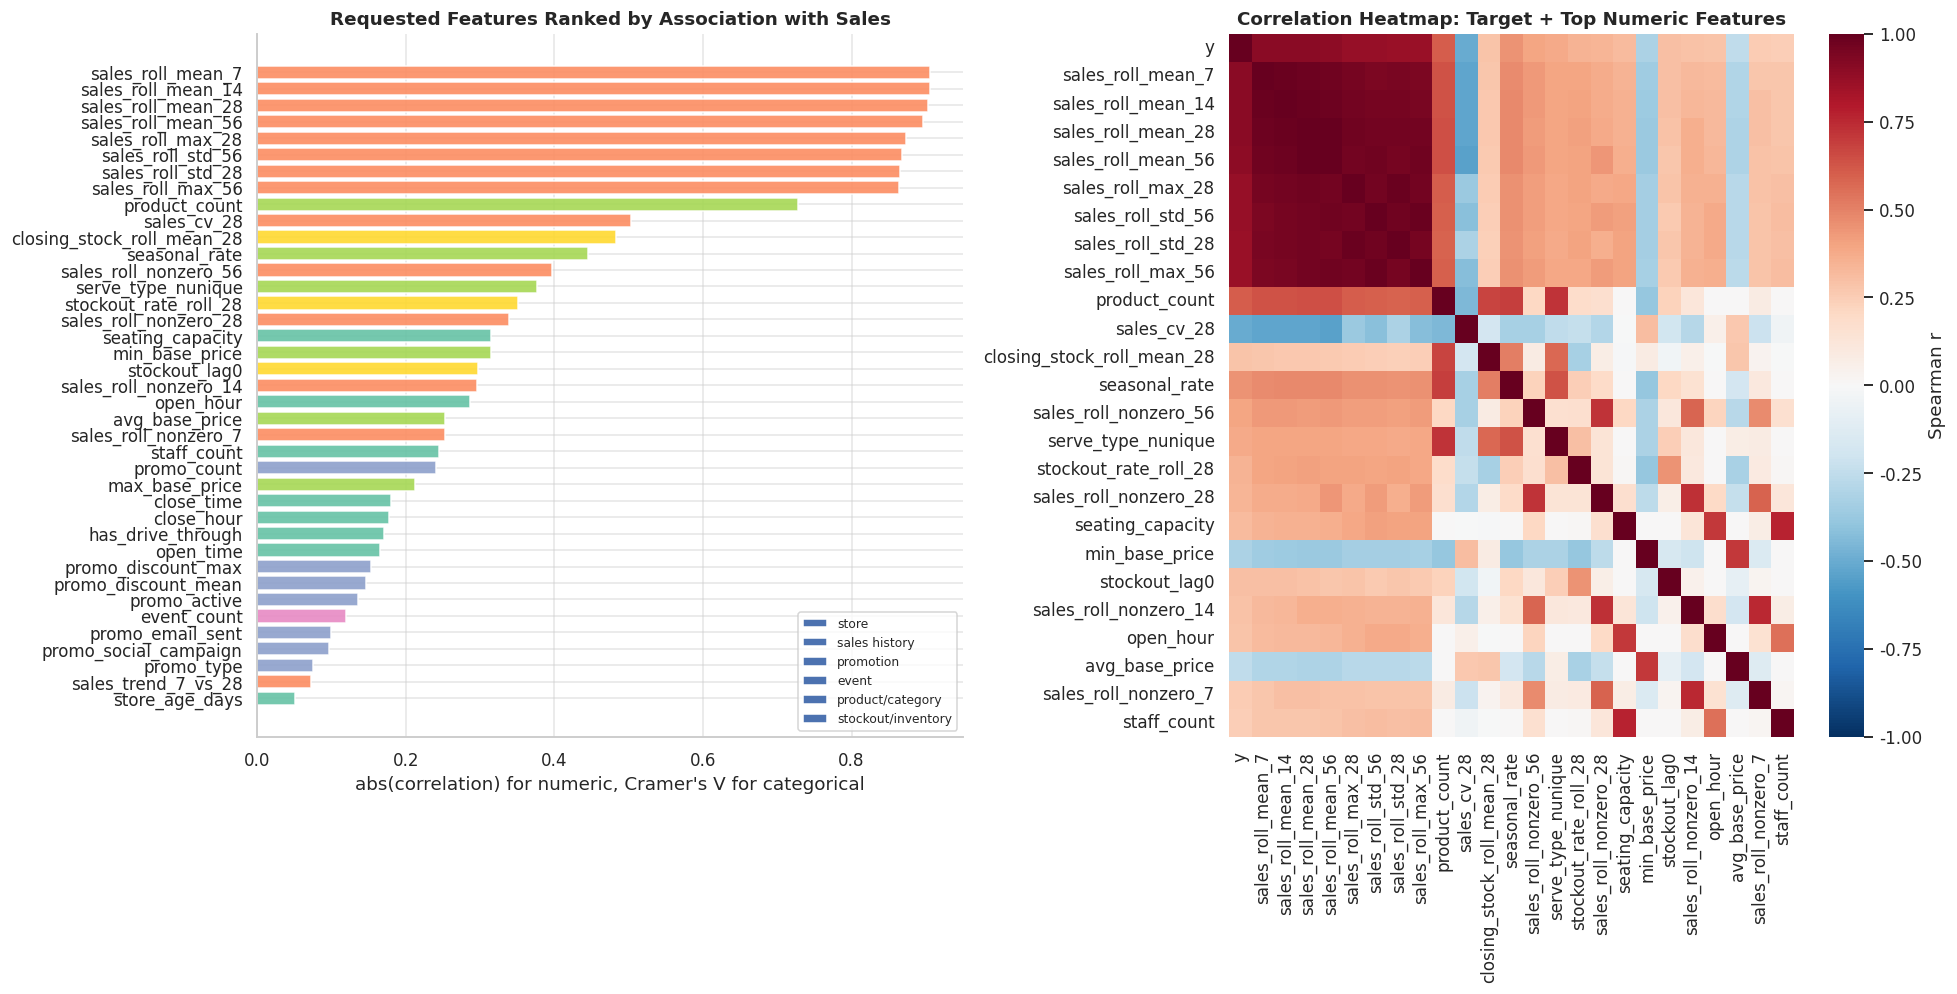

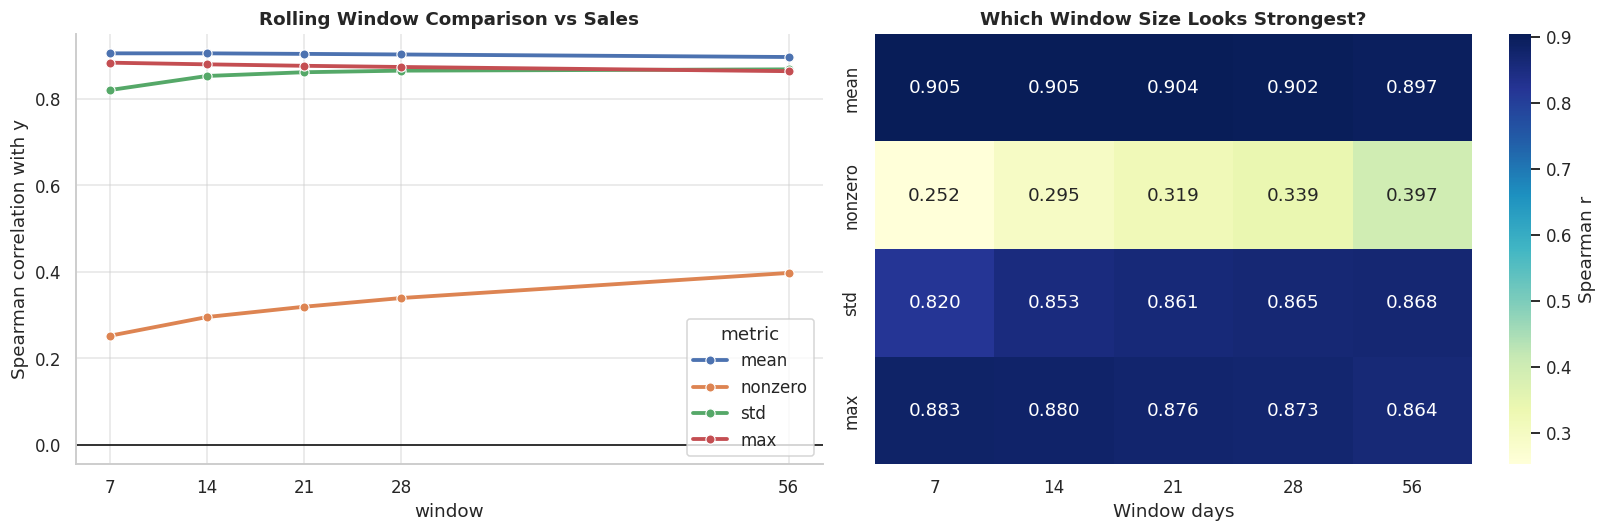

,metric,window,spearman,pearson
0,mean,7,0.904999,0.870409
1,mean,14,0.904995,0.868018
2,mean,21,0.903756,0.864277
3,mean,28,0.902395,0.861293
4,mean,56,0.896520,0.852598
15,max,7,0.883397,0.800788
16,max,14,0.879574,0.787586
17,max,21,0.876208,0.779105
18,max,28,0.873484,0.773370
14,std,56,0.867977,0.780041


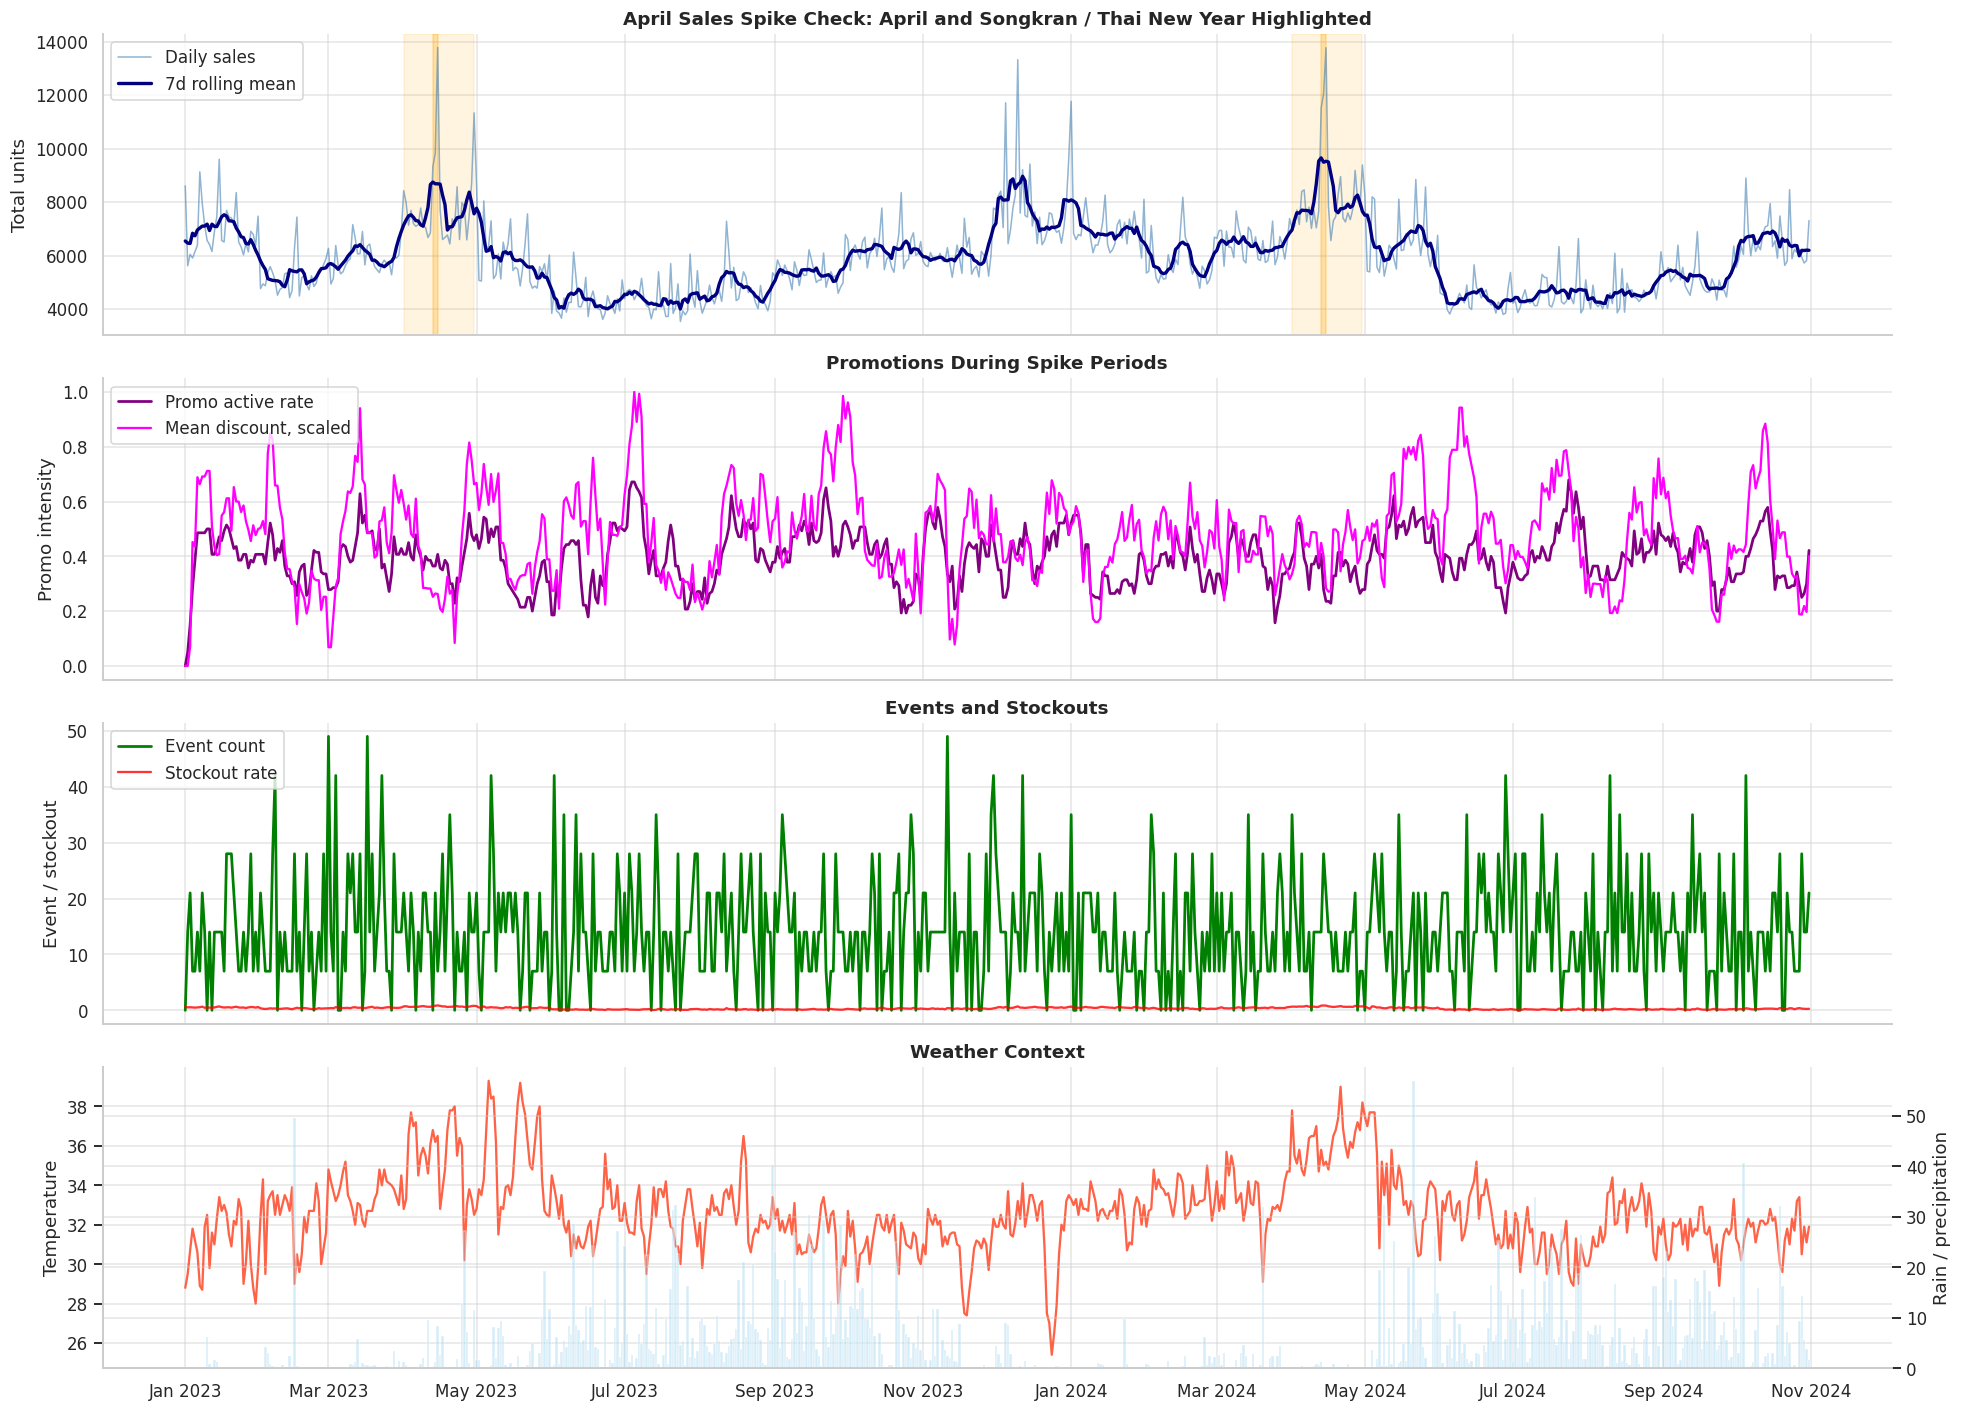

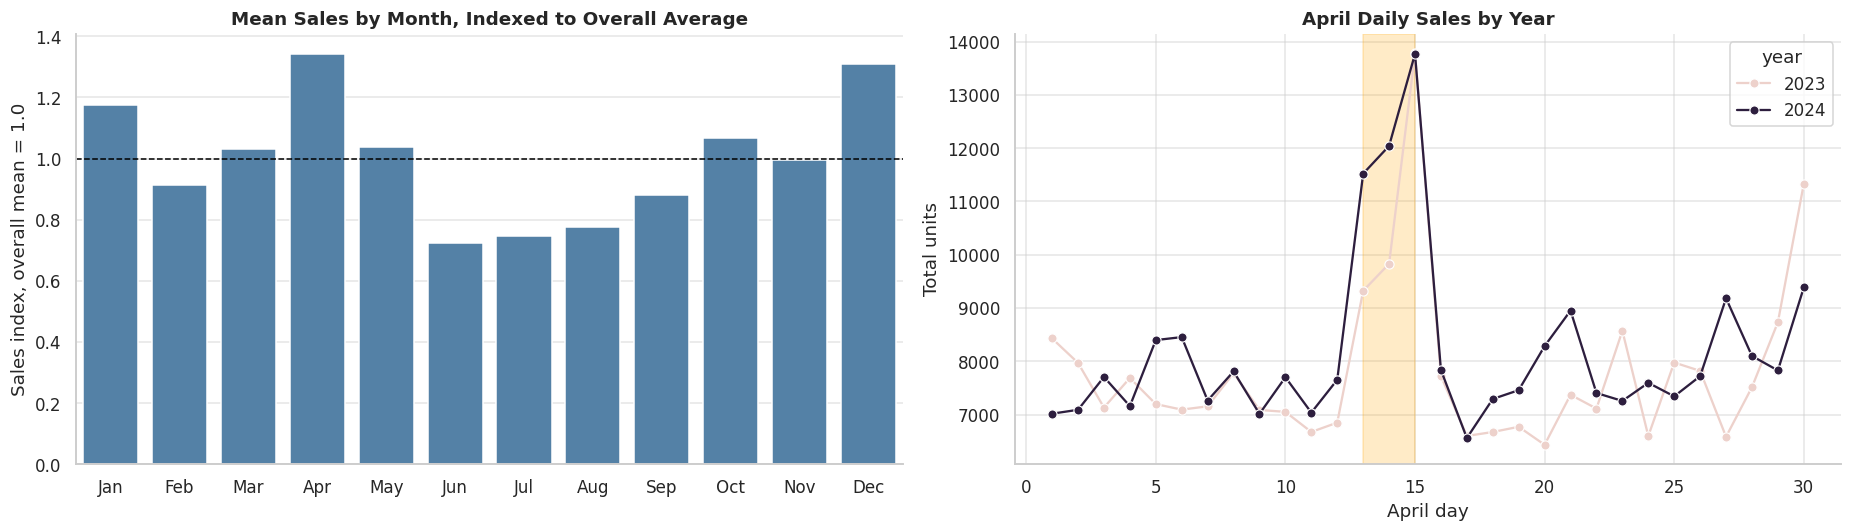

Top April sales days and possible drivers:


,date,total_sales,spike_vs_28_pct,is_holiday,holiday_name,is_school_break,is_payday,is_weekend,promo_active_rate,promo_count,discount_mean,event_count,stockout_rate,temperature_max,precipitation
104,2023-04-15,13780.0,92.002229,True,วันสงกรานต์,True,True,True,0.407143,357.0,4.666982,7.0,0.878571,36.5,8.4
470,2024-04-15,13770.0,79.331901,True,วันสงกรานต์,True,True,False,0.235714,156.0,5.039630,21.0,0.850000,35.2,0.0
469,2024-04-14,12043.0,57.920273,True,วันสงกรานต์,True,False,True,0.278571,172.0,7.119987,28.0,0.864286,35.0,0.1
468,2024-04-13,11522.0,53.055260,True,วันสงกรานต์,True,False,True,0.407143,297.0,7.978542,14.0,0.842857,35.8,1.2
119,2023-04-30,11334.0,70.769926,False,NaN,True,True,True,0.457143,332.0,11.778194,14.0,0.807143,32.5,11.6
103,2023-04-14,9831.0,37.602351,True,วันสงกรานต์,True,False,False,0.364286,247.0,4.694593,21.0,0.821429,36.2,1.3
485,2024-04-30,9387.0,27.289986,False,NaN,True,True,False,0.278571,181.0,8.097279,7.0,0.714286,38.2,0.0
102,2023-04-13,9324.0,30.505984,True,วันสงกรานต์,True,False,False,0.364286,247.0,4.482143,0.0,0.757143,36.8,0.0
482,2024-04-27,9183.0,19.890332,False,NaN,True,False,True,0.364286,247.0,8.854600,21.0,0.807143,36.7,0.0
476,2024-04-21,8952.0,16.078838,False,NaN,True,False,True,0.414286,392.0,6.133929,7.0,0.764286,39.0,0.0


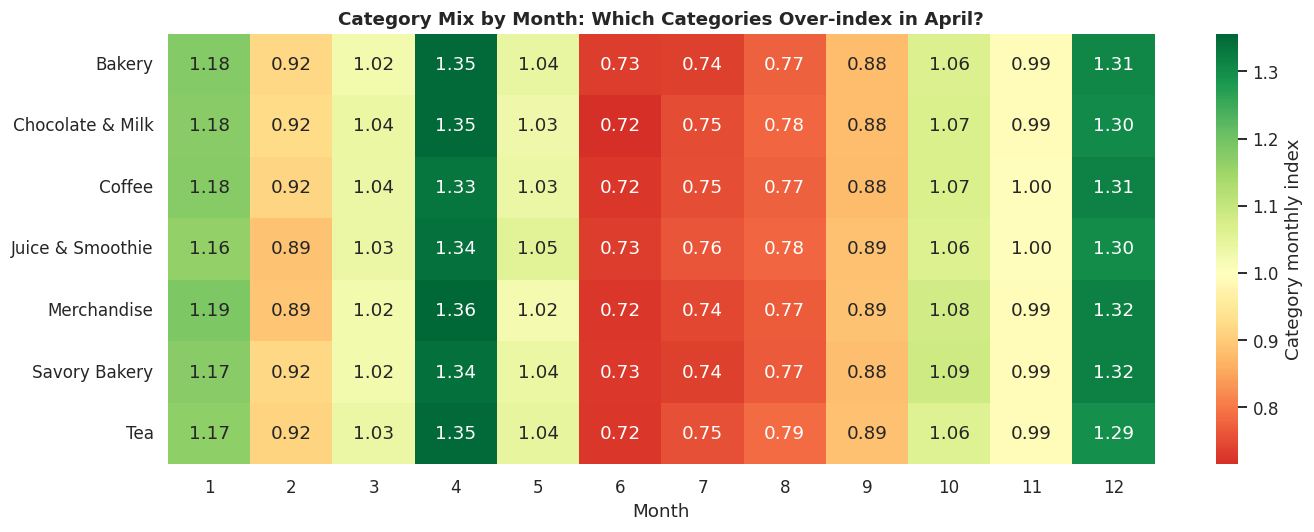


INTERPRETATION GUIDE
April mean sales index: 1.34 (1.00 = average month)
April promo active rate: 37.30% vs month avg 39.66%
April event count/day: 13.42 vs month avg 13.97
April stockout rate: 69.26% vs month avg 35.02%
Likely explanation to check: April peaks coincide with Songkran / Thai New Year demand, holiday travel, hotter weather, and any promotions/events active around Apr 13-15.
If April spikes happen even without promo/event lifts, add explicit features such as is_songkran_window, days_to_songkran, and days_after_songkran.


In [ ]:
# -----------------------------------------------------------------------------
# Feature importance EDA: correlations, rolling-window comparison, April spike
# Add this after the last cell. It uses existing notebook objects:
# panel, product, store_df, promotion, event, inventory, date_dim, weather (optional)
# -----------------------------------------------------------------------------
from IPython.display import display
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Keep figures readable in notebooks
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# -----------------------------
# 1) Helper functions
# -----------------------------
def _first_col(df, candidates):
    """Return the first existing column from candidates, else None."""
    return next((c for c in candidates if c in df.columns), None)

def _as_hour(s):
    """Parse HH:MM / HH:MM:SS / numeric time into hour."""
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    return pd.to_datetime(s.astype(str), errors="coerce").dt.hour

def _mode_or_none(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) else "none"

def _to_number(s):
    """Convert numeric, bool, and common yes/no strings into numeric values."""
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    mapped = s.astype(str).str.strip().str.lower().map({
        "true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0,
        "1": 1, "0": 0, "nan": np.nan, "none": np.nan, "": np.nan,
    })
    numeric = pd.to_numeric(s, errors="coerce")
    return mapped.fillna(numeric)

def _cramers_v(x, y):
    """Cramer's V for categorical feature vs target bins."""
    tab = pd.crosstab(x.fillna("missing").astype(str), y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.to_numpy().sum()
    return np.sqrt((chi2 / n) / max(1, min(tab.shape) - 1))

def _corr_one(df, feature, target="y"):
    """Pearson/Spearman for numeric, Cramer's V vs target quantile bins for categorical."""
    tmp = df[[feature, target]].dropna()
    if tmp.empty or tmp[feature].nunique(dropna=True) <= 1:
        return {"feature": feature, "type": "constant/missing", "pearson": np.nan, "spearman": np.nan, "abs_score": np.nan}

    if pd.api.types.is_numeric_dtype(tmp[feature]) or pd.api.types.is_bool_dtype(tmp[feature]):
        x = pd.to_numeric(tmp[feature], errors="coerce")
        tmp = pd.DataFrame({feature: x, target: tmp[target]}).dropna()
        if tmp[feature].nunique() <= 1:
            return {"feature": feature, "type": "numeric", "pearson": np.nan, "spearman": np.nan, "abs_score": np.nan}
        pearson = tmp[feature].corr(tmp[target], method="pearson")
        spearman = tmp[feature].corr(tmp[target], method="spearman")
        score = max(abs(pearson), abs(spearman))
        return {"feature": feature, "type": "numeric", "pearson": pearson, "spearman": spearman, "abs_score": score}

    # Categorical association with binned y; not directly comparable to Pearson,
    # but useful for ranking category-like columns such as promo_type.
    try:
        y_bin = pd.qcut(tmp[target], q=5, duplicates="drop")
        assoc = _cramers_v(tmp[feature], y_bin)
    except Exception:
        assoc = np.nan
    return {"feature": feature, "type": "categorical", "pearson": np.nan, "spearman": np.nan, "abs_score": assoc}

# -----------------------------
# 2) Build row-level feature table
# -----------------------------
feat = panel[["store_id", "category", "date", "y"]].copy()
feat["date"] = pd.to_datetime(feat["date"])
feat = feat.sort_values(["store_id", "category", "date"]).reset_index(drop=True)

# Rolling sales features: shifted by 1 day to avoid same-day target leakage.
g = feat.groupby(["store_id", "category"], sort=False)["y"]
y_lag1 = g.shift(1)
windows = [7, 14, 21, 28, 56]

for w in windows:
    feat[f"sales_roll_mean_{w}"] = y_lag1.groupby([feat["store_id"], feat["category"]]).transform(lambda s: s.rolling(w, min_periods=max(3, w // 2)).mean())
    feat[f"sales_roll_nonzero_{w}"] = y_lag1.groupby([feat["store_id"], feat["category"]]).transform(lambda s: (s > 0).rolling(w, min_periods=max(3, w // 2)).mean())
    feat[f"sales_roll_std_{w}"] = y_lag1.groupby([feat["store_id"], feat["category"]]).transform(lambda s: s.rolling(w, min_periods=max(3, w // 2)).std())
    feat[f"sales_roll_max_{w}"] = y_lag1.groupby([feat["store_id"], feat["category"]]).transform(lambda s: s.rolling(w, min_periods=max(3, w // 2)).max())

feat["sales_trend_7_vs_28"] = feat["sales_roll_mean_7"] / feat["sales_roll_mean_28"].replace(0, np.nan) - 1
feat["sales_cv_28"] = feat["sales_roll_std_28"] / feat["sales_roll_mean_28"].replace(0, np.nan)

# Stockout and inventory features
inv = inventory.copy()
inv["date"] = pd.to_datetime(inv["date"])
inv_cat = inv.merge(product[["product_id", "category"]], on="product_id", how="left")
if "is_stockout" in inv_cat.columns:
    inv_cat["is_stockout"] = _to_number(inv_cat["is_stockout"]).fillna(0)
stock_col = _first_col(inv_cat, ["closing_stock", "stock_on_hand", "stock_qty", "available_stock", "quantity", "stock"])
if stock_col is not None:
    inv_cat[stock_col] = pd.to_numeric(inv_cat[stock_col], errors="coerce")
stock_aggs = {
    "stockout_lag0": ("is_stockout", "max"),
    "stockout_rate_lag0": ("is_stockout", "mean"),
}
if stock_col is not None:
    stock_aggs["closing_stock"] = (stock_col, "sum")

inv_daily = (
    inv_cat.groupby(["store_id", "category", "date"])
    .agg(**stock_aggs)
    .reset_index()
)
feat = feat.merge(inv_daily, on=["store_id", "category", "date"], how="left")
feat["stockout_lag0"] = feat["stockout_lag0"].fillna(0).astype(int)
feat["stockout_rate_lag0"] = feat["stockout_rate_lag0"].fillna(0)
feat["stockout_rate_roll_28"] = (
    feat.sort_values(["store_id", "category", "date"])
    .groupby(["store_id", "category"])["stockout_rate_lag0"]
    .transform(lambda s: s.shift(1).rolling(28, min_periods=7).mean())
)
if "closing_stock" in feat.columns:
    feat["closing_stock_roll_mean_28"] = (
        feat.sort_values(["store_id", "category", "date"])
        .groupby(["store_id", "category"])["closing_stock"]
        .transform(lambda s: s.shift(1).rolling(28, min_periods=7).mean())
    )
else:
    feat["closing_stock_roll_mean_28"] = np.nan

# Store features
store_features = store_df.copy()
if "opened_date" in store_features.columns:
    store_features["opened_date"] = pd.to_datetime(store_features["opened_date"], errors="coerce")
    store_features["store_age_days"] = (feat["date"].max() - store_features["opened_date"]).dt.days
if "open_time" in store_features.columns:
    store_features["open_hour"] = _as_hour(store_features["open_time"])
if "close_time" in store_features.columns:
    store_features["close_hour"] = _as_hour(store_features["close_time"])
if "has_drive_through" in store_features.columns:
    store_features["has_drive_through"] = _to_number(store_features["has_drive_through"]).fillna(0).astype(int)

store_keep = [c for c in [
    "store_id", "seating_capacity", "has_drive_through", "staff_count",
    "open_time", "close_time", "open_hour", "close_hour", "store_age_days"
] if c in store_features.columns]
feat = feat.merge(store_features[store_keep], on="store_id", how="left")

# Product/category features
prod = product.copy()
price_col = _first_col(prod, ["base_price", "price", "unit_price", "regular_price"])
season_col = _first_col(prod, ["is_seasonal", "seasonal", "seasonal_flag"])
limited_col = _first_col(prod, ["is_limited", "limited_time", "limited_rate", "is_limited_time"])
serve_col = _first_col(prod, ["serve_type", "serving_type", "product_type"])

prod_aggs = {"product_count": ("product_id", "nunique")}
if price_col is not None:
    prod[price_col] = pd.to_numeric(prod[price_col], errors="coerce")
    prod_aggs.update({
        "avg_base_price": (price_col, "mean"),
        "max_base_price": (price_col, "max"),
        "min_base_price": (price_col, "min"),
    })
if season_col is not None:
    prod[season_col] = _to_number(prod[season_col])
    prod_aggs["seasonal_rate"] = (season_col, "mean")
if limited_col is not None:
    prod[limited_col] = _to_number(prod[limited_col])
    prod_aggs["limited_rate"] = (limited_col, "mean")
if serve_col is not None:
    prod_aggs["serve_type_nunique"] = (serve_col, "nunique")

prod_cat = prod.groupby("category").agg(**prod_aggs).reset_index()
feat = feat.merge(prod_cat, on="category", how="left")
for missing_col in ["avg_base_price", "max_base_price", "min_base_price", "seasonal_rate", "limited_rate", "serve_type_nunique"]:
    if missing_col not in feat.columns:
        feat[missing_col] = np.nan

# Promotion features
promo = promotion.copy()
promo["start_date"] = pd.to_datetime(promo["start_date"], errors="coerce")
promo["end_date"] = pd.to_datetime(promo["end_date"], errors="coerce")
promo_rows = []
for _, row in promo.dropna(subset=["start_date", "end_date"]).iterrows():
    for d in pd.date_range(row["start_date"], row["end_date"], freq="D"):
        promo_rows.append({
            "store_id": row["store_id"],
            "product_id": row["product_id"],
            "date": d,
            "promo_type": row.get("promo_type", "promo"),
            "discount_pct": row.get("discount_pct", np.nan),
            "email_sent": row.get("email_sent", 0),
            "social_campaign": row.get("social_campaign", 0),
        })

if len(promo_rows):
    promo_daily = pd.DataFrame(promo_rows).merge(product[["product_id", "category"]], on="product_id", how="left")
    promo_daily["discount_pct"] = pd.to_numeric(promo_daily["discount_pct"], errors="coerce")
    promo_daily["email_sent"] = _to_number(promo_daily["email_sent"]).fillna(0)
    promo_daily["social_campaign"] = _to_number(promo_daily["social_campaign"]).fillna(0)
    promo_agg = (
        promo_daily.groupby(["store_id", "category", "date"])
        .agg(
            promo_count=("product_id", "nunique"),
            promo_discount_mean=("discount_pct", "mean"),
            promo_discount_max=("discount_pct", "max"),
            promo_email_sent=("email_sent", "max"),
            promo_social_campaign=("social_campaign", "max"),
            promo_type=("promo_type", _mode_or_none),
        )
        .reset_index()
    )
else:
    promo_agg = pd.DataFrame(columns=["store_id", "category", "date", "promo_count", "promo_discount_mean", "promo_discount_max", "promo_email_sent", "promo_social_campaign", "promo_type"])

feat = feat.merge(promo_agg, on=["store_id", "category", "date"], how="left")
feat["promo_count"] = feat["promo_count"].fillna(0)
feat["promo_discount_mean"] = feat["promo_discount_mean"].fillna(0)
feat["promo_discount_max"] = feat["promo_discount_max"].fillna(0)
feat["promo_email_sent"] = feat["promo_email_sent"].fillna(0).astype(int)
feat["promo_social_campaign"] = feat["promo_social_campaign"].fillna(0).astype(int)
feat["promo_type"] = feat["promo_type"].fillna("none")
feat["promo_active"] = (feat["promo_count"] > 0).astype(int)

# Event features
evt = event.copy()
evt["date"] = pd.to_datetime(evt["date"], errors="coerce")
event_id_col = _first_col(evt, ["event_id", "event_name", "event_type"])
evt_agg = (
    evt.groupby(["store_id", "date"])
    .agg(event_count=(event_id_col, "nunique") if event_id_col else ("date", "size"))
    .reset_index()
)
feat = feat.merge(evt_agg, on=["store_id", "date"], how="left")
feat["event_count"] = feat["event_count"].fillna(0)

# Requested feature list. Some are categorical/time strings and are handled safely.
requested_features = [
    "sales_roll_mean_7", "sales_roll_nonzero_7", "sales_roll_mean_14", "sales_roll_nonzero_14",
    "sales_roll_mean_28", "sales_roll_nonzero_28", "sales_roll_mean_56", "sales_roll_nonzero_56",
    "sales_roll_std_28", "sales_roll_max_28", "sales_roll_std_56", "sales_roll_max_56",
    "sales_trend_7_vs_28", "sales_cv_28", "stockout_lag0", "stockout_rate_roll_28", "closing_stock_roll_mean_28",
    "seating_capacity", "has_drive_through", "staff_count", "open_time", "close_time", "open_hour", "close_hour", "store_age_days",
    "product_count", "avg_base_price", "max_base_price", "min_base_price", "seasonal_rate", "limited_rate", "serve_type_nunique",
    "promo_count", "promo_discount_mean", "promo_discount_max", "promo_email_sent", "promo_social_campaign", "promo_type", "promo_active", "event_count",
]
requested_features = [c for c in requested_features if c in feat.columns]

print(f"Feature table shape: {feat.shape}")
requested_features_original = [
    "sales_roll_mean_7", "sales_roll_nonzero_7", "sales_roll_mean_14", "sales_roll_nonzero_14",
    "sales_roll_mean_28", "sales_roll_nonzero_28", "sales_roll_mean_56", "sales_roll_nonzero_56",
    "sales_roll_std_28", "sales_roll_max_28", "sales_roll_std_56", "sales_roll_max_56",
    "sales_trend_7_vs_28", "sales_cv_28", "stockout_lag0", "stockout_rate_roll_28", "closing_stock_roll_mean_28",
    "seating_capacity", "has_drive_through", "staff_count", "open_time", "close_time", "open_hour", "close_hour", "store_age_days",
    "product_count", "avg_base_price", "max_base_price", "min_base_price", "seasonal_rate", "limited_rate", "serve_type_nunique",
    "promo_count", "promo_discount_mean", "promo_discount_max", "promo_email_sent", "promo_social_campaign", "promo_type", "promo_active", "event_count",
]
print(f"Requested features available: {len(requested_features)} / {len(requested_features_original)}")
missing = sorted(set(requested_features_original) - set(requested_features))
if missing:
    print("Missing or unavailable because source columns were not found:", missing)

# -----------------------------
# 3) Correlation and association ranking
# -----------------------------
corr_rows = [_corr_one(feat, c, target="y") for c in requested_features]
corr_rank = pd.DataFrame(corr_rows).sort_values("abs_score", ascending=False).reset_index(drop=True)

def _family(feature):
    if feature.startswith("sales_roll") or feature in ["sales_trend_7_vs_28", "sales_cv_28"]:
        return "sales history"
    if feature.startswith("stockout") or feature.startswith("closing_stock"):
        return "stockout/inventory"
    if feature.startswith("promo"):
        return "promotion"
    if feature.startswith("event"):
        return "event"
    if feature in ["product_count", "avg_base_price", "max_base_price", "min_base_price", "seasonal_rate", "limited_rate", "serve_type_nunique"]:
        return "product/category"
    return "store"

corr_rank["family"] = corr_rank["feature"].map(_family)
display(corr_rank.style.format({"pearson": "{:.3f}", "spearman": "{:.3f}", "abs_score": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(corr_rank) * 0.23)))
plot_rank = corr_rank.dropna(subset=["abs_score"]).sort_values("abs_score", ascending=True)
family_colors = dict(zip(plot_rank["family"].unique(), sns.color_palette("Set2", plot_rank["family"].nunique())))
bar_colors = plot_rank["family"].map(family_colors)

axes[0].barh(plot_rank["feature"], plot_rank["abs_score"], color=bar_colors, alpha=0.9)
axes[0].set_title("Requested Features Ranked by Association with Sales")
axes[0].set_xlabel("abs(correlation) for numeric, Cramer's V for categorical")
for fam, col in family_colors.items():
    axes[0].barh([], [], color=col, label=fam)
axes[0].legend(fontsize=8, loc="lower right")

numeric_features = [c for c in requested_features if pd.api.types.is_numeric_dtype(feat[c]) or pd.api.types.is_bool_dtype(feat[c])]
heat_cols = ["y"] + numeric_features
heat = feat[heat_cols].corr(method="spearman")
# Show target correlations plus feature-to-feature collinearity among strongest 24 features.
top_numeric = corr_rank[corr_rank["feature"].isin(numeric_features)].head(24)["feature"].tolist()
heat2 = feat[["y"] + top_numeric].corr(method="spearman")
sns.heatmap(heat2, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1], cbar_kws={"label": "Spearman r"})
axes[1].set_title("Correlation Heatmap: Target + Top Numeric Features")
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Compare different time windows explicitly
# -----------------------------
metric_rows = []
for metric in ["mean", "nonzero", "std", "max"]:
    for w in windows:
        col = f"sales_roll_{metric}_{w}"
        if col in feat.columns:
            tmp = feat[[col, "y"]].dropna()
            metric_rows.append({
                "metric": metric,
                "window": w,
                "spearman": tmp[col].corr(tmp["y"], method="spearman"),
                "pearson": tmp[col].corr(tmp["y"], method="pearson"),
            })
window_compare = pd.DataFrame(metric_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=window_compare, x="window", y="spearman", hue="metric", marker="o", linewidth=2.5, ax=axes[0])
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Rolling Window Comparison vs Sales")
axes[0].set_ylabel("Spearman correlation with y")
axes[0].set_xticks(windows)

pivot = window_compare.pivot(index="metric", columns="window", values="spearman").reindex(["mean", "nonzero", "std", "max"])
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "Spearman r"})
axes[1].set_title("Which Window Size Looks Strongest?")
axes[1].set_xlabel("Window days")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

display(window_compare.sort_values("spearman", key=lambda s: s.abs(), ascending=False))

# -----------------------------
# 5) April / New Year spike diagnostic
# -----------------------------
# The plot has major peaks around April in both 2023 and 2024. In Thailand,
# mid-April is Songkran / Thai New Year. This section checks whether April peaks
# line up with holiday flags, promotions, events, weather, stockouts, and category mix.
daily_diag = feat.groupby("date", as_index=False).agg(
    total_sales=("y", "sum"),
    promo_active_rate=("promo_active", "mean"),
    promo_count=("promo_count", "sum"),
    discount_mean=("promo_discount_mean", "mean"),
    event_count=("event_count", "sum"),
    stockout_rate=("stockout_lag0", "mean"),
)

if "date_dim" in globals() and "date" in date_dim.columns:
    date_cols = [c for c in ["date", "is_holiday", "holiday_name", "is_school_break", "is_payday", "is_weekend"] if c in date_dim.columns]
    daily_diag = daily_diag.merge(date_dim[date_cols].drop_duplicates("date"), on="date", how="left")
else:
    for c in ["is_holiday", "holiday_name", "is_school_break", "is_payday", "is_weekend"]:
        daily_diag[c] = np.nan

if "weather" in globals() and isinstance(weather, pd.DataFrame) and "date" in weather.columns:
    wx = weather.copy()
    wx["date"] = pd.to_datetime(wx["date"])
    wx_cols = [c for c in ["date", "temperature_max", "temperature_mean", "precipitation", "rain"] if c in wx.columns]
    daily_diag = daily_diag.merge(wx[wx_cols], on="date", how="left")

daily_diag["month"] = daily_diag["date"].dt.month
daily_diag["year"] = daily_diag["date"].dt.year
daily_diag["roll_7"] = daily_diag["total_sales"].rolling(7, center=True, min_periods=3).mean()
daily_diag["baseline_28"] = daily_diag["total_sales"].rolling(28, center=True, min_periods=7).median()
daily_diag["spike_vs_28_pct"] = (daily_diag["total_sales"] / daily_diag["baseline_28"] - 1) * 100

fig, axes = plt.subplots(4, 1, figsize=(18, 13), sharex=True)
axes[0].plot(daily_diag["date"], daily_diag["total_sales"], color="steelblue", lw=1.0, alpha=0.6, label="Daily sales")
axes[0].plot(daily_diag["date"], daily_diag["roll_7"], color="navy", lw=2.2, label="7d rolling mean")
for year in sorted(daily_diag["year"].unique()):
    axes[0].axvspan(pd.Timestamp(f"{year}-04-01"), pd.Timestamp(f"{year}-04-30"), color="orange", alpha=0.12)
    axes[0].axvspan(pd.Timestamp(f"{year}-04-13"), pd.Timestamp(f"{year}-04-15"), color="orange", alpha=0.28)
axes[0].set_title("April Sales Spike Check: April and Songkran / Thai New Year Highlighted")
axes[0].set_ylabel("Total units")
axes[0].legend(loc="upper left")

axes[1].plot(daily_diag["date"], daily_diag["promo_active_rate"], color="purple", lw=1.8, label="Promo active rate")
axes[1].plot(daily_diag["date"], daily_diag["discount_mean"] / max(1, daily_diag["discount_mean"].max()), color="magenta", lw=1.5, label="Mean discount, scaled")
axes[1].set_ylabel("Promo intensity")
axes[1].set_title("Promotions During Spike Periods")
axes[1].legend(loc="upper left")

axes[2].plot(daily_diag["date"], daily_diag["event_count"], color="green", lw=1.8, label="Event count")
axes[2].plot(daily_diag["date"], daily_diag["stockout_rate"], color="red", lw=1.5, alpha=0.8, label="Stockout rate")
axes[2].set_ylabel("Event / stockout")
axes[2].set_title("Events and Stockouts")
axes[2].legend(loc="upper left")

if "temperature_max" in daily_diag.columns:
    axes[3].plot(daily_diag["date"], daily_diag["temperature_max"], color="tomato", lw=1.5, label="Max temp")
if "precipitation" in daily_diag.columns:
    axr = axes[3].twinx()
    axr.bar(daily_diag["date"], daily_diag["precipitation"], color="skyblue", alpha=0.35, width=1.0, label="Rain")
    axr.set_ylabel("Rain / precipitation")
axes[3].set_title("Weather Context")
axes[3].set_ylabel("Temperature")
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Compare April against other months
month_summary = (
    daily_diag.groupby("month")
    .agg(
        mean_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        peak_sales=("total_sales", "max"),
        promo_active_rate=("promo_active_rate", "mean"),
        mean_discount=("discount_mean", "mean"),
        event_count=("event_count", "mean"),
        stockout_rate=("stockout_rate", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)
month_summary["month_name"] = pd.to_datetime(month_summary["month"], format="%m").dt.strftime("%b")
month_summary["mean_sales_index"] = month_summary["mean_sales"] / month_summary["mean_sales"].mean()

top_april_days = daily_diag[daily_diag["month"] == 4].sort_values("total_sales", ascending=False).head(20)
show_cols = [c for c in [
    "date", "total_sales", "spike_vs_28_pct", "is_holiday", "holiday_name",
    "is_school_break", "is_payday", "is_weekend", "promo_active_rate",
    "promo_count", "discount_mean", "event_count", "stockout_rate",
    "temperature_max", "precipitation"
] if c in top_april_days.columns]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(data=month_summary, x="month_name", y="mean_sales_index", ax=axes[0], color="steelblue")
axes[0].axhline(1.0, color="black", ls="--", lw=1)
axes[0].set_title("Mean Sales by Month, Indexed to Overall Average")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sales index, overall mean = 1.0")

april_daily = daily_diag[daily_diag["month"] == 4].copy()
april_daily["day"] = april_daily["date"].dt.day
sns.lineplot(data=april_daily, x="day", y="total_sales", hue="year", marker="o", ax=axes[1])
axes[1].axvspan(13, 15, color="orange", alpha=0.22, label="Songkran")
axes[1].set_title("April Daily Sales by Year")
axes[1].set_xlabel("April day")
axes[1].set_ylabel("Total units")
plt.tight_layout()
plt.show()

print("Top April sales days and possible drivers:")
display(top_april_days[show_cols])

cat_april = (
    feat.assign(month=feat["date"].dt.month, year=feat["date"].dt.year)
    .groupby(["month", "category"])["y"].mean()
    .unstack("category")
)
cat_april_index = cat_april.div(cat_april.mean(axis=0), axis=1)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(cat_april_index.T, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0, ax=ax, cbar_kws={"label": "Category monthly index"})
ax.set_title("Category Mix by Month: Which Categories Over-index in April?")
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Short printed interpretation based on the diagnostics
apr = month_summary.loc[month_summary["month"] == 4].iloc[0]
overall = month_summary.mean(numeric_only=True)
print("\nINTERPRETATION GUIDE")
print(f"April mean sales index: {apr['mean_sales_index']:.2f} (1.00 = average month)")
print(f"April promo active rate: {apr['promo_active_rate']:.2%} vs month avg {overall['promo_active_rate']:.2%}")
print(f"April event count/day: {apr['event_count']:.2f} vs month avg {overall['event_count']:.2f}")
print(f"April stockout rate: {apr['stockout_rate']:.2%} vs month avg {overall['stockout_rate']:.2%}")
print("Likely explanation to check: April peaks coincide with Songkran / Thai New Year demand, holiday travel, hotter weather, and any promotions/events active around Apr 13-15.")
print("If April spikes happen even without promo/event lifts, add explicit features such as is_songkran_window, days_to_songkran, and days_after_songkran.")
